#***Insurance Claim Prediction***


# Introduction

Insurance companies rely heavily on risk assessment to determine pricing strategies and reduce financial losses. Predicting whether a customer is likely to file a claim is therefore a major challenge in the insurance industry.

The objective of this project is to explore an automobile insurance dataset and develop predictive models capable of estimating claim occurrence based on customer, vehicle, and policy-related characteristics.

The target variable of this project is `claim_status`, which indicates whether a customer has filed: an insurance claim.


This project includes:
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Statistical analysis
- Feature engineering
- Feature selection
- Machine learning modeling
- Model evaluation and interpretation



# Data Understanding

The dataset contains information related to:
- Customer demographics
- Vehicle characteristics
- Policy details
- Geographic information
- Claim history



The target variable is:
- `claim_status`



Understanding the structure and quality of the dataset is a crucial step before applying machine learning algorithms.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import pointbiserialr
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("Insurance-claims-data.csv")
df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,steering_type,turning_radius,length,width,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,97.89bhp@3600rpm,i-DTEC,2,No,Yes,No,Yes,Yes,Drum,1498,4,Manual,Electric,4.9,3995,1695,1051,Yes,No,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,Power,4.6,3445,1515,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,88.77bhp@4000rpm,1.5 Turbocharged Revotorq,2,No,Yes,No,Yes,No,Drum,1497,4,Manual,Electric,5.0,3990,1755,1490,No,No,No,No,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


In [ ]:
df.shape

(58592, 41)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   subscription_length               58592 non-null  float64
 2   vehicle_age                       58592 non-null  float64
 3   customer_age                      58592 non-null  int64  
 4   region_code                       58592 non-null  object 
 5   region_density                    58592 non-null  int64  
 6   segment                           58592 non-null  object 
 7   model                             58592 non-null  object 
 8   fuel_type                         58592 non-null  object 
 9   max_torque                        58592 non-null  object 
 10  max_power                         58592 non-null  object 
 11  engine_type                       58592 non-null  object 
 12  airb

In [ ]:
print("\n Types de variables :")
print(df.dtypes.value_counts())


 Types de variables :
object     28
int64      10
float64     3
Name: count, dtype: int64


In [ ]:
#Identifier variables numériques vs catégorielles
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'datetime']).columns.tolist()
print(f"\nVariables numériques ({len(numeric_cols)}) :")
print(numeric_cols)
print(f"\nVariables catégorielles ({len(categorical_cols)}) :")
print(categorical_cols)


Variables numériques (13) :
['subscription_length', 'vehicle_age', 'customer_age', 'region_density', 'airbags', 'displacement', 'cylinder', 'turning_radius', 'length', 'width', 'gross_weight', 'ncap_rating', 'claim_status']

Variables catégorielles (28) :
['policy_id', 'region_code', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'transmission_type', 'steering_type', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']


In [ ]:
# Afficher les valeurs possibles pour chaque variable catégorielle

for col in categorical_cols:
    print(f"\nColonne : {col}")
    print("-" * 40)

    # Valeurs uniques (en excluant les valeurs manquantes)
    unique_values = df[col].dropna().unique()

    print(f"Nombre de modalités : {len(unique_values)}")
    print(unique_values)


Colonne : policy_id
----------------------------------------
Nombre de modalités : 58592
['POL045360' 'POL016745' 'POL007194' ... 'POL019859' 'POL014061'
 'POL054184']

Colonne : region_code
----------------------------------------
Nombre de modalités : 22
['C8' 'C2' 'C10' 'C13' 'C7' 'C5' 'C3' 'C19' 'C9' 'C15' 'C6' 'C11' 'C1'
 'C14' 'C17' 'C12' 'C4' 'C21' 'C16' 'C18' 'C22' 'C20']

Colonne : segment
----------------------------------------
Nombre de modalités : 6
['C2' 'C1' 'A' 'B2' 'B1' 'Utility']

Colonne : model
----------------------------------------
Nombre de modalités : 11
['M4' 'M9' 'M1' 'M5' 'M7' 'M6' 'M8' 'M3' 'M2' 'M10' 'M11']

Colonne : fuel_type
----------------------------------------
Nombre de modalités : 3
['Diesel' 'CNG' 'Petrol']

Colonne : max_torque
----------------------------------------
Nombre de modalités : 9
['250Nm@2750rpm' '200Nm@1750rpm' '60Nm@3500rpm' '200Nm@3000rpm'
 '113Nm@4400rpm' '82.1Nm@3400rpm' '91Nm@4250rpm' '85Nm@3000rpm'
 '170Nm@4000rpm']

Colonne 

In [ ]:
# Afficher les valeurs possibles pour chaque variable numérique

for col in numeric_cols:
    print(f"\nColonne : {col}")
    print("-" * 40)

    # Valeurs uniques (en excluant les valeurs manquantes)
    unique_values = df[col].dropna().unique()

    print(f"Nombre de modalités : {len(unique_values)}")
    print(unique_values)


Colonne : subscription_length
----------------------------------------
Nombre de modalités : 140
[ 9.3  8.2  9.5  5.2 10.1  3.1  4.5 10.7  0.3 10.5  5.3 10.2  1.4  5.6
 10.3  8.8  0.7  2.4  9.7 11.6  0.9  1.2  1.3 12.4  6.8 10.9  7.7  8.3
  0.8 10.6  2.8  0.2 11.8  6.4  4.3 12.1  5.5  2.6  1.8  4.6  2.7  2.2
  0.4 11.7 12.2  3.8  0.5  5.   2.   0.6  1.   1.1  4.9  1.5 11.2 11.1
 12.3  8.5  0.1  7.4  4.4  2.1  7.6  5.1  5.7  3.4  3.2  8.1  3.   8.7
  6.5 10.4  9.2  9.6 10.8  9.8  1.6  3.5 11.9  0.   8.6  5.4  9.   6.6
  6.3  5.8  7.1  2.9 11.3  3.6 10.   1.7  7.3  8.9 11.4  2.5  6.  12.5
  7.   6.2  4.   7.8  7.2  6.7 11.5  2.3  7.9  3.3 11.  12.   4.1  7.5
  3.7  4.2  8.   5.9  3.9  4.8  8.4  9.4  6.1  9.9  4.7  1.9  6.9  9.1
 13.1 13.2 13.5 12.9 13.9 12.7 13.4 12.6 13.7 13.8 12.8 13.3 13.6 14. ]

Colonne : vehicle_age
----------------------------------------
Nombre de modalités : 49
[ 1.2  1.8  0.2  0.4  1.   2.   2.4  0.6  3.   1.6  0.   3.8  2.8  0.8
  1.4  2.2  3.2  3.6  2.6  6.  

# Data Quality Assessment

Before modeling, the dataset was examined to identify potential quality issues such as:
- Missing values
- Duplicate observations
- Inconsistent formats
- Incorrect data types


In [ ]:
# Valeurs manquantes
print("\n Valeurs manquantes par variable :")
missing_values = df.isnull().sum()
print(missing_values)


 Valeurs manquantes par variable :
policy_id                           0
subscription_length                 0
vehicle_age                         0
customer_age                        0
region_code                         0
region_density                      0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
steering_type                       0
turning_radius                      0
length                              0
width         

In [ ]:
print("\n Nombre de lignes dupliquées :")
duplicates = df.duplicated().sum()
print(duplicates)


 Nombre de lignes dupliquées :
0


In [ ]:
import re
# ----------------------------
# 🔹 Function to extract torque
# ----------------------------
def extract_torque(value):
    if pd.isna(value):
        return pd.Series([None, None])

    # Example: "250Nm@2750rpm"
    match = re.match(r"([\d\.]+)Nm@(\d+)rpm", value)
    if match:
        torque = float(match.group(1))
        rpm = int(match.group(2))
        return pd.Series([torque, rpm])

    return pd.Series([None, None])

# Apply to max_torque
df[['torque_value', 'torque_rpm']] = df['max_torque'].apply(extract_torque)


# ----------------------------
# 🔹 Function to extract power
# ----------------------------
def extract_power(value):
    if pd.isna(value):
        return pd.Series([None, None])

    # Example: "113.45bhp@4000rpm"
    match = re.match(r"([\d\.]+)bhp@(\d+)rpm", value)
    if match:
        power = float(match.group(1))
        rpm = int(match.group(2))
        return pd.Series([power, rpm])

    return pd.Series([None, None])

# Apply to max_power
df[['power_value', 'power_rpm']] = df['max_power'].apply(extract_power)


# ----------------------------
# 🔹 Convert to numeric (safety)
# ----------------------------
df['torque_value'] = pd.to_numeric(df['torque_value'], errors='coerce')
df['torque_rpm'] = pd.to_numeric(df['torque_rpm'], errors='coerce')

df['power_value'] = pd.to_numeric(df['power_value'], errors='coerce')
df['power_rpm'] = pd.to_numeric(df['power_rpm'], errors='coerce')

In [ ]:
import os
# ── Config ─────────────────────────────────────────────────────────────────────
DATA_PATH = "Insurance-claims-data.csv"
OUT_DIR   = "step1_output"
TARGET    = "claim_status"
os.makedirs(OUT_DIR, exist_ok=True)

BLUE   = "#378ADD";  RED    = "#E24B4A"
AMBER  = "#BA7517";  TEAL   = "#1D9E75"
PURPLE = "#7F77DD";  GRAY   = "#888780"
GREEN  = "#3B6D11";  CORAL  = "#D85A30"
LIGHT_BLUE = "#B5D4F4"; LIGHT_PURPLE = "#CECBF6"

plt.rcParams.update({
    "figure.dpi": 130, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
})
OVERALL_RATE = None
# Column lists (as provided — width still in quant for now)
quant_cols = [
    "subscription_length", "vehicle_age", "customer_age", "region_density",
    "airbags", "displacement", "cylinder", "turning_radius", "length",
    "width", "gross_weight", "ncap_rating",
    "torque_value", "torque_rpm", "power_value", "power_rpm",
]
qual_cols = [
    "region_code", "segment", "model", "fuel_type", "engine_type",
    "is_esc", "is_adjustable_steering", "is_tpms", "is_parking_sensors",
    "is_parking_camera", "rear_brakes_type", "transmission_type",
    "steering_type", "is_front_fog_lights", "is_rear_window_wiper",
    "is_rear_window_washer", "is_rear_window_defogger", "is_brake_assist",
    "is_power_door_locks", "is_central_locking", "is_power_steering",
    "is_driver_seat_height_adjustable", "is_day_night_rear_view_mirror",
    "is_ecw", "is_speed_alert",
]


  Unique values (10): [np.int64(1475), np.int64(1515), np.int64(1579), np.int64(1620), np.int64(1695), np.int64(1735), np.int64(1745), np.int64(1755), np.int64(1790), np.int64(1811)]


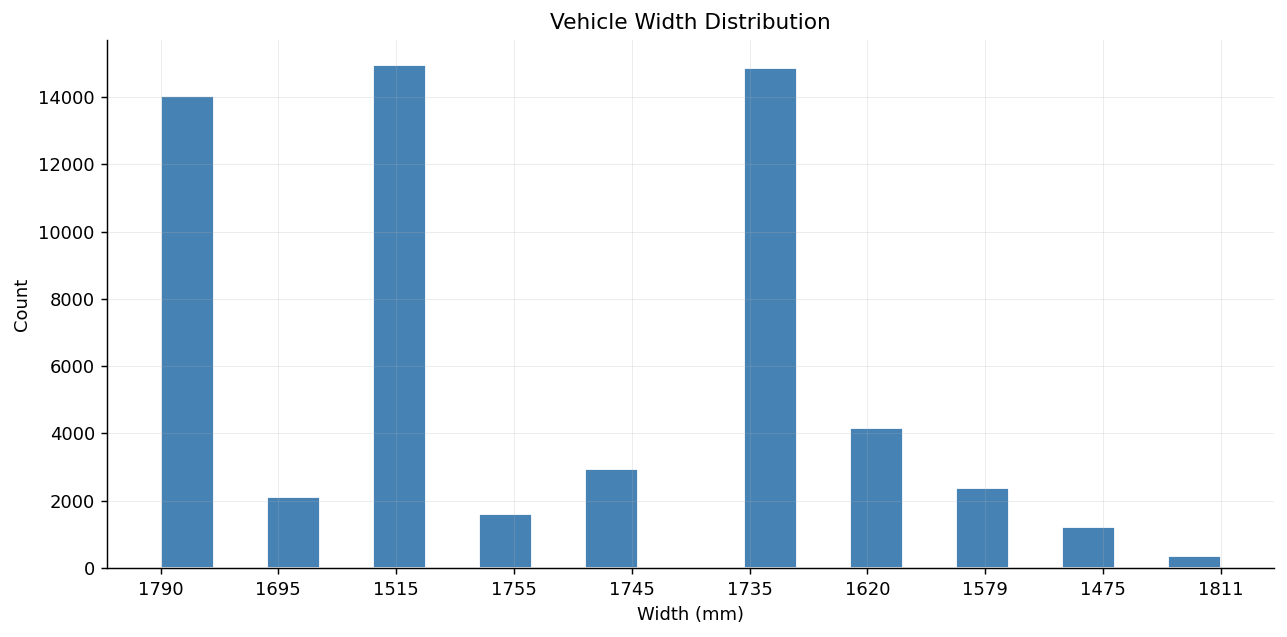

<Figure size 832x624 with 0 Axes>

In [ ]:
#transform the variable width into categorical
OVERALL_RATE = df[TARGET].mean() # Calculate the overall claim rate
width_unique = sorted(df["width"].unique())
width_nunique = df["width"].nunique()

print(f"\n  Unique values ({width_nunique}): {width_unique}")


# Execute the transformation
df["width"] = df["width"].astype(str)        # convert to string category
quant_cols  = [c for c in quant_cols if c != "width"]
qual_cols   = ["width"] + qual_cols          # prepend so it ranks in quali

# Plot: width distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["width"].dropna(), bins=20, color='steelblue', edgecolor='white')
ax.set_xlabel("Width (mm)")
ax.set_ylabel("Count")
ax.set_title("Vehicle Width Distribution")
plt.tight_layout()
plt.show()


plt.tight_layout()
plt.savefig(f"{OUT_DIR}/preA_width_transformation.png")
plt.show()
plt.close()


  Unique values (2): [np.int64(3), np.int64(4)]


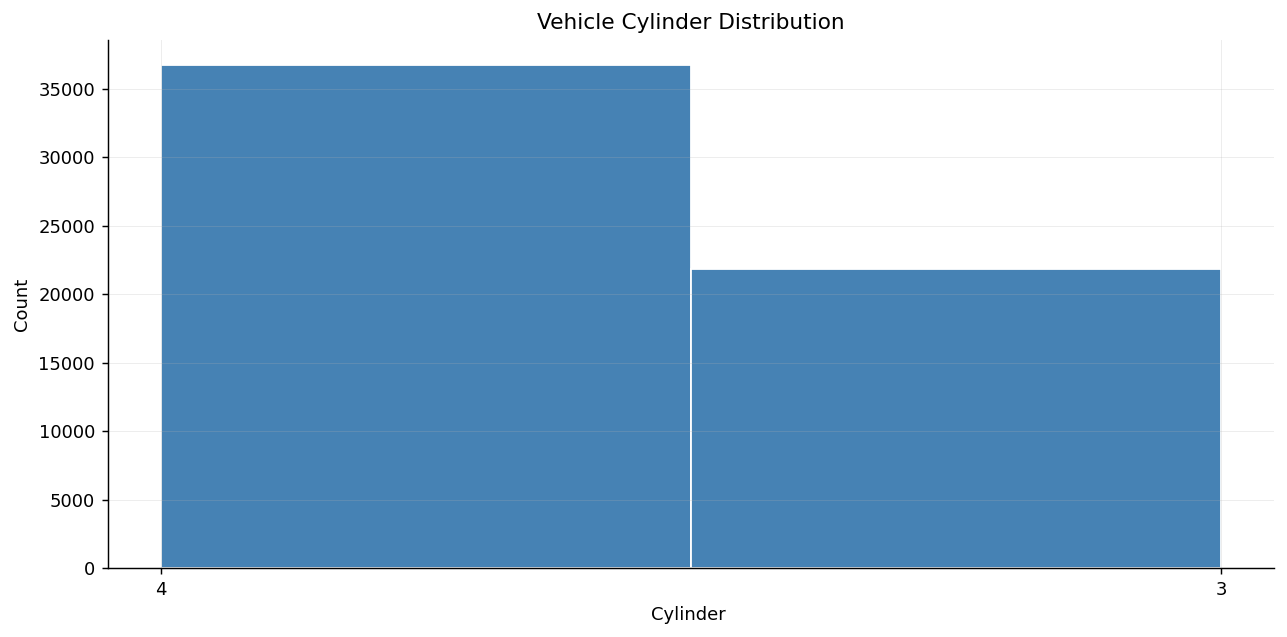

<Figure size 832x624 with 0 Axes>

In [ ]:
#transform the variable cylinder into categorical because it has only two modalities ( so it's treated as binary)
OVERALL_RATE = df[TARGET].mean() # Calculate the overall claim rate
cylinder_unique = sorted(df["cylinder"].unique())
cylinder_nunique = df["cylinder"].nunique()

print(f"\n  Unique values ({cylinder_nunique}): {cylinder_unique}")


# Execute the transformation
df["cylinder"] = df["cylinder"].astype(str)        # convert to string category
quant_cols  = [c for c in quant_cols if c != "cylinder"]
qual_cols   = ["cylinder"] + qual_cols          # prepend so it ranks in quali

# Plot: cylinder distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["cylinder"].dropna(), bins=2, color='steelblue', edgecolor='white')
ax.set_xlabel("Cylinder ")
ax.set_ylabel("Count")
ax.set_title("Vehicle Cylinder Distribution")
plt.tight_layout()
plt.show()


plt.tight_layout()
plt.savefig(f"{OUT_DIR}/preA_cylinder_transformation.png")
plt.show()
plt.close()

for some variables, zero has a specific real-world meaning, so it should NOT simply be treated like an ordinary numerical value.
Therefore, these zero values were preserved as separate categories during preprocessing rather than merged into standard numerical intervals.




  Column                         #Zeros        %  Meaning & treatment
  ───────────────────────────────────────────────────────────────────────────
  subscription_length               276    0.47% ⚠
    → Meaning  : Brand new policy (0 months active)
    → Treatment: Keep as own class [0 months]
  vehicle_age                     5,257    8.97% ⚠
    → Meaning  : Vehicle registered THIS year (0 years old)
    → Treatment: Keep as own class [0 years] — distinct high risk
  customer_age                        0    0.00%
  region_density                      0    0.00%
  airbags                             0    0.00%
  displacement                        0    0.00%
  turning_radius                      0    0.00%
  length                              0    0.00%
  gross_weight                        0    0.00%
  ncap_rating                    19,097   32.59% ⚠
    → Meaning  : Vehicle has NO NCAP safety rating (not tested)
    → Treatment: Keep as own class [unrated] — NOT 'zero stars'
  t

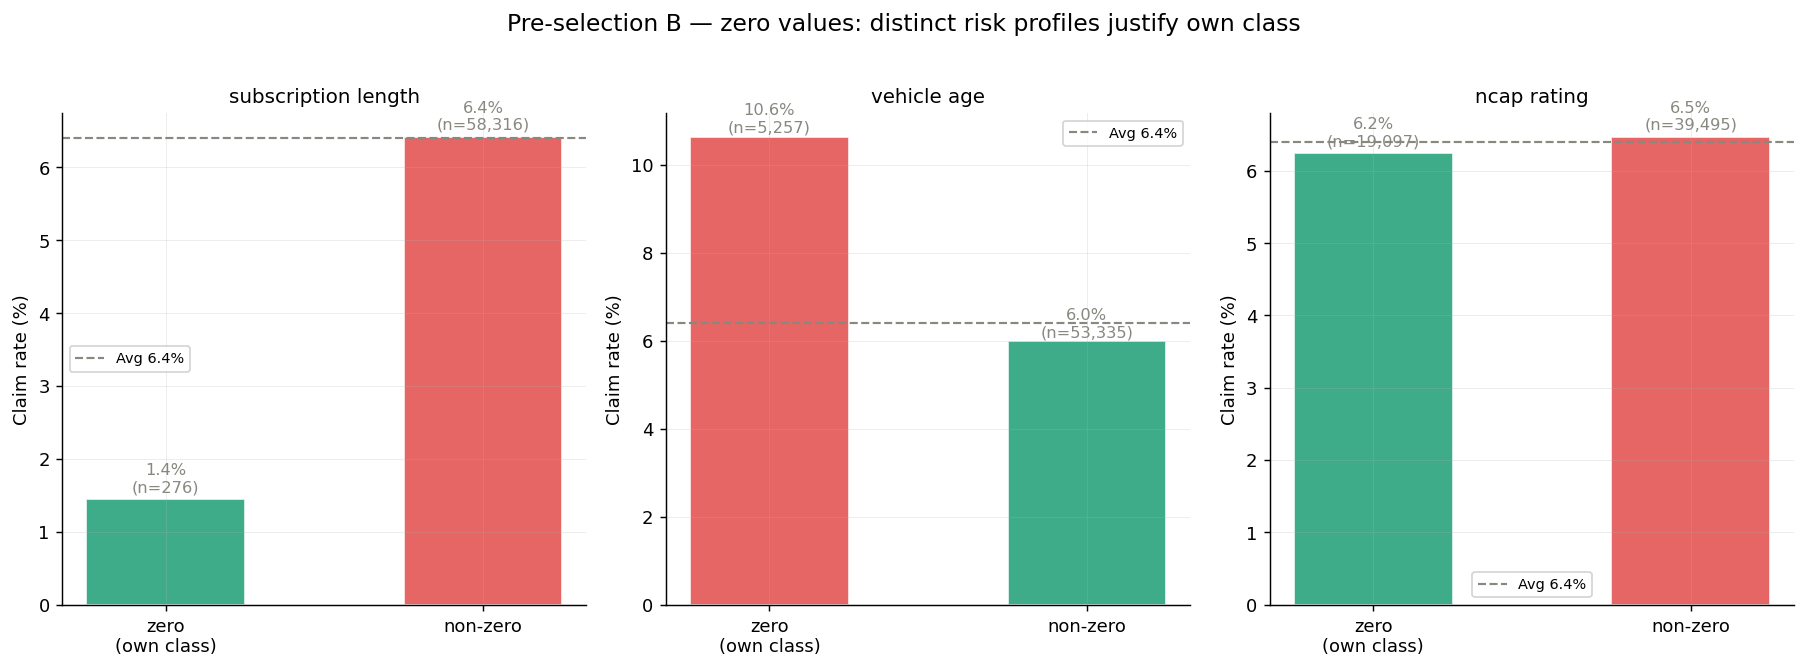

In [ ]:
# transoformer les zeors dans quelques colonnes numerique
print(f"\n  {'Column':<28} {'#Zeros':>8}  {'%':>7}  {'Meaning & treatment'}")
print("  " + "─" * 75)

ZERO_INFO = {
    "subscription_length": ("Brand new policy (0 months active)",
                            "Keep as own class [0 months]"),
    "vehicle_age":         ("Vehicle registered THIS year (0 years old)",
                            "Keep as own class [0 years] — distinct high risk"),
    "ncap_rating":         ("Vehicle has NO NCAP safety rating (not tested)",
                            "Keep as own class [unrated] — NOT 'zero stars'"),
}

zero_rows = []
for c in quant_cols:
    z   = (df[c] == 0).sum()
    pct = z / len(df) * 100
    meaning, treatment = ZERO_INFO.get(c, ("True numeric zero", "Include in first bin"))
    flag = " ⚠" if z > 0 else ""
    print(f"  {c:<28} {z:>8,}  {pct:>6.2f}%{flag}")
    if z > 0:
        print(f"    → Meaning  : {meaning}")
        print(f"    → Treatment: {treatment}")
    zero_rows.append({"feature": c, "zeros": z, "pct": pct})

zero_df = pd.DataFrame(zero_rows)

# Claim rates for the three zero-containing columns
print("\n  Claim rates FOR zeros vs NON-zeros:")
for c, (meaning, _) in ZERO_INFO.items():
    rate_zero    = df[df[c] == 0][TARGET].mean() * 100
    rate_nonzero = df[df[c] >  0][TARGET].mean() * 100
    print(f"    {c}:")
    print(f"      zero  (n={int((df[c]==0).sum()):>6,}): {rate_zero:.2f}%  ← {meaning}")
    print(f"      non-0 (n={int((df[c]>0).sum()):>6,}): {rate_nonzero:.2f}%")

# Plot: only zero-containing columns side by side
zero_feats = [c for c in quant_cols if (df[c] == 0).sum() > 0]
fig, axes = plt.subplots(1, len(zero_feats), figsize=(14, 5))
for ax, c in zip(axes, zero_feats):
    groups = ["zero\n(own class)", "non-zero"]
    rates  = [df[df[c]==0][TARGET].mean()*100, df[df[c]>0][TARGET].mean()*100]
    counts = [(df[c]==0).sum(), (df[c]>0).sum()]
    colors = [RED if r > OVERALL_RATE*100 else TEAL for r in rates]
    bars   = ax.bar(groups, rates, color=colors, alpha=0.85,
                    edgecolor="white", width=0.5)
    ax.axhline(OVERALL_RATE*100, color=GRAY, linestyle="--",
               linewidth=1.2, label=f"Avg {OVERALL_RATE*100:.1f}%")
    ax.set_title(c.replace("_", " "), fontsize=11)
    ax.set_ylabel("Claim rate (%)")
    ax.legend(fontsize=8)
    for bar, r, n in zip(bars, rates, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                r + 0.1, f"{r:.1f}%\n(n={n:,})",
                ha="center", fontsize=9, color=GRAY)

fig.suptitle("Pre-selection B — zero values: distinct risk profiles justify own class",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/preB_zeros_treatment.png")
plt.show()
plt.close()

#subscription_length	Brand new policy 0 months
#vehicle_age	Vehicle bought THIS year	Treat as 0 years
#ncap_rating	Never tested (no rating)	Treat as unrated



 Claim Status Distribution:
  No Claim (0): 54,844 (93.6%)
  Claim (1):    3,748 (6.4%)


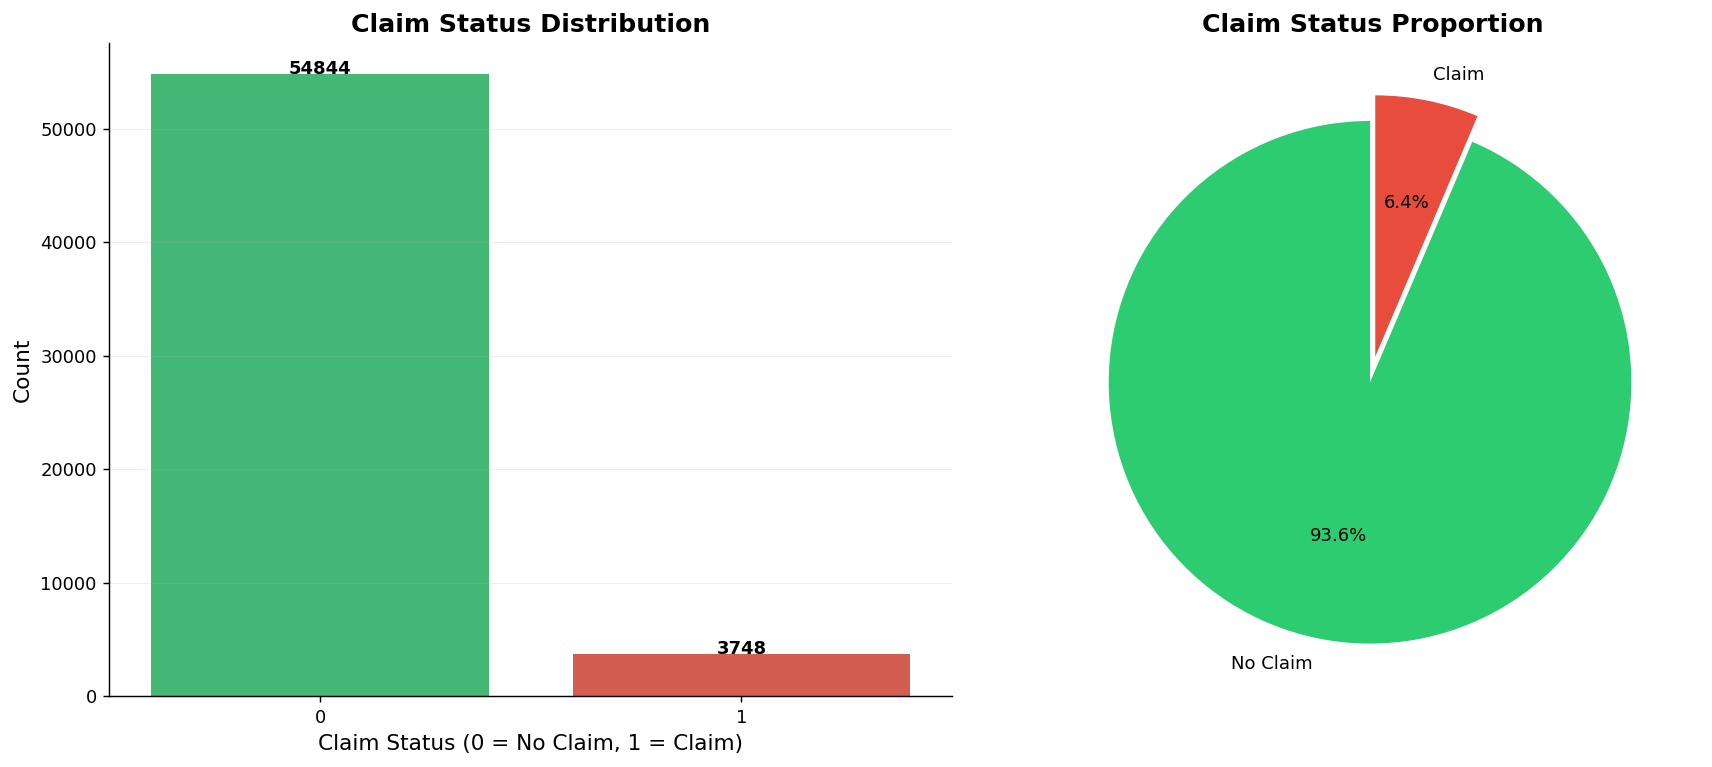

In [ ]:
# Check claim_status distribution
claim_counts = df['claim_status'].value_counts()
claim_percent = df['claim_status'].value_counts(normalize=True) * 100

print(f"\n Claim Status Distribution:")
print(f"  No Claim (0): {claim_counts.get(0, 0):,} ({claim_percent.get(0, 0):.1f}%)")
print(f"  Claim (1):    {claim_counts.get(1, 0):,} ({claim_percent.get(1, 0):.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
colors = ['#2ecc71', '#e74c3c']
sns.countplot(data=df, x='claim_status', palette=colors, ax=axes[0])
axes[0].set_title('Claim Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Claim Status (0 = No Claim, 1 = Claim)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for i, v in enumerate([claim_counts.get(0, 0), claim_counts.get(1, 0)]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(claim_counts.values, labels=['No Claim', 'Claim'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Claim Status Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('1_claim_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# **bivariate analysis**
Bivariate analysis studies the relationship between two variables at a time.
to Detect variables carrying similar information in order to avoid redundancy during feature selection.

Some variables may be highly associated with each other
1) **quanti-quanti** ( Pearson Correlation)

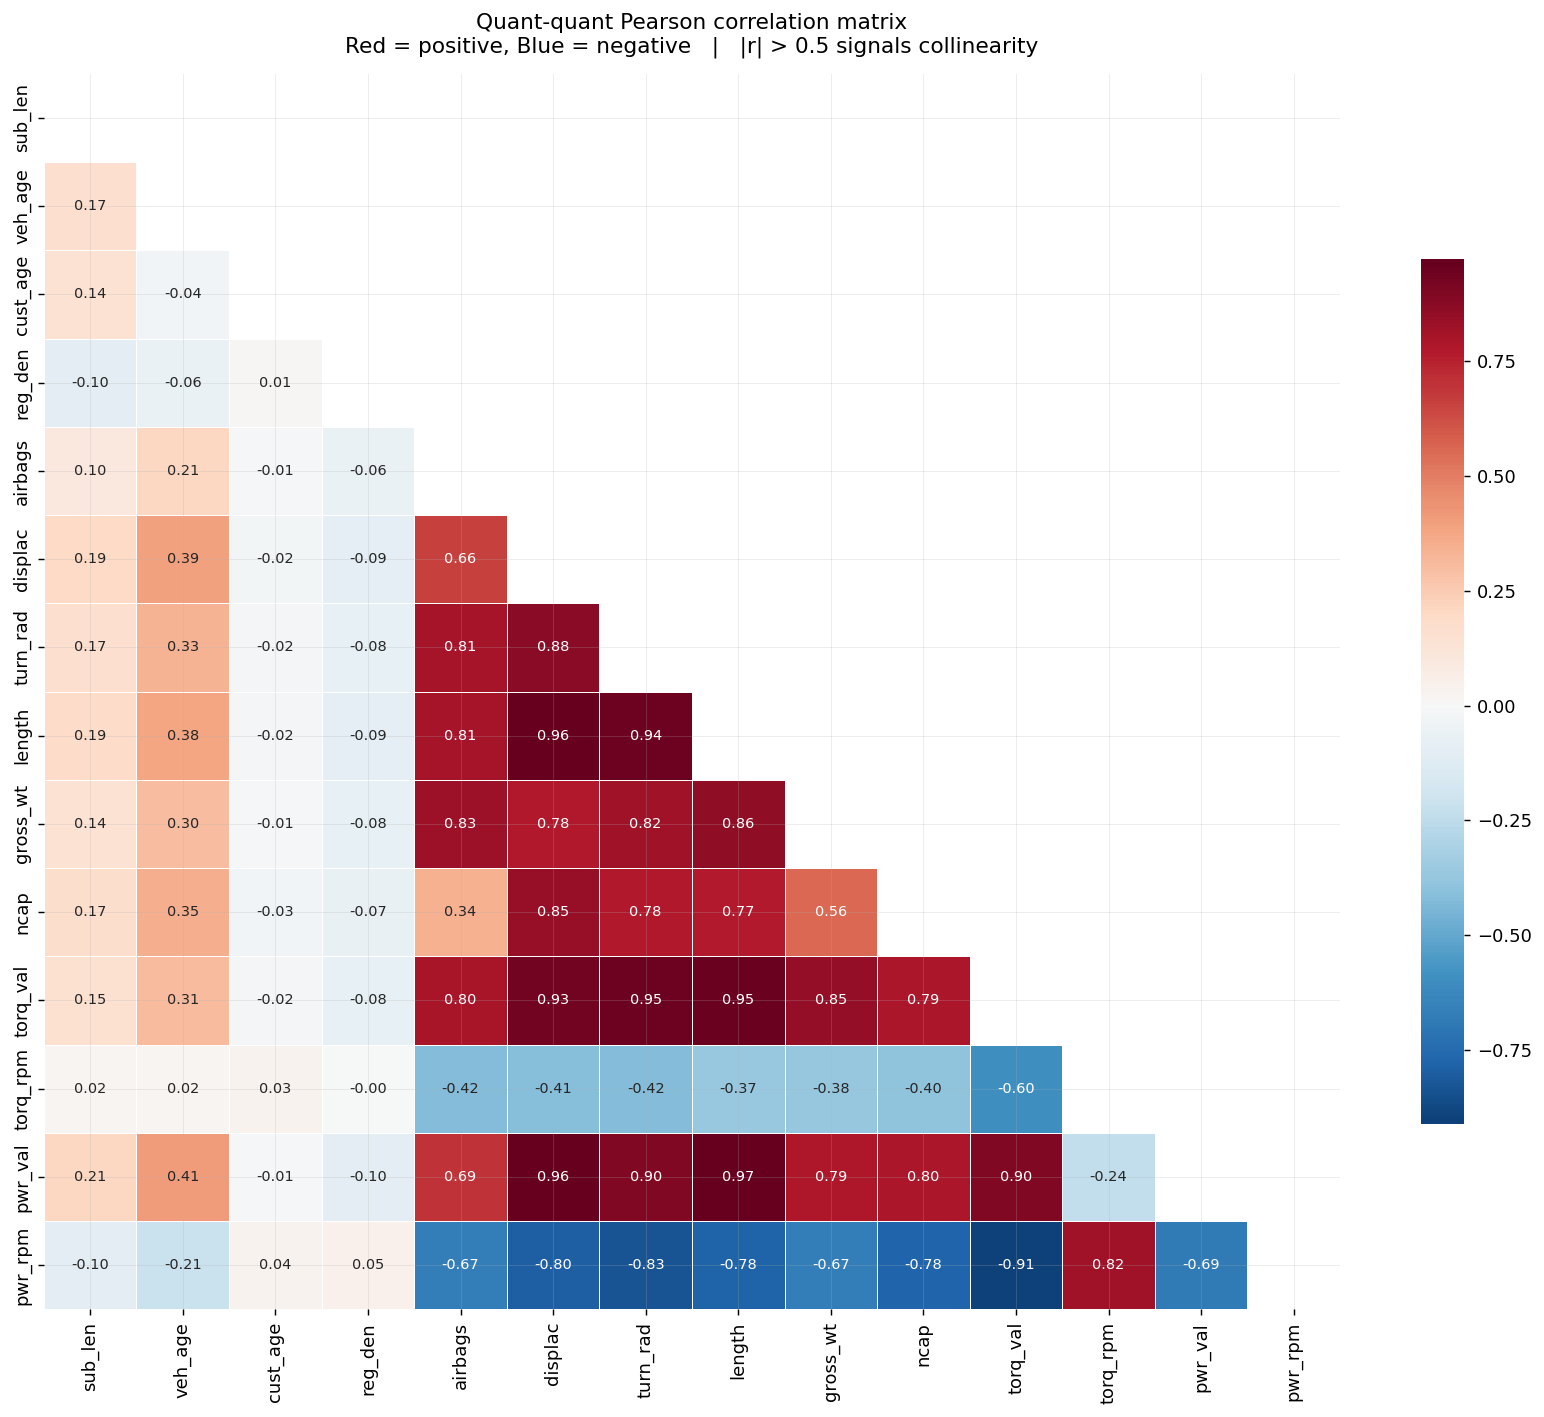


  Pairs with |r| > 0.5 (collinear — do not select both):
  Variable A             Variable B                    r  Concern
  ──────────────────────────────────────────────────────────────────────
  airbags                displacement             0.6612  [MOD]
  airbags                turning_radius           0.8108  [HIGH]
  airbags                length                   0.8091  [HIGH]
  airbags                gross_weight             0.8290  [HIGH]
  airbags                torque_value             0.8004  [HIGH]
  airbags                power_value              0.6946  [MOD]
  airbags                power_rpm               -0.6703  [MOD]
  displacement           turning_radius           0.8754  [HIGH]
  displacement           length                   0.9617  [EXTREME]
  displacement           gross_weight             0.7762  [HIGH]
  displacement           ncap_rating              0.8471  [HIGH]
  displacement           torque_value             0.9312  [EXTREME]
  displacement      

In [ ]:
import itertools

corr_matrix = df[quant_cols].corr(method="pearson")

# Full heatmap
fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
short = [c.replace("subscription_length","sub_len")
          .replace("region_density","reg_den")
          .replace("turning_radius","turn_rad")
          .replace("gross_weight","gross_wt")
          .replace("displacement","displac")
          .replace("customer_age","cust_age")
          .replace("vehicle_age","veh_age")
          .replace("torque_value","torq_val")
          .replace("torque_rpm","torq_rpm")
          .replace("power_value","pwr_val")
          .replace("power_rpm","pwr_rpm")
          .replace("ncap_rating","ncap")
         for c in quant_cols]
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5, ax=ax,
            xticklabels=short, yticklabels=short,
            annot_kws={"size": 8}, cbar_kws={"shrink": 0.7})
ax.set_title("Quant-quant Pearson correlation matrix\n"
             "Red = positive, Blue = negative   |   |r| > 0.5 signals collinearity",
             fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/preC1_quant_corr_heatmap.png")
plt.show()
plt.close()

# Pairs with |r| > 0.5
print("\n  Pairs with |r| > 0.5 (collinear — do not select both):")
print(f"  {'Variable A':<22} {'Variable B':<22} {'r':>8}  {'Concern'}")
print("  " + "─" * 70)
collinear_pairs = []
for c1, c2 in itertools.combinations(quant_cols, 2):
    r = corr_matrix.loc[c1, c2]
    if abs(r) > 0.5:
        level = "EXTREME" if abs(r) > 0.9 else "HIGH" if abs(r) > 0.7 else "MOD"
        print(f"  {c1:<22} {c2:<22} {r:>8.4f}  [{level}]")
        collinear_pairs.append((c1, c2, r))

print(f"\n  Summary: {len(collinear_pairs)} collinear pairs found.")
print("  Key clusters to avoid double-selecting:")
print("    Cluster 1 (vehicle specs): displacement, length, turning_radius, torque_value, power_value")
print("    Cluster 2 (power system) : torque_value, torque_rpm, power_value, power_rpm")
print("    Cluster 3 (size/weight)  : airbags, gross_weight, length, width→qualitative")

2) **quali_quali** :( cramer'v)

In [ ]:
def cramers_v_pair(c1, c2):
    ct = pd.crosstab(df[c1], df[c2])
    chi2, _, _, _ = chi2_contingency(ct)
    return np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1)))

print("\nComputing Cramér's V for all qualitative pairs...")
v_results = []
for c1, c2 in itertools.combinations(qual_cols, 2):
    v = cramers_v_pair(c1, c2)
    v_results.append((c1, c2, v))
v_results.sort(key=lambda x: -x[2])

# Full V matrix
v_matrix = pd.DataFrame(np.eye(len(qual_cols)), index=qual_cols, columns=qual_cols)
for c1, c2, v in v_results:
    v_matrix.loc[c1, c2] = v
    v_matrix.loc[c2, c1] = v

# Plot: heatmap (trim labels)
short_q = [c.replace("is_adjustable_steering","adj_steer")
            .replace("is_driver_seat_height_adjustable","seat_adj")
            .replace("is_day_night_rear_view_mirror","day_night")
            .replace("is_rear_window_defogger","rw_defog")
            .replace("is_rear_window_washer","rw_washer")
            .replace("is_rear_window_wiper","rw_wiper")
            .replace("is_parking_sensors","park_sens")
            .replace("is_parking_camera","park_cam")
            .replace("is_front_fog_lights","fog_lights")
            .replace("is_power_door_locks","pwr_doors")
            .replace("is_central_locking","ctrl_lock")
            .replace("is_power_steering","pwr_steer")
            .replace("is_brake_assist","brk_asst")
            .replace("rear_brakes_type","rear_brk")
            .replace("transmission_type","transmis")
            .replace("steering_type","steer_typ")
            .replace("engine_type","eng_type")
            .replace("region_code","region")
            .replace("fuel_type","fuel")
            .replace("segment","segmt")
            .replace("model","model")
            .replace("width" , "width")
            .replace("cylinder" , "cylinder")
           for c in qual_cols]

fig, ax = plt.subplots(figsize=(16, 13))
mask_q = np.triu(np.ones_like(v_matrix, dtype=bool))
sns.heatmap(v_matrix, mask=mask_q, annot=True, fmt=".2f",
            cmap="YlOrRd", vmin=0, vmax=1,
            linewidths=0.3, ax=ax,
            xticklabels=short_q, yticklabels=short_q,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.6,
            "label": "Cramér's V (0=no assoc, 1=perfect)"})
ax.set_title("Quali-quali Cramér's V matrix\n"
             "V=1.0 means perfect collinearity — never select both",
             fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/preC2_quali_cramersv_heatmap.png")
plt.close()
print(f"  -> Saved: {OUT_DIR}/preC2_quali_cramersv_heatmap.png")

# Print perfect collinear pairs and main clusters
print("\n  Perfect collinear pairs (V = 1.00):")
for c1, c2, v in v_results:
    if v >= 0.999:
        print(f"    {c1:<38} ↔ {c2}")

print("\n  High collinearity clusters (V > 0.85):")
print("    CLUSTER A — vehicle model spec (all V=1.0 between each other):")
print("      model, engine_type, fuel_type, segment, transmission_type,")
print("      rear_brakes_type, steering_type, is_tpms, is_esc, is_adjustable_steering,")
print("      is_front_fog_lights, is_rear_window_wiper, is_rear_window_washer, etc.")
print("    → All these variables are FULLY DETERMINED by the car model.")
print("      Selecting more than one from this cluster adds ZERO new information.")
print()
print("    CLUSTER B — rear window trio:")
print("      is_rear_window_wiper ↔ is_rear_window_washer (V=1.00)")
print()
print("    CLUSTER C — locking/alarm trio:")
print("      is_power_door_locks ↔ is_central_locking ↔ is_ecw (V=1.00)")


Computing Cramér's V for all qualitative pairs...
  -> Saved: step1_output/preC2_quali_cramersv_heatmap.png

  Perfect collinear pairs (V = 1.00):
    cylinder                               ↔ width
    width                                  ↔ model
    width                                  ↔ fuel_type
    width                                  ↔ engine_type
    width                                  ↔ is_adjustable_steering
    width                                  ↔ is_tpms
    width                                  ↔ rear_brakes_type
    width                                  ↔ steering_type
    width                                  ↔ is_front_fog_lights
    width                                  ↔ is_rear_window_wiper
    width                                  ↔ is_rear_window_washer
    width                                  ↔ is_brake_assist
    width                                  ↔ is_driver_seat_height_adjustable
    width                                  ↔ is_day_night_r

In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import chi2_contingency, pointbiserialr
import itertools

warnings.filterwarnings("ignore")

In [ ]:
# ── Config ─────────────────────────────────────────────────────────────────────
DATA_PATH = "Insurance-claims-data.csv"
OUT_DIR   = "step1_output"
TARGET    = "claim_status"
df.dropna(subset=[TARGET], inplace=True)
os.makedirs(OUT_DIR, exist_ok=True)

BLUE   = "#378ADD";  RED    = "#E24B4A"
AMBER  = "#BA7517";  TEAL   = "#1D9E75"
PURPLE = "#7F77DD";  GRAY   = "#888780"
GREEN  = "#639922";  CORAL  = "#D85A30"

plt.rcParams.update({
    "figure.dpi": 130, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3,
})

In [ ]:
quant_cols = [
    'subscription_length', 'vehicle_age', 'customer_age', 'region_density',
    'airbags', 'displacement', 'turning_radius', 'length',
    'gross_weight', 'ncap_rating', 'torque_value', 'torque_rpm' , 'power_value', 'power_rpm'
]
qual_cols = [
    'region_code', 'segment', 'model', 'fuel_type', 'engine_type',
    'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
    'is_parking_camera', 'rear_brakes_type', 'transmission_type',
    'steering_type', 'is_front_fog_lights', 'is_rear_window_wiper',
    'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist',
    'is_power_door_locks', 'is_central_locking', 'is_power_steering',
    'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
    'is_ecw', 'is_speed_alert' , 'width' ,'cylinder'
]

# **feature selection**





 VARIABLE SELECTION

── QUANTITATIVE: Point-Biserial r (all 16 columns) ──
  Feature                           |r|         r       p-value   sig
  ─────────────────────────────────────────────────────────────────
  subscription_length           0.07874  +0.07874      3.15e-81   ***
  vehicle_age                   0.02817  -0.02817      9.07e-12   ***
  customer_age                  0.02223  +0.02223      7.34e-08   ***
  region_density                0.01781  -0.01781      1.63e-05   ***
  airbags                       0.00279  +0.00279      5.00e-01    ns
  displacement                  0.00768  +0.00768      6.31e-02    ns
  turning_radius                0.00272  +0.00272      5.10e-01    ns
  length                        0.00649  +0.00649      1.16e-01    ns
  gross_weight                  0.00389  +0.00389      3.46e-01    ns
  ncap_rating                   0.00380  +0.00380      3.58e-01    ns
  torque_value                  0.00429  +0.00429      2.99e-01    ns
  torque_rpm     

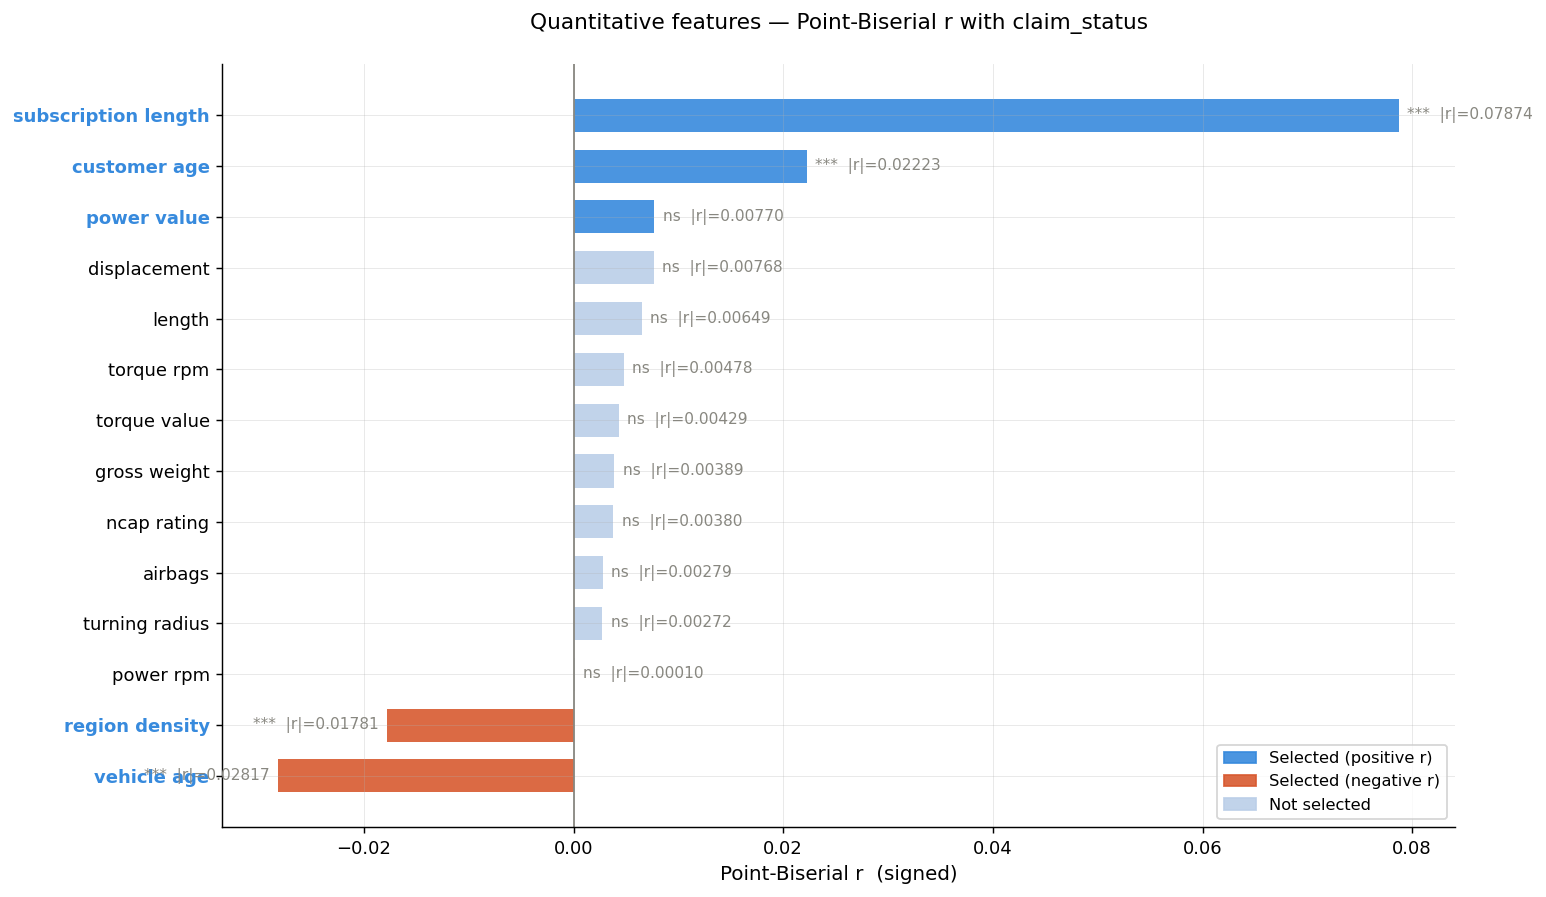

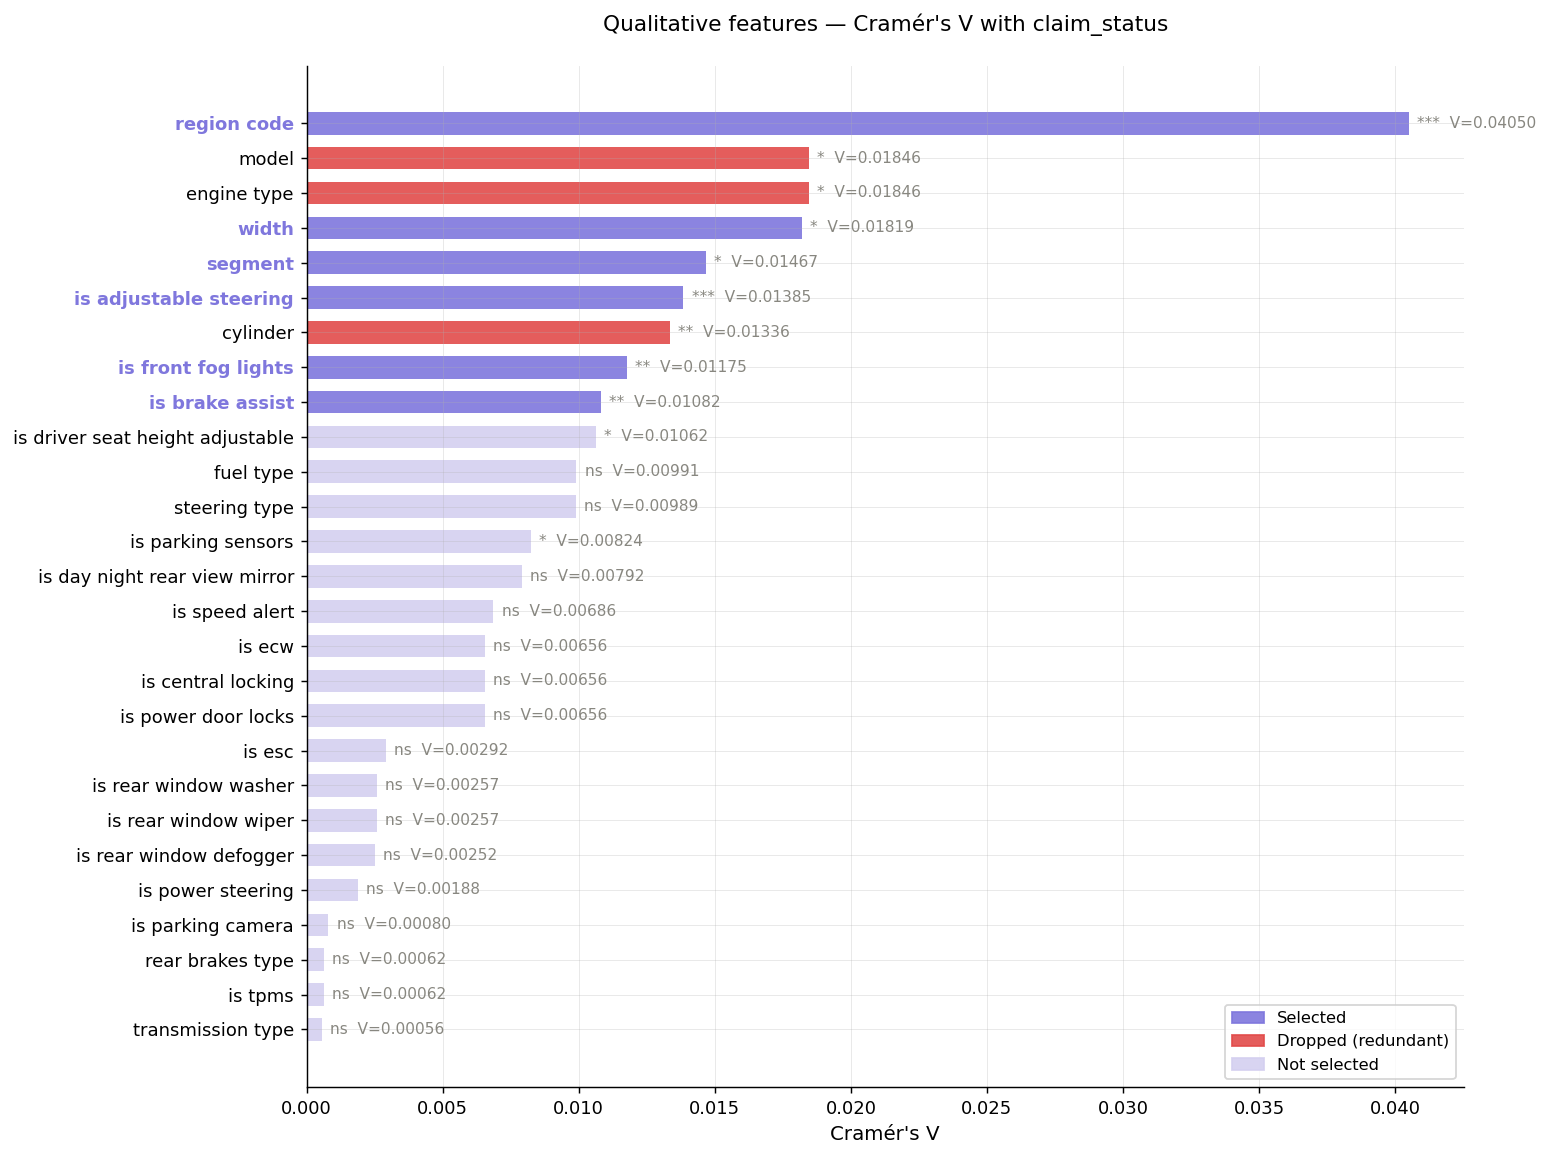

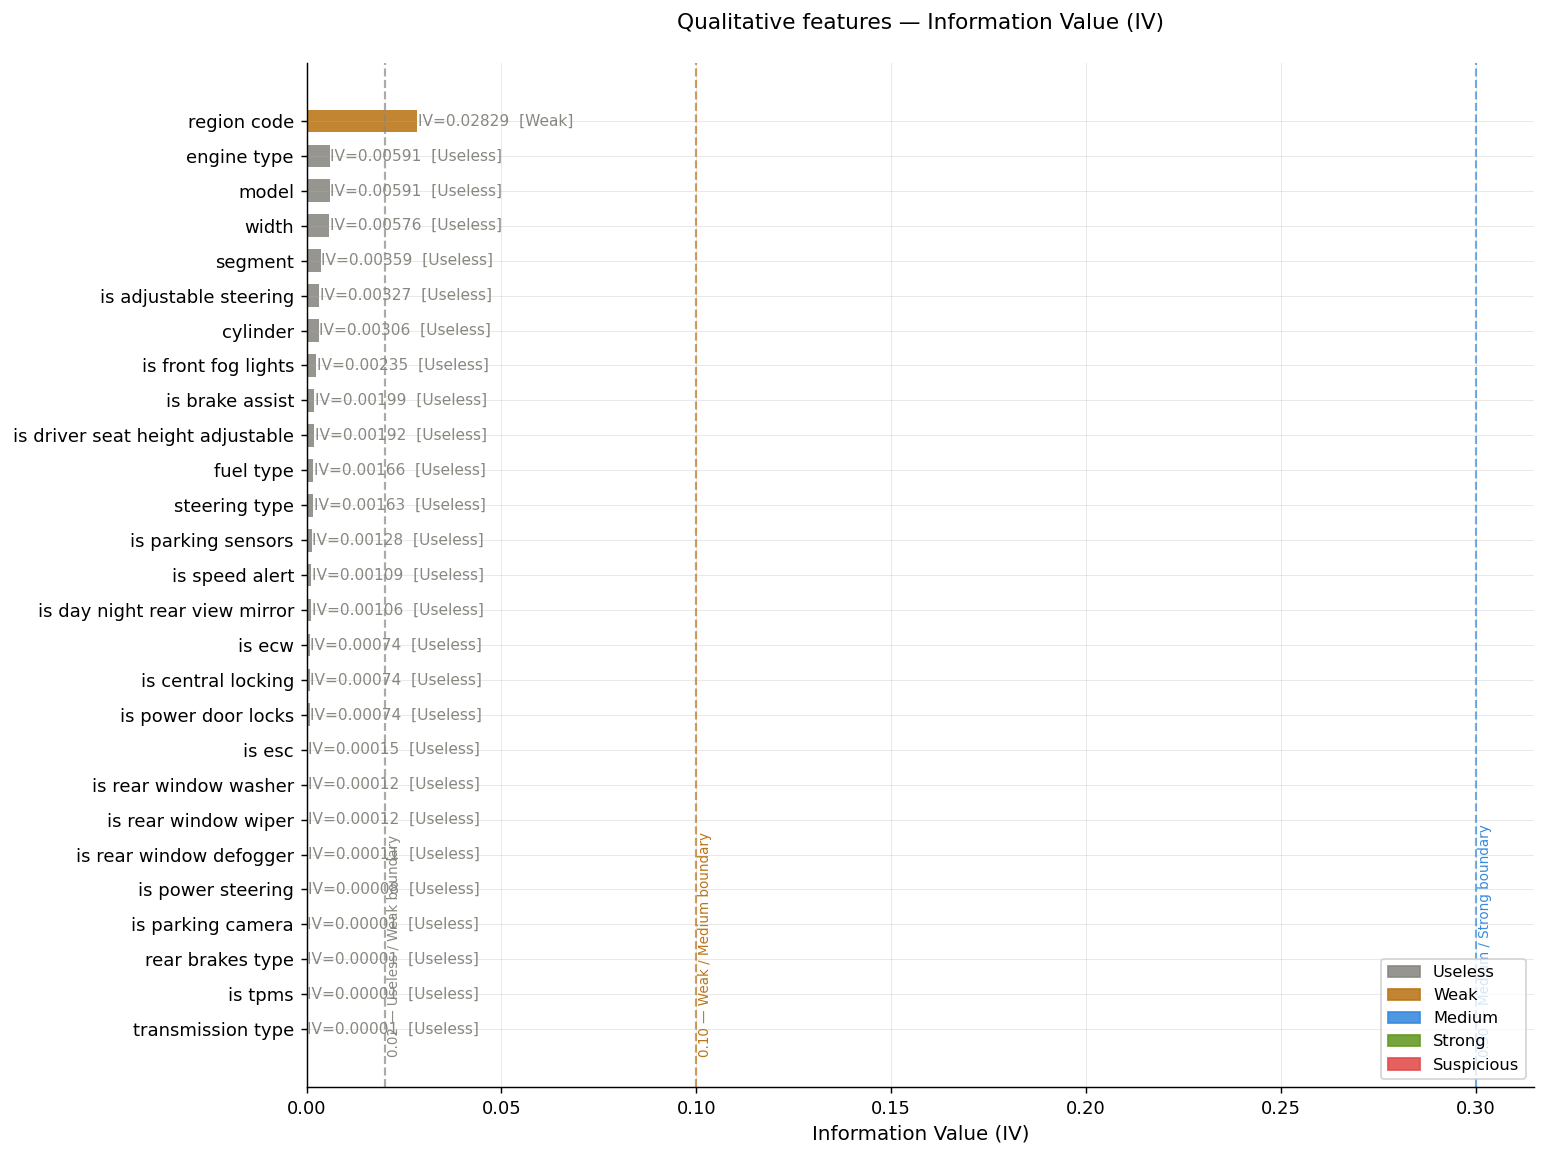

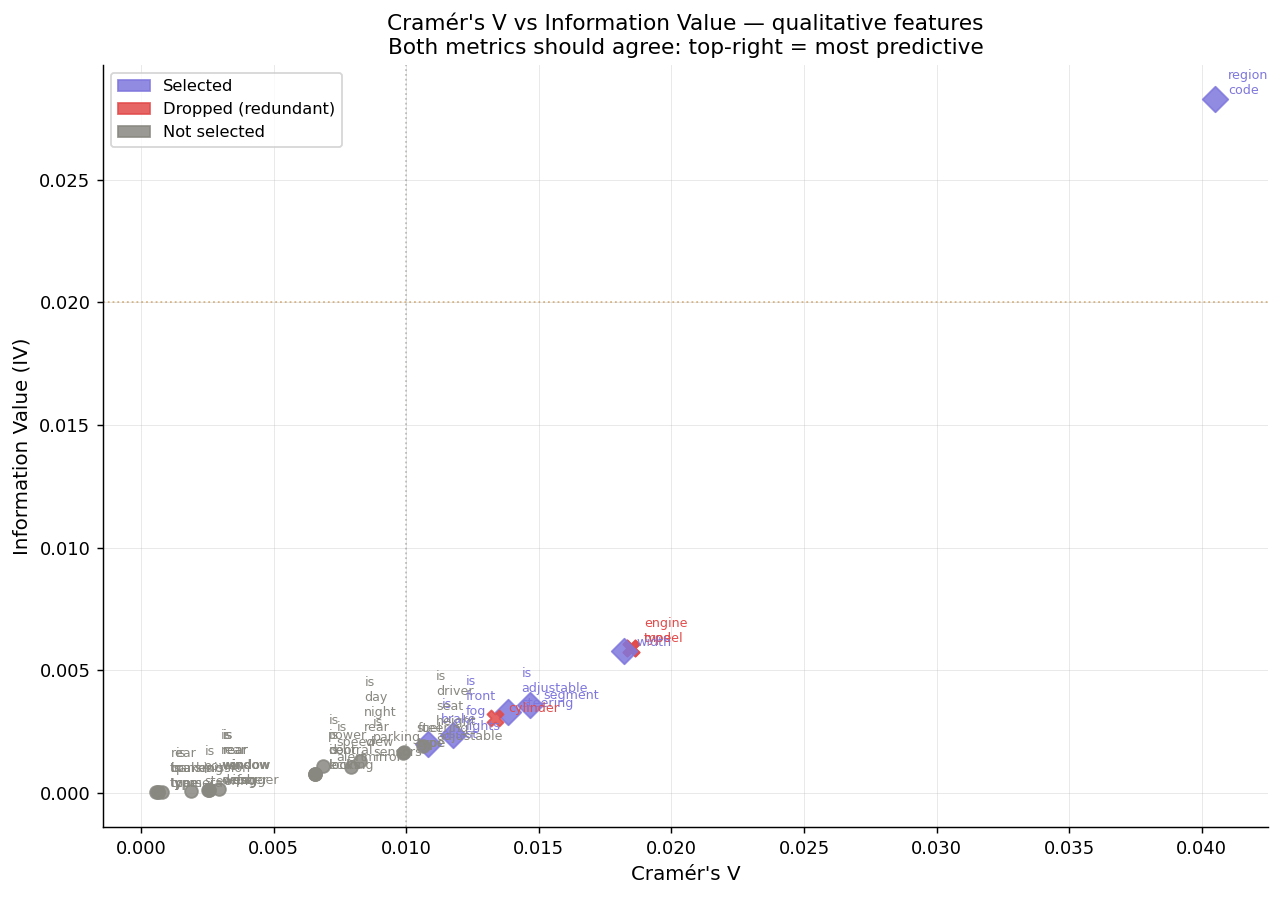

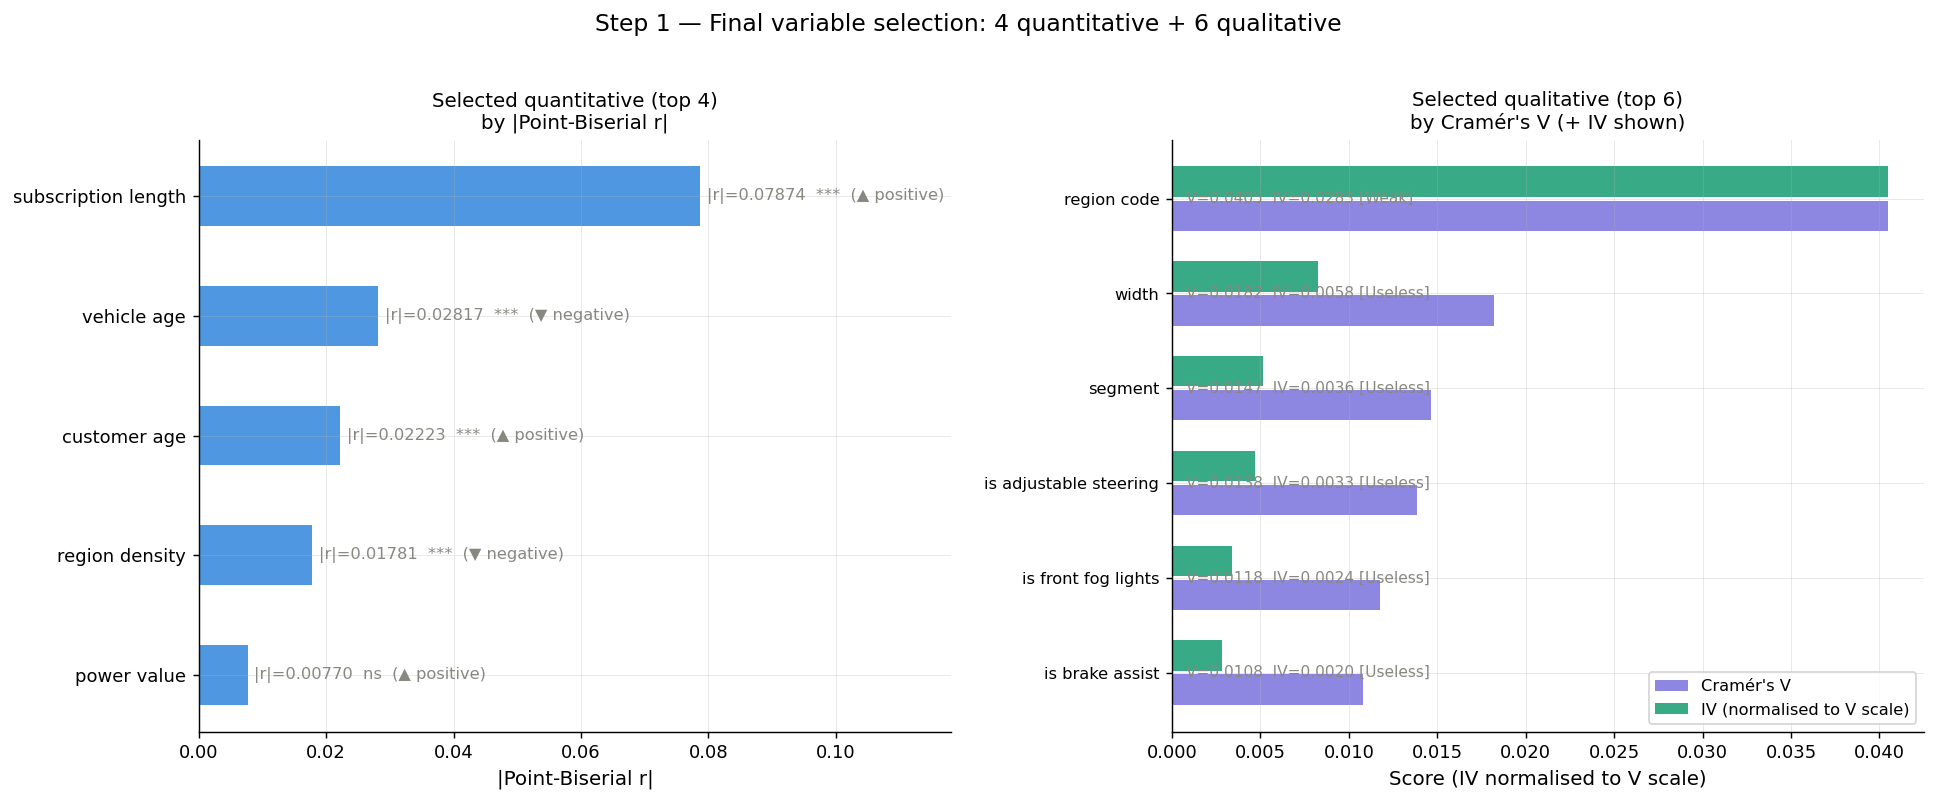

In [ ]:
# METRIC FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def point_biserial(col):
    """
    Measures linear association between a continuous variable and a binary target.
    Returns:
        abs_r : absolute value of r  (used for ranking)
        r     : signed r             (direction: + = more claim, - = less claim)
        p     : p-value from t-test
    """
    x = df[col].fillna(df[col].median())
    r, p = pointbiserialr(df[TARGET], x)
    return abs(r), r, p


def cramers_v(col):
    """
    Measures association between a categorical variable and the binary target.
    Based on chi-square. Normalised to [0, 1] regardless of category count.
    Returns:
        V : Cramér's V  (0 = no association, 1 = perfect association)
        p : p-value from chi-square test
    """
    ct = pd.crosstab(df[col], df[TARGET])
    chi2, p, _, _ = chi2_contingency(ct)
    V = np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1)))
    return V, p


def information_value(col):
    """
    Measures the predictive power of a categorical variable against a binary target.
    Industry standard metric in credit scoring and insurance (Basel II).

    For each modality k:
        Distribution of Events    = P(modality=k | claim=1)
        Distribution of Non-Events = P(modality=k | claim=0)
        WoE_k  = ln( Distr_Events_k / Distr_NonEvents_k )
        IV_k   = ( Distr_Events_k - Distr_NonEvents_k ) × WoE_k

    Total IV = Σ IV_k across all modalities

    Interpretation scale:
        IV < 0.02   → useless
        0.02–0.1    → weak predictor
        0.1–0.3     → medium predictor
        0.3–0.5     → strong predictor
        IV > 0.5    → suspicious (possible leakage)
    """
    total_ev  = df[TARGET].sum()
    total_nev = (1 - df[TARGET]).sum()
    iv_total  = 0.0
    rows      = []

    for cat in df[col].unique():
        mask   = df[col] == cat
        ev     = df.loc[mask, TARGET].sum()
        nev    = mask.sum() - ev
        d_ev   = max(ev  / total_ev,  1e-10)
        d_nev  = max(nev / total_nev, 1e-10)
        woe    = np.log(d_ev / d_nev)
        iv_k   = (d_ev - d_nev) * woe
        iv_total += iv_k
        rows.append({"modality": cat, "n": int(mask.sum()),
                     "events": int(ev), "non_events": int(nev),
                     "dist_ev": d_ev, "dist_nev": d_nev,
                     "woe": woe, "iv": iv_k})

    woe_df = pd.DataFrame(rows).sort_values("iv", ascending=False)
    return iv_total, woe_df


def iv_label(iv):
    if iv < 0.02:  return "Useless",  GRAY
    if iv < 0.10:  return "Weak",     AMBER
    if iv < 0.30:  return "Medium",   BLUE
    if iv < 0.50:  return "Strong",   GREEN
    return "Suspicious", RED


def sig_label(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"


# ══════════════════════════════════════════════════════════════════════════════
# COMPUTE ALL METRICS
# ══════════════════════════════════════════════════════════════════════════════


print(" VARIABLE SELECTION")


# ── Quantitative ──────────────────────────────────────────────────────────────
print("\n── QUANTITATIVE: Point-Biserial r (all 16 columns) ──")
print(f"  {'Feature':<28} {'|r|':>8}  {'r':>8}  {'p-value':>12}  {'sig':>4}")
print("  " + "─" * 65)

quant_rows = []
for c in quant_cols:
    absr, r, p = point_biserial(c)
    sig = sig_label(p)
    quant_rows.append({"feature": c, "abs_r": absr, "r": r,
                       "p_value": p, "sig": sig})
    print(f"  {c:<28} {absr:>8.5f}  {r:>+8.5f}  {p:>12.2e}  {sig:>4}")

quant_df = (pd.DataFrame(quant_rows)
            .sort_values("abs_r", ascending=False)
            .reset_index(drop=True))

# ── Qualitative ───────────────────────────────────────────────────────────────
print(f"\n── QUALITATIVE: Cramér's V + Information Value (all 25 columns) ──")
print(f"  {'Feature':<40} {'V':>7}  {'IV':>8}  {'IV label':>12}  {'sig':>4}")
print("  " + "─" * 75)

qual_rows = []
for c in qual_cols:
    V, p    = cramers_v(c)
    iv, _   = information_value(c)
    label, _ = iv_label(iv)
    sig      = sig_label(p)
    qual_rows.append({"feature": c, "cramers_v": V, "iv": iv,
                      "iv_label": label, "p_value": p, "sig": sig})
    print(f"  {c:<40} {V:>7.5f}  {iv:>8.5f}  {label:>12}  {sig:>4}")

qual_df = (pd.DataFrame(qual_rows)
           .sort_values(["cramers_v", "iv"], ascending=False)
           .reset_index(drop=True))

# ══════════════════════════════════════════════════════════════════════════════
# SELECTION LOGIC
# ══════════════════════════════════════════════════════════════════════════════

# Drop perfect redundancies before selecting
# engine_type and model are 1-to-1 mappings (Cramér's V = 1.0 between them)
REDUNDANT = {"engine_type" ,"model" ,"cylinder"}   # keep model, drop engine_type

# cylinder only has 2 unique values → behaves like binary/qualitative
# exclude from numerical ranking
BINARY_AS_NUM = {"cylinder"}

quant_eligible = quant_df[~quant_df["feature"].isin(BINARY_AS_NUM)]
qual_eligible  = qual_df[~qual_df["feature"].isin(REDUNDANT)]



TOP_QUANT = quant_eligible.head(5)["feature"].tolist()
TOP_QUAL  = qual_eligible.head(6)["feature"].tolist()
SELECTED  = TOP_QUANT + TOP_QUAL

print(f"\n→ Top 5 quantitative : {TOP_QUANT}")
print(f"→ Top 6 qualitative  : {TOP_QUAL}")
print(f"\n→ FINAL 11 SELECTED  : {SELECTED}")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Point-Biserial r for all quantitative (ranked, signed, coloured)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 7))

sorted_q = quant_df.sort_values("r")          # sort by signed r for visual clarity
labels   = [r["feature"].replace("_", " ") for _, r in sorted_q.iterrows()]
values   = sorted_q["r"].values
selected_set = set(TOP_QUANT)

bar_colors = []
for _, row in sorted_q.iterrows():
    if row["feature"] in selected_set:
        bar_colors.append(BLUE if row["r"] >= 0 else CORAL)
    else:
        bar_colors.append("#BBCFE8" if row["r"] >= 0 else "#F0C4BF")

bars = ax.barh(labels, values, color=bar_colors, alpha=0.9, height=0.65)
ax.axvline(0, color=GRAY, linewidth=1)

# mark significance threshold approx with *** / ** / *
for i, (_, row) in enumerate(sorted_q.iterrows()):
    v = row["r"]
    offset = 0.0008 if v >= 0 else -0.0008
    ha = "left" if v >= 0 else "right"
    ax.text(v + offset, i,
            f"{row['sig']}  |r|={row['abs_r']:.5f}",
            va="center", ha=ha, fontsize=8.5, color=GRAY)

# highlight selected
for i, (_, row) in enumerate(sorted_q.iterrows()):
    if row["feature"] in selected_set:
        ax.get_yticklabels()[i].set_fontweight("bold")
        ax.get_yticklabels()[i].set_color(BLUE)

selected_patch   = mpatches.Patch(color=BLUE,    alpha=0.9, label="Selected (positive r)")
selected_patch_n = mpatches.Patch(color=CORAL,   alpha=0.9, label="Selected (negative r)")
other_patch      = mpatches.Patch(color="#BBCFE8",alpha=0.9, label="Not selected")
ax.legend(handles=[selected_patch, selected_patch_n, other_patch],
          fontsize=9, loc="lower right")
ax.set_xlabel("Point-Biserial r  (signed)", fontsize=11)
ax.set_title("Quantitative features — Point-Biserial r with claim_status\n"
             ,
             fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/plot1_pointbiserial_all.png")
plt.show()
plt.close()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Cramér's V for all qualitative (ranked, coloured by significance)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 9))

sorted_qv = qual_df.sort_values("cramers_v")
labels_qv = [r["feature"].replace("_", " ") for _, r in sorted_qv.iterrows()]
values_qv = sorted_qv["cramers_v"].values
selected_qual_set = set(TOP_QUAL)

bar_colors_qv = []
for _, row in sorted_qv.iterrows():
    if row["feature"] in selected_qual_set:
        bar_colors_qv.append(PURPLE)
    elif row["feature"] in REDUNDANT:
        bar_colors_qv.append(RED)
    else:
        bar_colors_qv.append("#D4D0F0")

bars_qv = ax.barh(labels_qv, values_qv,
                  color=bar_colors_qv, alpha=0.9, height=0.65)

for i, (_, row) in enumerate(sorted_qv.iterrows()):
    ax.text(row["cramers_v"] + 0.0003, i,
            f"{row['sig']}  V={row['cramers_v']:.5f}",
            va="center", fontsize=8.5, color=GRAY)

sel_p   = mpatches.Patch(color=PURPLE,   alpha=0.9, label="Selected")
drop_p  = mpatches.Patch(color=RED,      alpha=0.9, label="Dropped (redundant)")
rest_p  = mpatches.Patch(color="#D4D0F0",alpha=0.9, label="Not selected")
ax.legend(handles=[sel_p, drop_p, rest_p], fontsize=9, loc="lower right")
ax.set_xlabel("Cramér's V", fontsize=11)
ax.set_title("Qualitative features — Cramér's V with claim_status\n"
             ,
             fontsize=12)
for i, (_, row) in enumerate(sorted_qv.iterrows()):
    if row["feature"] in selected_qual_set:
        ax.get_yticklabels()[i].set_fontweight("bold")
        ax.get_yticklabels()[i].set_color(PURPLE)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/plot2_cramersv_all.png")
plt.show()
plt.close()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Information Value for all qualitative + IV interpretation bands
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 9))

sorted_iv = qual_df.sort_values("iv")
labels_iv = [r["feature"].replace("_", " ") for _, r in sorted_iv.iterrows()]
values_iv = sorted_iv["iv"].values

# colour by IV label
iv_colors = {
    "Useless":    GRAY,
    "Weak":       AMBER,
    "Medium":     BLUE,
    "Strong":     GREEN,
    "Suspicious": RED,
}
bar_colors_iv = [iv_colors[r["iv_label"]] for _, r in sorted_iv.iterrows()]

bars_iv = ax.barh(labels_iv, values_iv,
                  color=bar_colors_iv, alpha=0.88, height=0.65)

# IV threshold lines
for thresh, label, color in [
    (0.02, "0.02 — Useless / Weak boundary",   GRAY),
    (0.10, "0.10 — Weak / Medium boundary",    AMBER),
    (0.30, "0.30 — Medium / Strong boundary",  BLUE),
]:
    ax.axvline(thresh, color=color, linestyle="--", linewidth=1.2, alpha=0.7)
    ax.text(thresh + 0.0005, -0.8, label,
            color=color, fontsize=7.5, rotation=90, va="bottom")

for i, (_, row) in enumerate(sorted_iv.iterrows()):
    ax.text(row["iv"] + 0.0002, i,
            f"IV={row['iv']:.5f}  [{row['iv_label']}]",
            va="center", fontsize=8.5, color=GRAY)

legend_handles = [mpatches.Patch(color=c, alpha=0.88, label=l)
                  for l, c in iv_colors.items()]
ax.legend(handles=legend_handles, fontsize=9, loc="lower right")
ax.set_xlabel("Information Value (IV)", fontsize=11)
ax.set_title("Qualitative features — Information Value (IV)\n"
             ,
             fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/plot3_iv_all.png")
plt.show()
plt.close()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Cramér's V vs IV scatter: are both metrics consistent?
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 7))

for _, row in qual_df.iterrows():
    is_sel  = row["feature"] in selected_qual_set
    is_drop = row["feature"] in REDUNDANT
    color   = PURPLE if is_sel else (RED if is_drop else GRAY)
    size    = 100    if is_sel else (80  if is_drop else 50)
    marker  = "D"    if is_sel else ("X" if is_drop else "o")
    ax.scatter(row["cramers_v"], row["iv"],
               color=color, s=size, marker=marker,
               alpha=0.85, zorder=3)
    offset_x = 0.0005
    offset_y = 0.0001
    ax.annotate(row["feature"].replace("_", "\n"),
                xy=(row["cramers_v"], row["iv"]),
                xytext=(row["cramers_v"] + offset_x, row["iv"] + offset_y),
                fontsize=7, color=color,
                ha="left", va="bottom")

# threshold lines
ax.axvline(0.01,  color=GRAY,  linestyle=":", linewidth=1, alpha=0.5,
           label="V=0.01 minimum threshold")
ax.axhline(0.02,  color=AMBER, linestyle=":", linewidth=1, alpha=0.5,
           label="IV=0.02 useless/weak boundary")

sel_p  = mpatches.Patch(color=PURPLE, alpha=0.85, label="Selected")
drop_p = mpatches.Patch(color=RED,    alpha=0.85, label="Dropped (redundant)")
rest_p = mpatches.Patch(color=GRAY,   alpha=0.85, label="Not selected")
ax.legend(handles=[sel_p, drop_p, rest_p], fontsize=9)
ax.set_xlabel("Cramér's V", fontsize=11)
ax.set_ylabel("Information Value (IV)", fontsize=11)
ax.set_title("Cramér's V vs Information Value — qualitative features\n"
             "Both metrics should agree: top-right = most predictive",
             fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/plot4_v_vs_iv_scatter.png")
plt.show()
plt.close()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 5 — Final selection summary: top 10 side by side
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: top 4 quantitative with |r|
top_q_df = quant_df[quant_df["feature"].isin(TOP_QUANT)].sort_values("abs_r")
ax = axes[0]
bars = ax.barh(
    top_q_df["feature"].str.replace("_", " "),
    top_q_df["abs_r"],
    color=BLUE, alpha=0.88, height=0.5
)
for i, (_, row) in enumerate(top_q_df.iterrows()):
    direction = "▲ positive" if row["r"] > 0 else "▼ negative"
    ax.text(row["abs_r"] + 0.001, i,
            f"|r|={row['abs_r']:.5f}  {row['sig']}  ({direction})",
            va="center", fontsize=9, color=GRAY)
ax.set_xlabel("|Point-Biserial r|", fontsize=11)
ax.set_title("Selected quantitative (top 4)\nby |Point-Biserial r|",
             fontsize=11)
ax.set_xlim(0, top_q_df["abs_r"].max() * 1.5)

# Right: top 6 qualitative with dual bars (V and IV normalised to same scale)
top_ql_df = qual_df[qual_df["feature"].isin(TOP_QUAL)].sort_values("cramers_v")
ax2 = axes[1]
y_pos    = np.arange(len(top_ql_df))
max_v    = qual_df["cramers_v"].max()
max_iv   = qual_df["iv"].max()

# Normalise IV to same scale as V for visual comparison
iv_norm = top_ql_df["iv"] / max_iv * max_v

ax2.barh(y_pos - 0.18, top_ql_df["cramers_v"],
         height=0.32, color=PURPLE, alpha=0.88, label="Cramér's V")
ax2.barh(y_pos + 0.18, iv_norm,
         height=0.32, color=TEAL,   alpha=0.88,
         label="IV (normalised to V scale)")
ax2.set_yticks(y_pos)
ax2.set_yticklabels(top_ql_df["feature"].str.replace("_", " "), fontsize=9)
for i, (_, row) in enumerate(top_ql_df.iterrows()):
    iv_lbl, _ = iv_label(row["iv"])
    ax2.text(max_v * 0.02, i,
             f"V={row['cramers_v']:.4f}  IV={row['iv']:.4f} [{iv_lbl}]",
             va="center", fontsize=8.5, color=GRAY)
ax2.legend(fontsize=9)
ax2.set_xlabel("Score (IV normalised to V scale)", fontsize=11)
ax2.set_title("Selected qualitative (top 6)\nby Cramér's V (+ IV shown)",
              fontsize=11)

fig.suptitle("Step 1 — Final variable selection: 4 quantitative + 6 qualitative",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/plot5_final_selection.png")
plt.show()
plt.close()


**univariate analysis**

UNIVARIATE ANALYSIS OF SELECTED VARIABLES

  subscription_length:
    mean=6.112  median=5.700  std=4.143  skew=0.053
    min=0.000  max=14.000  zeros=276 (0.47%)

  vehicle_age:
    mean=1.388  median=1.200  std=1.134  skew=1.094
    min=0.000  max=20.000  zeros=5257 (8.97%)

  customer_age:
    mean=44.824  median=44.000  std=6.936  skew=0.660
    min=35.000  max=75.000  zeros=0 (0.00%)

  region_density:
    mean=18826.859  median=8794.000  std=17660.175  skew=1.674
    min=290.000  max=73430.000  zeros=0 (0.00%)

  power_value:
    mean=78.977  median=88.500  std=27.699  skew=-0.237
    min=40.360  max=118.360  zeros=0 (0.00%)


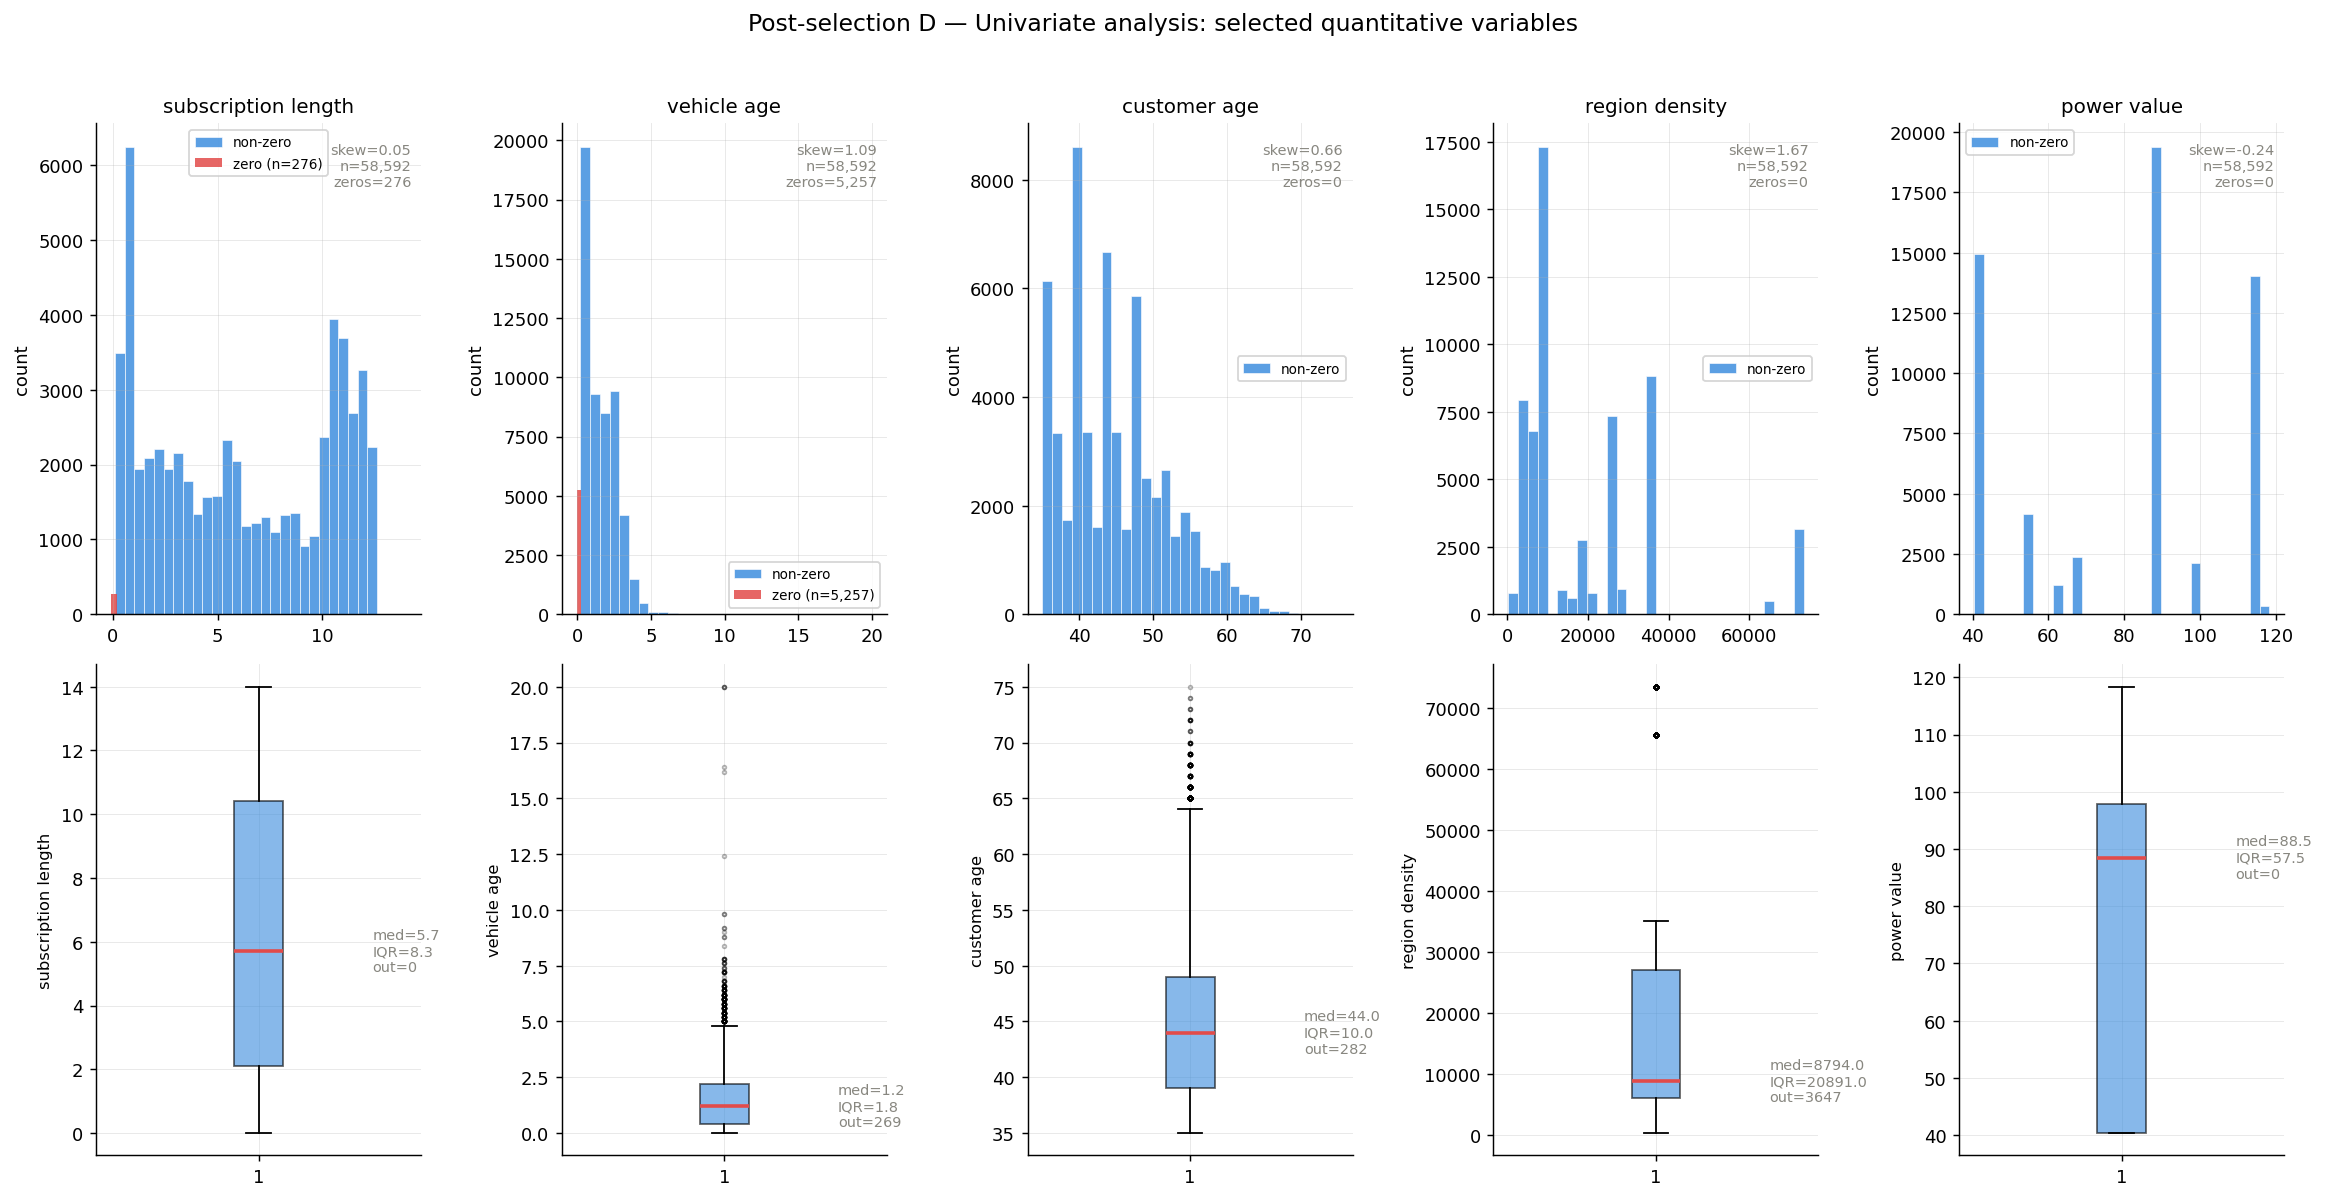


  region_code: 22 modalities
    {'C8': 13654, 'C2': 7342, 'C5': 6979, 'C3': 6101, 'C14': 3660, 'C13': 3423, 'C10': 3155, 'C9': 2734, 'C7': 2167, 'C12': 1589, 'C1': 1468, 'C11': 1212, 'C19': 952, 'C6': 890, 'C15': 771, 'C4': 665, 'C17': 492, 'C16': 401, 'C21': 379, 'C18': 242, 'C22': 207, 'C20': 109}

  width: 10 modalities
    {'1515': 14948, '1735': 14856, '1790': 14018, '1620': 4173, '1745': 2940, '1579': 2373, '1695': 2114, '1755': 1598, '1475': 1209, '1811': 363}

  segment: 6 modalities
    {'B2': 18314, 'A': 17321, 'C2': 14018, 'B1': 4173, 'C1': 3557, 'Utility': 1209}

  is_adjustable_steering: 2 modalities
    {'Yes': 35526, 'No': 23066}

  is_front_fog_lights: 2 modalities
    {'Yes': 33928, 'No': 24664}

  is_brake_assist: 2 modalities
    {'Yes': 32177, 'No': 26415}


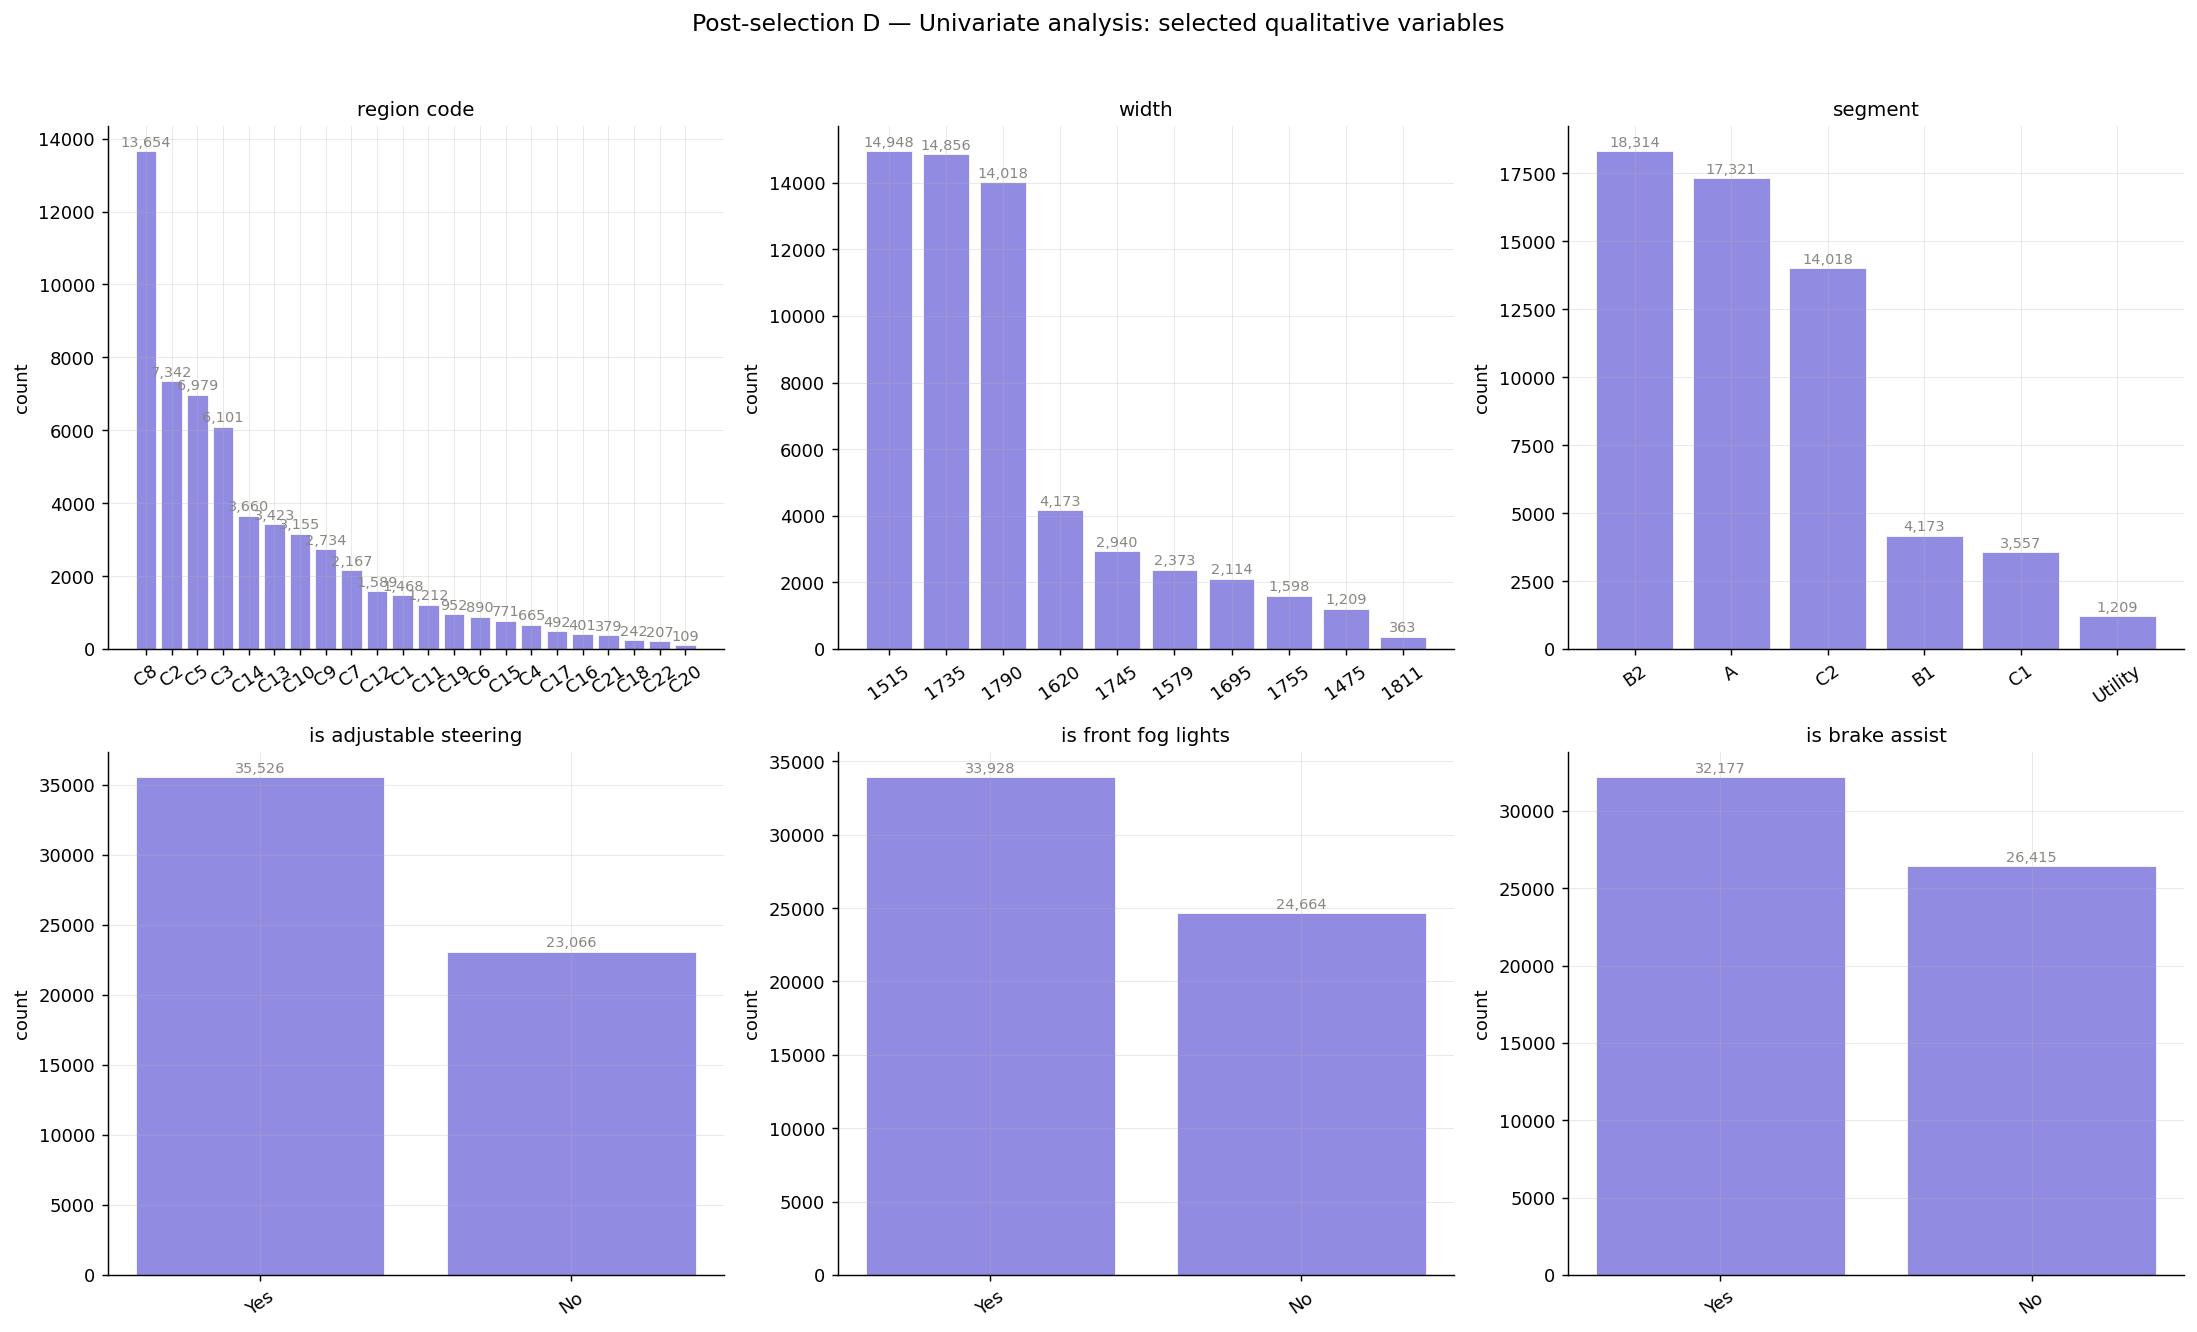

In [ ]:
print("UNIVARIATE ANALYSIS OF SELECTED VARIABLES")


SEL_QUANT = ['subscription_length', 'vehicle_age', 'customer_age', 'region_density', 'power_value']
SEL_QUAL  = ['region_code', 'width', 'segment', 'is_adjustable_steering', 'is_front_fog_lights', 'is_brake_assist']

# D1: Quantitative — histogram + box plot + stats
fig, axes = plt.subplots(2, len(SEL_QUANT), figsize=(18, 9))
for col_idx, col in enumerate(SEL_QUANT):
    ax_hist = axes[0, col_idx]
    ax_box  = axes[1, col_idx]
    data    = df[col]
    n_zeros = (data == 0).sum()

    # Histogram
    ax_hist.hist(data[data > 0], bins=30, color=BLUE, alpha=0.82,
                 edgecolor="white", linewidth=0.4, label="non-zero")
    if n_zeros > 0:
        ax_hist.axvline(0, color=RED, linewidth=0, alpha=0)
        ax_hist.bar([data[data > 0].min() * 0.5], [n_zeros],
                    width=0.3, color=RED, alpha=0.85, label=f"zero (n={n_zeros:,})")
    skew = data.skew()
    ax_hist.text(0.97, 0.96, f"skew={skew:.2f}\nn={len(data):,}\nzeros={n_zeros:,}",
                 transform=ax_hist.transAxes, ha="right", va="top",
                 fontsize=8, color=GRAY)
    ax_hist.set_title(col.replace("_", " "), fontsize=11)
    ax_hist.set_ylabel("count"); ax_hist.legend(fontsize=7.5)

    # Box plot
    bp = ax_box.boxplot(data.dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor=BLUE, alpha=0.6),
                        medianprops=dict(color=RED, linewidth=2),
                        flierprops=dict(marker="o", markersize=2,
                                        alpha=0.3, color=AMBER))
    ax_box.set_ylabel(col.replace("_", " "), fontsize=9)
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1-1.5*iqr) | (data > q3+1.5*iqr)).sum()
    ax_box.text(1.35, data.median(),
                f"med={data.median():.1f}\nIQR={iqr:.1f}\nout={n_out}",
                va="center", fontsize=8, color=GRAY)

    # Console stats
    print(f"\n  {col}:")
    print(f"    mean={data.mean():.3f}  median={data.median():.3f}  "
          f"std={data.std():.3f}  skew={data.skew():.3f}")
    print(f"    min={data.min():.3f}  max={data.max():.3f}  "
          f"zeros={n_zeros} ({n_zeros/len(data)*100:.2f}%)")

fig.suptitle("Post-selection D — Univariate analysis: selected quantitative variables",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/postD_univariate_quantitative.png")
plt.show()
plt.close()

# D2: Qualitative — bar charts
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
for i, col in enumerate(SEL_QUAL):
    ax = axes[i]
    vc = df[col].value_counts()
    ax.bar(vc.index.astype(str), vc.values, color=PURPLE, alpha=0.85,
           edgecolor="white", linewidth=0.5)
    ax.set_title(col.replace("_", " "), fontsize=11)
    ax.set_ylabel("count"); ax.tick_params(axis="x", rotation=35)
    for j, (cat, cnt) in enumerate(vc.items()):
        ax.text(j, cnt + vc.max()*0.01, f"{cnt:,}",
                ha="center", fontsize=8, color=GRAY)
    print(f"\n  {col}: {df[col].nunique()} modalities")
    print(f"    {vc.to_dict()}")

fig.suptitle("Post-selection D — Univariate analysis: selected qualitative variables",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/postD_univariate_qualitative.png")
plt.show()
plt.close()

# **variables regroupement and descritization**
Before discretizing the variables , a detailed analysis was performed to study the distribution of claim rates across its different modalities.
The objective of this analysis was to:
- identify high-risk and low-risk  categories


In [ ]:
# Grouper par power_value
power_stats = df.groupby('power_value')['claim_status'].agg([
    ('total_policies', 'count'),
    ('claims', 'sum'),
    ('non_claims', lambda x: (x == 0).sum())
]).reset_index()

# Calculer le taux de sinistre
power_stats['taux'] = (power_stats['claims'] / power_stats['total_policies'] * 100).round(2)

# Trier par taux
power_stats = power_stats.sort_values('taux', ascending=False)

# Afficher
for _, row in power_stats.iterrows():
    print(f"\nModalité: {row['power_value']}")
    print(f"  Total polices    : {row['total_policies']:>6,}")
    print(f"  Nombre de sinistres: {row['claims']:>6,}")
    print(f"  Non-sinistres    : {row['non_claims']:>6,}")
    print(f"  Taux de sinistre : {row['taux']:>5.2f}%")

# Statistiques globales
print("\n" + "-" * 50)
print(f"  Taux moyen global: {(df['claim_status'].mean() * 100):.2f}%")
print(f"  Meilleure modalité (taux min): {power_stats.iloc[-1]['power_value']} - {power_stats.iloc[-1]['taux']:.2f}%")
print(f"  Pire modalité (taux max): {power_stats.iloc[0]['power_value']} - {power_stats.iloc[0]['taux']:.2f}%")


Modalité: 88.77
  Total polices    : 1,598.0
  Nombre de sinistres:  116.0
  Non-sinistres    : 1,482.0
  Taux de sinistre :  7.26%

Modalité: 88.5
  Total polices    : 17,796.0
  Nombre de sinistres: 1,220.0
  Non-sinistres    : 16,576.0
  Taux de sinistre :  6.86%

Modalité: 113.45
  Total polices    : 14,018.0
  Nombre de sinistres:  901.0
  Non-sinistres    : 13,117.0
  Taux de sinistre :  6.43%

Modalité: 97.89
  Total polices    : 2,114.0
  Nombre de sinistres:  133.0
  Non-sinistres    : 1,981.0
  Taux de sinistre :  6.29%

Modalité: 40.36
  Total polices    : 14,948.0
  Nombre de sinistres:  918.0
  Non-sinistres    : 14,030.0
  Taux de sinistre :  6.14%

Modalité: 61.68
  Total polices    : 1,209.0
  Nombre de sinistres:   73.0
  Non-sinistres    : 1,136.0
  Taux de sinistre :  6.04%

Modalité: 55.92
  Total polices    : 4,173.0
  Nombre de sinistres:  244.0
  Non-sinistres    : 3,929.0
  Taux de sinistre :  5.85%

Modalité: 67.06
  Total polices    : 2,373.0
  Nombre de sini

In [ ]:
print("% 0s AND 1s PER MODALITY (categorical variables)")

def get_modality_table(col_name):
    # Calculate counts for each modality and claim status
    tbl = df.groupby(col_name)[TARGET].value_counts().unstack(fill_value=0)

    # Rename columns for clarity
    tbl.rename(columns={0: 'no_claim(0)', 1: 'claim(1)'}, inplace=True)

    # Calculate total policies for each modality
    tbl['total'] = tbl['no_claim(0)'] + tbl['claim(1)']

    # Calculate percentages
    tbl['pct_no_claim'] = (tbl['no_claim(0)'] / tbl['total']) * 100
    tbl['pct_claim'] = (tbl['claim(1)'] / tbl['total']) * 100

    return tbl

for i, col in enumerate(SEL_QUAL):
    ax  = axes[i]
    tbl = get_modality_table(col)
    print(f"\n  {col}:")
    print(f"  {'Modality':<22} {'No claim (0)':>12}  {'Claim (1)':>10}  "
          f"{'Total':>7}  {'% No claim':>11}  {'% Claim':>9}")
    print("  " + "─" * 75)
    for mod, row in tbl.iterrows():
        print(f"  {str(mod):<22} {int(row['no_claim(0)']):>12,}  "
              f"{int(row['claim(1)']):>10,}  {int(row['total']):>7,}  "
              f"{row['pct_no_claim']:>10.1f}%  {row['pct_claim']:>8.1f}%")

    y = np.arange(len(tbl))
    ax.barh(y, tbl["pct_no_claim"].values, height=0.55,
            color=BLUE, alpha=0.82, label="No claim (0)")
    ax.barh(y, tbl["pct_claim"].values, height=0.55,
            color=RED, alpha=0.82, left=tbl["pct_no_claim"].values,
            label="Claim (1)")
    ax.set_yticks(y)
    ax.set_yticklabels([str(m) for m in tbl.index], fontsize=8.5)
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of policies", fontsize=9)
    ax.set_title(col.replace("_", " "), fontsize=10)
    ax.axvline(100 - OVERALL_RATE*100, color=GRAY, linestyle=":", linewidth=0.8)
    for j, (_, row) in enumerate(tbl.iterrows()):
        if row["total"] > 100:
            ax.text(row["pct_no_claim"]/2, j,
                    f"{row['pct_no_claim']:.0f}%",
                    va="center", ha="center", fontsize=7.5,
                    color="white", fontweight="500")
            ax.text(row["pct_no_claim"] + row["pct_claim"]/2, j,
                    f"{row['pct_claim']:.1f}%",
                    va="center", ha="center", fontsize=7.5,
                    color="white", fontweight="500")
    if i == 0:
        ax.legend(fontsize=8, loc="lower right")

fig.suptitle("Post-selection E — % no claim (0) vs claim (1) per modality",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/postE_pct_01_per_modality.png")
plt.show()
plt.close()

% 0s AND 1s PER MODALITY (categorical variables)

  region_code:
  Modality               No claim (0)   Claim (1)    Total   % No claim    % Claim
  ───────────────────────────────────────────────────────────────────────────
  C1                            1,392          76    1,468        94.8%       5.2%
  C10                           3,007         148    3,155        95.3%       4.7%
  C11                           1,140          72    1,212        94.1%       5.9%
  C12                           1,502          87    1,589        94.5%       5.5%
  C13                           3,228         195    3,423        94.3%       5.7%
  C14                           3,379         281    3,660        92.3%       7.7%
  C15                             733          38      771        95.1%       4.9%
  C16                             378          23      401        94.3%       5.7%
  C17                             473          19      492        96.1%       3.9%
  C18                      

<Figure size 832x624 with 0 Axes>

 PROBABILITY OF DEFAULT (P(claim=1)) PER MODALITY

  Overall probability of default: P(claim=1) = 0.06397 = 6.40%


  region_code:
  Modality                 P(default)      Lift  Interpretation
  ─────────────────────────────────────────────────────────────────
  C1                          0.05177     0.809x  Low risk
  C10                         0.04691     0.733x  Low risk
  C11                         0.05941     0.929x  Average risk
  C12                         0.05475     0.856x  Average risk
  C13                         0.05697     0.891x  Average risk
  C14                         0.07678     1.200x  HIGH RISK
  C15                         0.04929     0.770x  Low risk
  C16                         0.05736     0.897x  Average risk
  C17                         0.03862     0.604x  Low risk
  C18                         0.10744     1.680x  HIGH RISK
  C19                         0.07458     1.166x  HIGH RISK
  C2                          0.07083     1.107x  Average risk
  C20 

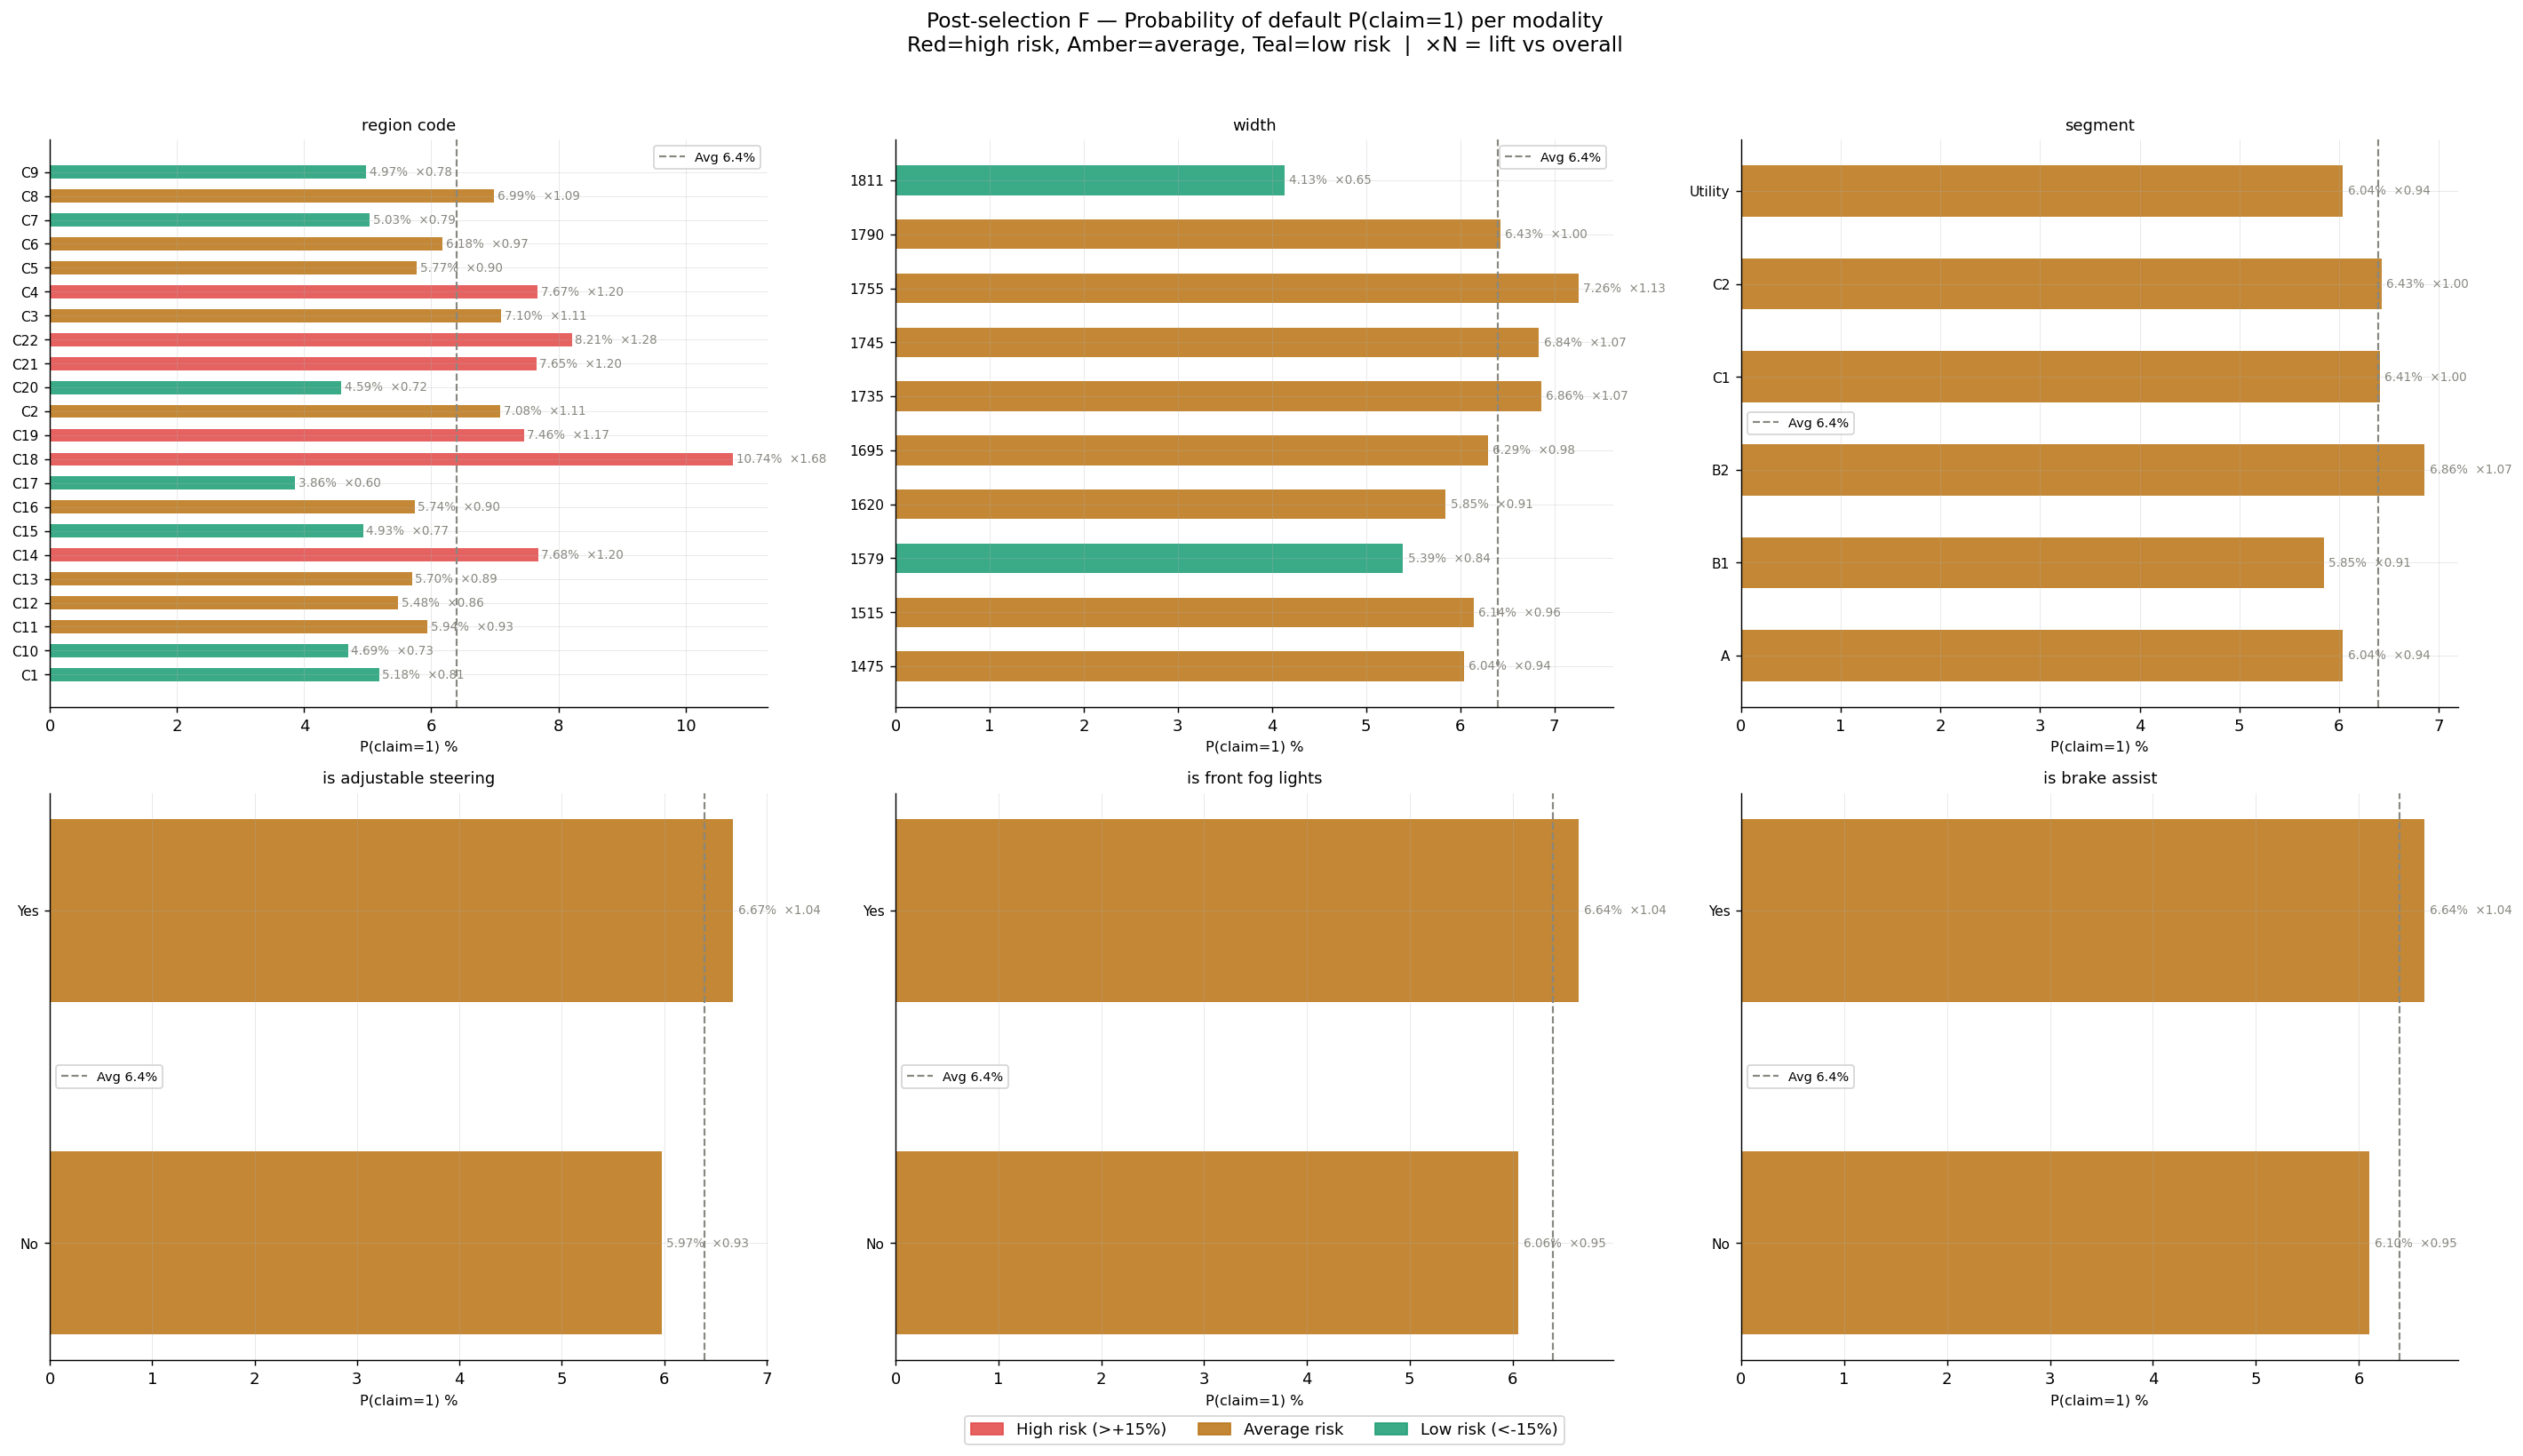

In [ ]:
print(" PROBABILITY OF DEFAULT (P(claim=1)) PER MODALITY")
print(f"\n  Overall probability of default: P(claim=1) = {OVERALL_RATE:.5f} "
      f"= {OVERALL_RATE*100:.2f}%\n")

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(SEL_QUAL):
    ax  = axes[i]
    tbl = get_modality_table(col)
    tbl["prob_default"] = tbl["claim(1)"] / tbl["total"]
    tbl["lift"]         = tbl["prob_default"] / OVERALL_RATE

    print(f"\n  {col}:")
    print(f"  {'Modality':<22} {'P(default)':>12}  {'Lift':>8}  {'Interpretation'}")
    print("  " + "─" * 65)
    for mod, row in tbl.iterrows():
        lift     = row["lift"]
        interp   = ("HIGH RISK" if lift > 1.15 else
                    "Low risk"  if lift < 0.85 else "Average risk")
        print(f"  {str(mod):<22} {row['prob_default']:>12.5f}  {lift:>8.3f}x  {interp}")

    y  = np.arange(len(tbl))
    colors = [RED if r > OVERALL_RATE*1.15 else
              TEAL if r < OVERALL_RATE*0.85 else AMBER
              for r in tbl["prob_default"]]
    bars = ax.barh(y, tbl["prob_default"].values * 100,
                   color=colors, alpha=0.87, height=0.55)
    ax.axvline(OVERALL_RATE*100, color=GRAY, linestyle="--", linewidth=1.2,
               label=f"Avg {OVERALL_RATE*100:.1f}%")
    ax.set_yticks(y)
    ax.set_yticklabels([str(m) for m in tbl.index], fontsize=8.5)
    ax.set_xlabel("P(claim=1) %", fontsize=9)
    ax.set_title(col.replace("_", " "), fontsize=10)
    ax.legend(fontsize=8)
    for bar, (_, row) in zip(bars, tbl.iterrows()):
        w = bar.get_width()
        ax.text(w + 0.05, bar.get_y() + bar.get_height()/2,
                f"{w:.2f}%  ×{row['lift']:.2f}",
                va="center", fontsize=7.5, color=GRAY)

h1 = mpatches.Patch(color=RED,   alpha=0.87, label="High risk (>+15%)")
h2 = mpatches.Patch(color=AMBER, alpha=0.87, label="Average risk")
h3 = mpatches.Patch(color=TEAL,  alpha=0.87, label="Low risk (<-15%)")
fig.legend(handles=[h1, h2, h3], loc="lower center", ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Post-selection F — Probability of default P(claim=1) per modality\n"
             "Red=high risk, Amber=average, Teal=low risk  |  ×N = lift vs overall",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/postF_probability_of_default.png")
plt.show()
plt.close()


--------------------------------------------------------------------------------
1. DISCRÉTISATION DES VARIABLES NUMÉRIQUES
--------------------------------------------------------------------------------
   0-1.4        : n=11,435  |  taux=3.56%  |  lift=0.56x
   1.4-4.2      : n=11,725  |  taux=4.72%  |  lift=0.74x
   4.2-7        : n= 9,979  |  taux=6.59%  |  lift=1.03x
   7-9.8        : n= 7,056  |  taux=8.15%  |  lift=1.27x
   9.8-11.2     : n= 9,477  |  taux=8.49%  |  lift=1.33x
   11.2+        : n= 8,920  |  taux=8.40%  |  lift=1.31x
   0               : n= 5,257  |  taux=10.63%  |  lift=1.66x
   0-1 yrs         : n=19,729  |  taux=5.72%  |  lift=0.89x
   1-2 yrs         : n=14,656  |  taux=6.68%  |  lift=1.04x
   2+ yrs          : n=18,950  |  taux=5.71%  |  lift=0.89x
   35-39        : n=14,698  |  taux=5.54%  |  lift=0.87x
   40-43        : n=13,476  |  taux=6.30%  |  lift=0.98x
   43-47        : n=11,298  |  taux=6.97%  |  lift=1.09x
   48-55        : n=13,975  |  taux=6.50

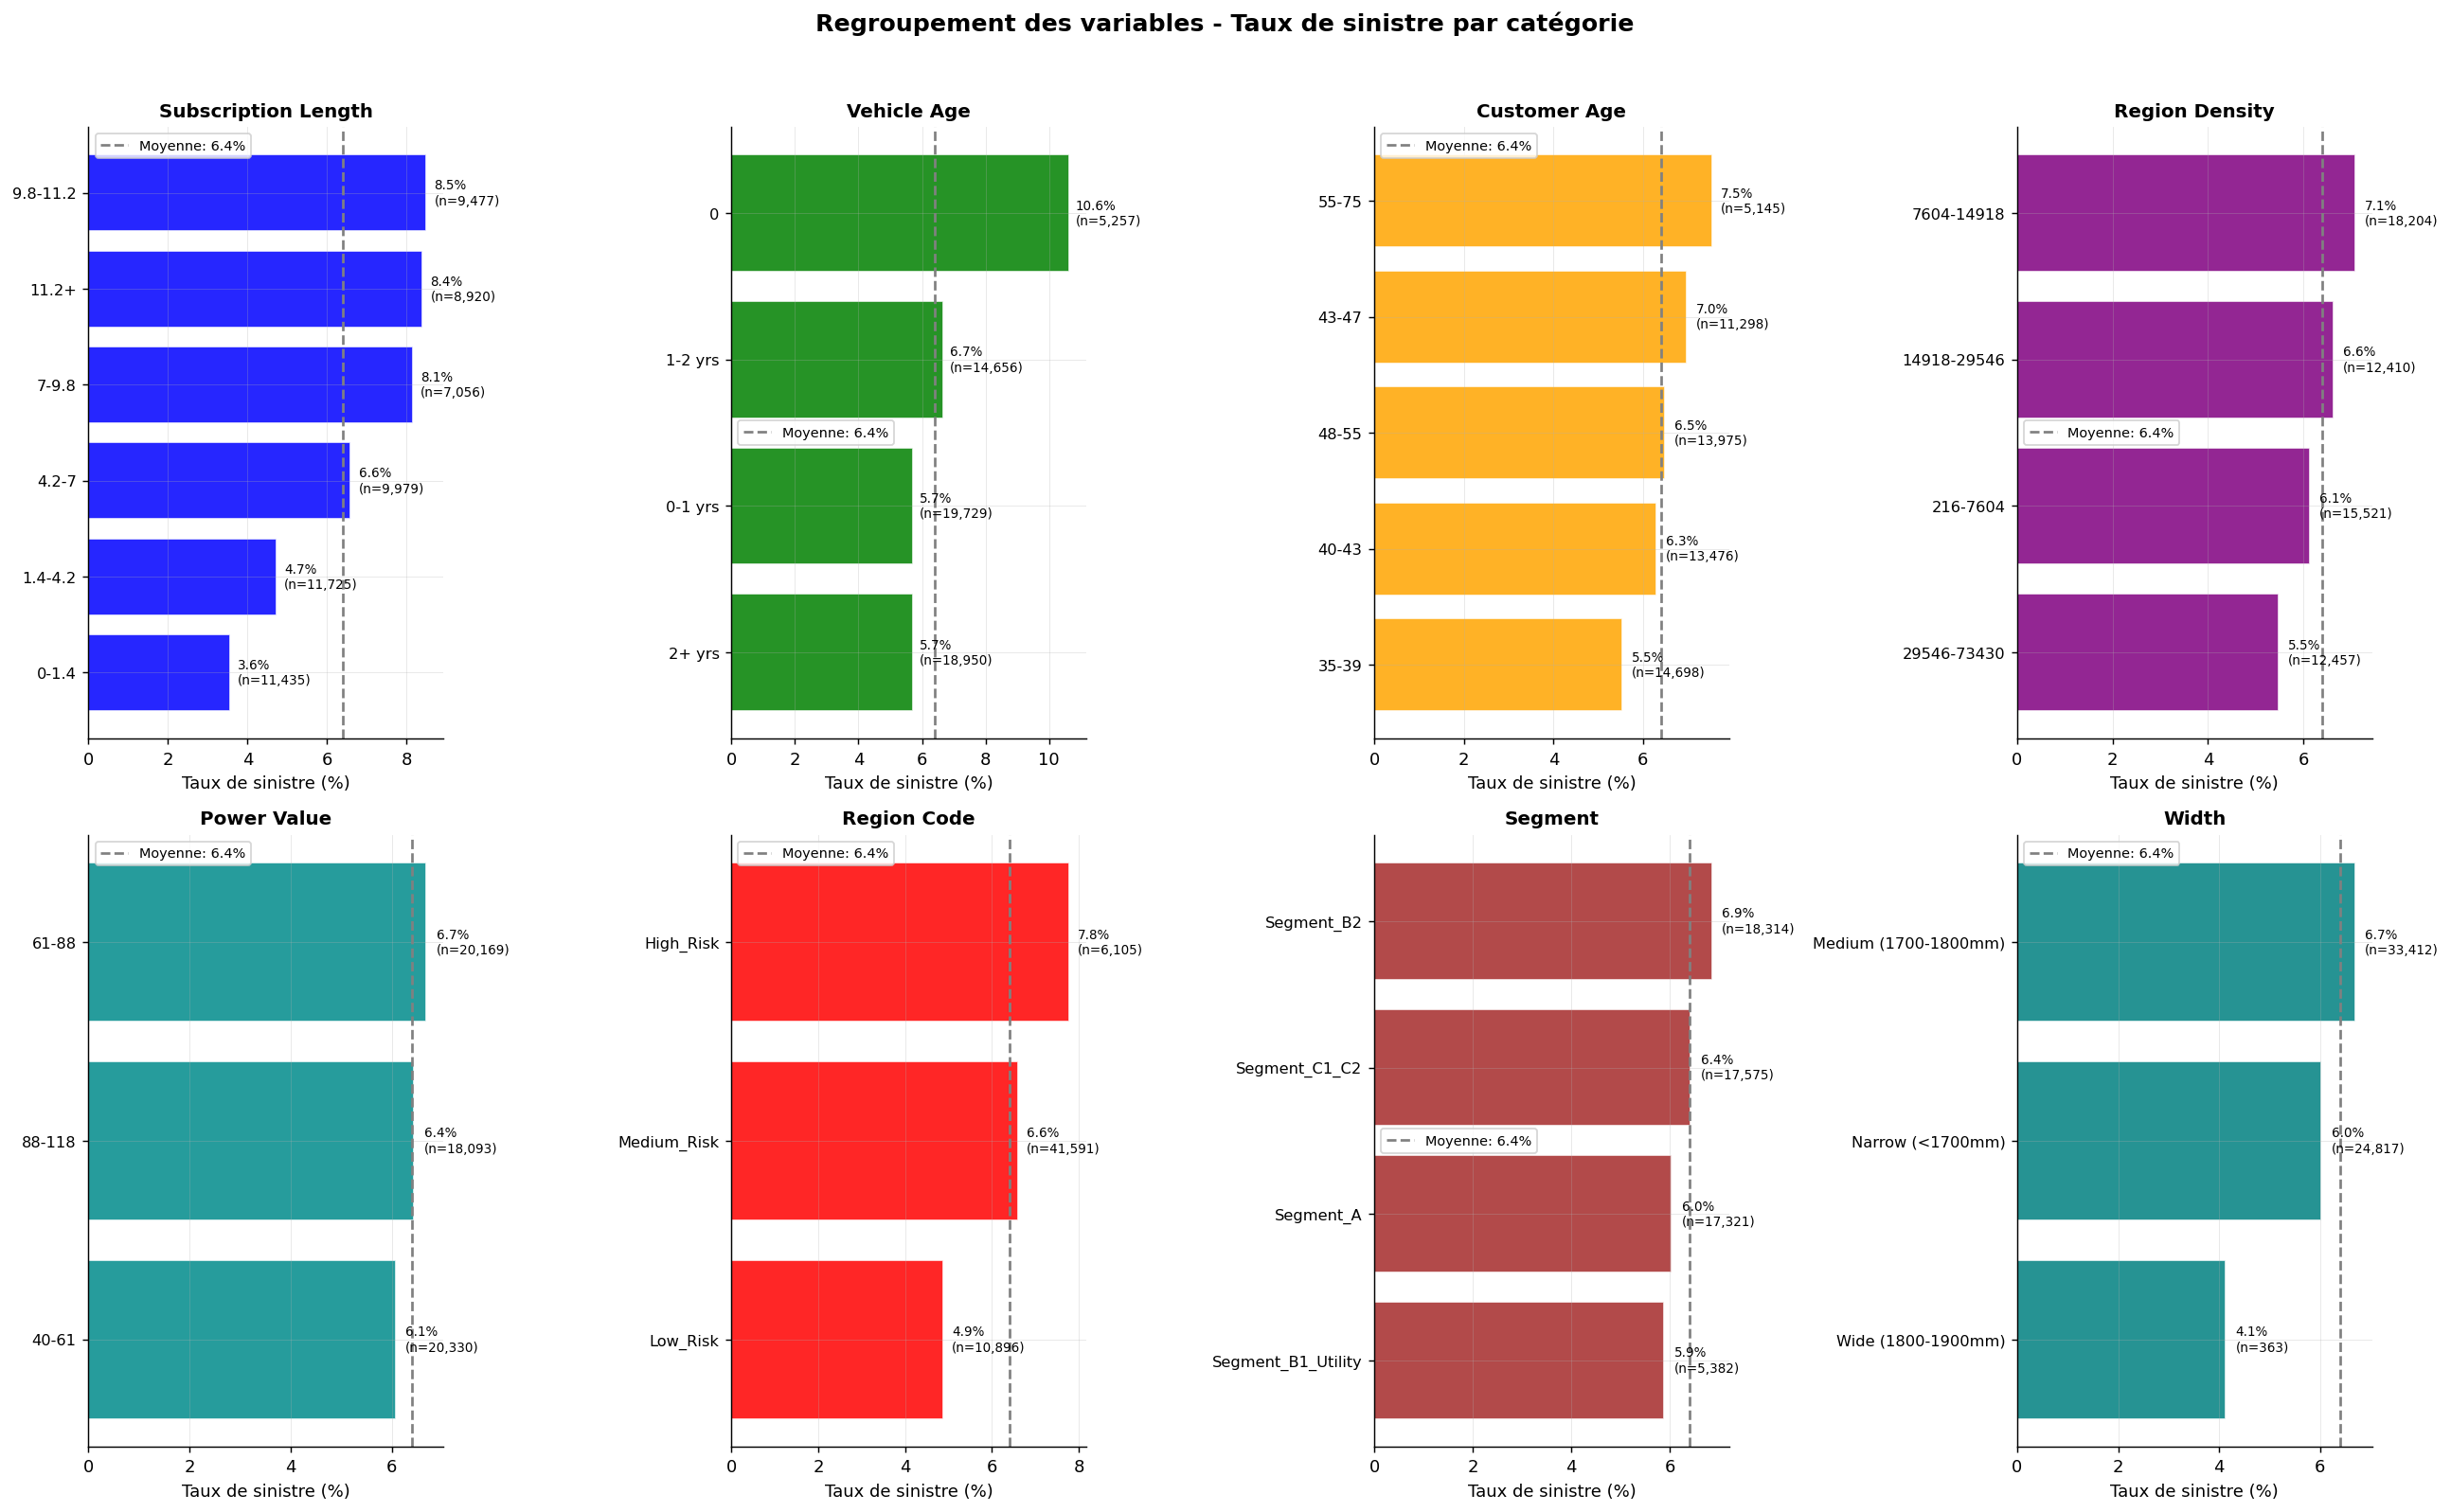


✓ Graphique sauvegardé: step1_output/regroupement_variables.png

--------------------------------------------------------------------------------
5. TABLEAU RÉCAPITULATIF DES TRANSFORMATIONS
--------------------------------------------------------------------------------
           Variable         Type  Classes originales  Classes après transformation    Colonne créée
subscription_length Quantitative                 140                             6 sub_length_group
        vehicle_age Quantitative                  49                             4    veh_age_group
       customer_age Quantitative                  41                             5   cust_age_group
     region_density Quantitative                  22                             4    density_group
        power_value Quantitative                   9                             3      power_group
        region_code  Categorical                  22                             3   region_grouped
            segment  Catego

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================================
# DISCRÉTISATION DES VARIABLES NUMÉRIQUES & REGROUPEMENT DES VARIABLES CATÉGORIELLES
# ============================================================================



OVERALL_RATE = df['claim_status'].mean()

# ============================================================================
# 1. DISCRÉTISATION DES VARIABLES NUMÉRIQUES
# ============================================================================

print("\n" + "-"*80)
print("1. DISCRÉTISATION DES VARIABLES NUMÉRIQUES")
print("-"*80)

# 1.1 subscription_length: 6 classes selon vos spécifications
df['sub_length_group'] = pd.cut(
    df['subscription_length'],
    bins=[0, 1.4, 4.2, 7, 9.8, 11.2, float('inf')],
    labels=['0-1.4', '1.4-4.2', '4.2-7', '7-9.8', '9.8-11.2', '11.2+'],
    right=False
)


sub_stats = df.groupby('sub_length_group', observed=True)['claim_status'].agg(['mean', 'count'])
sub_stats['claim_rate'] = sub_stats['mean'] * 100
for group, row in sub_stats.iterrows():
    print(f"   {group:<12} : n={int(row['count']):>6,}  |  taux={row['claim_rate']:.2f}%  |  lift={row['mean']/OVERALL_RATE:.2f}x")

# 1.2 vehicle_age: 4 classes
def discretize_vehicle_age(age):
    if age == 0:
        return '0'
    elif age < 1:
        return '0-1 yrs'
    elif age < 2:
        return '1-2 yrs'
    else:
        return '2+ yrs'

df['veh_age_group'] = df['vehicle_age'].apply(discretize_vehicle_age)


veh_stats = df.groupby('veh_age_group', observed=True)['claim_status'].agg(['mean', 'count'])
veh_stats['claim_rate'] = veh_stats['mean'] * 100
order = ['0', '0-1 yrs', '1-2 yrs', '2+ yrs']
for group in order:
    if group in veh_stats.index:
        row = veh_stats.loc[group]
        print(f"   {group:<15} : n={int(row['count']):>6,}  |  taux={row['claim_rate']:.2f}%  |  lift={row['mean']/OVERALL_RATE:.2f}x")

# 1.3 customer_age: 5 classes
df['cust_age_group'] = pd.cut(
    df['customer_age'],
    bins=[34.9, 39, 43, 47, 55, 75],
    labels=['35-39', '40-43', '43-47', '48-55', '55-75'],
    right=True
)


cust_stats = df.groupby('cust_age_group', observed=True)['claim_status'].agg(['mean', 'count'])
cust_stats['claim_rate'] = cust_stats['mean'] * 100
for group, row in cust_stats.iterrows():
    print(f"   {group:<12} : n={int(row['count']):>6,}  |  taux={row['claim_rate']:.2f}%  |  lift={row['mean']/OVERALL_RATE:.2f}x")

# 1.4 region_density: 4 classes
df['density_group'] = pd.cut(
    df['region_density'],
    bins=[216.8, 7604, 14918, 29546, 73430],
    labels=['216-7604', '7604-14918', '14918-29546', '29546-73430'],
    right=True
)


density_stats = df.groupby('density_group', observed=True)['claim_status'].agg(['mean', 'count'])
density_stats['claim_rate'] = density_stats['mean'] * 100
for group, row in density_stats.iterrows():
    print(f"   {group:<15} : n={int(row['count']):>6,}  |  taux={row['claim_rate']:.2f}%  |  lift={row['mean']/OVERALL_RATE:.2f}x")


df['power_group'] = pd.cut(
    df['power_value'],
    bins=[40.36, 61.68, 88.5, 118.36],
    labels=['40-61', '61-88', '88-118'],
    right=True , include_lowest=True
)


density_stats = df.groupby('power_group', observed=True)['claim_status'].agg(['mean', 'count'])
density_stats['claim_rate'] = density_stats['mean'] * 100
for group, row in density_stats.iterrows():
    print(f"   {group:<15} : n={int(row['count']):>6,}  |  taux={row['claim_rate']:.2f}%  |  lift={row['mean']/OVERALL_RATE:.2f}x")








# ============================================================================
# 2. REGROUPEMENT DES VARIABLES CATÉGORIELLES
# ============================================================================


# 2.1 region_code: regroupement High risk / Low risk / Medium risk
# D'abord calculer les taux par région
region_rates = df.groupby('region_code')['claim_status'].mean()

# Définir les seuils (à ajuster selon vos données)
high_risk_threshold = OVERALL_RATE * 1.15  # +15% au-dessus de la moyenne
low_risk_threshold = OVERALL_RATE * 0.85   # -15% en dessous de la moyenne

def group_region(region):
    rate = region_rates.get(region, OVERALL_RATE)
    if rate > high_risk_threshold:
        return 'High_Risk'
    elif rate < low_risk_threshold:
        return 'Low_Risk'
    else:
        return 'Medium_Risk'

df['region_grouped'] = df['region_code'].apply(group_region)


region_group_stats = df.groupby('region_grouped', observed=True)['claim_status'].agg(['mean', 'count'])
region_group_stats['claim_rate'] = region_group_stats['mean'] * 100
for group, row in region_group_stats.iterrows():
    print(f"   {group:<12} : n={int(row['count']):>6,}  |  taux={row['claim_rate']:.2f}%  |  lift={row['mean']/OVERALL_RATE:.2f}x")

# Afficher la composition des groupes
print("\n   Composition des groupes de régions:")
for group in ['High_Risk', 'Medium_Risk', 'Low_Risk']:
    regions = df[df['region_grouped'] == group]['region_code'].unique()
    print(f"      {group}: {sorted(regions)}")

# 2.2 segment: regroupement en 4 groupes (A, B2, B1+Utility, C1+C2)
def group_segment(seg):
    if seg == 'A':
        return 'Segment_A'
    elif seg == 'B2':
        return 'Segment_B2'
    elif seg in ['B1', 'Utility']:
        return 'Segment_B1_Utility'
    elif seg in ['C1', 'C2']:
        return 'Segment_C1_C2'
    else:
        return 'Other'

df['segment_grouped'] = df['segment'].apply(group_segment)


seg_group_stats = df.groupby('segment_grouped', observed=True)['claim_status'].agg(['mean', 'count'])
seg_group_stats['claim_rate'] = seg_group_stats['mean'] * 100
for group, row in seg_group_stats.iterrows():
    print(f"   {group:<18} : n={int(row['count']):>6,}  |  taux={row['claim_rate']:.2f}%  |  lift={row['mean']/OVERALL_RATE:.2f}x")

# ============================================================================
# 3. REGROUPEMENT DE width (MODALITÉS AVEC DISTRIBUTIONS PROCHES)
# ============================================================================


# Convert 'width' back to numeric if it was converted to string elsewhere
# This is necessary for pd.cut to work properly
if df['width'].dtype == 'object':
    df['width'] = pd.to_numeric(df['width'], errors='coerce')

# Analyser d'abord les taux par largeur
df['width_bin'] = pd.cut(df['width'], bins=10)
width_rates = df.groupby('width_bin', observed=True)['claim_status'].mean()

print("\n   Taux de sinistre par intervalle de largeur:")
for interval, rate in width_rates.items():
    print(f"      {interval}: {rate*100:.2f}%  (lift={rate/OVERALL_RATE:.2f}x)")

# Regroupement basé sur des taux similaires
def group_width(width):
    if width < 1700:
        return 'Narrow (<1700mm)'
    elif width < 1800:
        return 'Medium (1700-1800mm)'
    elif width < 1900:
        return 'Wide (1800-1900mm)'
    else:
        return 'Extra Wide (>1900mm)'

df['width_grouped'] = df['width'].apply(group_width)


width_group_stats = df.groupby('width_grouped', observed=True)['claim_status'].agg(['mean', 'count'])
width_group_stats['claim_rate'] = width_group_stats['mean'] * 100
order = ['Narrow (<1700mm)', 'Medium (1700-1800mm)', 'Wide (1800-1900mm)', 'Extra Wide (>1900mm)']
for group in order:
    if group in width_group_stats.index:
        row = width_group_stats.loc[group]
        print(f"   {group:<20} : n={int(row['count']):>6,}  |  taux={row['claim_rate']:.2f}%  |  lift={row['mean']/OVERALL_RATE:.2f}x")

# ============================================================================
# 4. VISUALISATION DES RÉSULTATS
# ============================================================================



# Créer une figure avec tous les regroupements
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

# Liste de tous les regroupements à visualiser
groupings = [
    ('sub_length_group', 'subscription_length', 'blue'),
    ('veh_age_group', 'vehicle_age', 'green'),
    ('cust_age_group', 'customer_age', 'orange'),
    ('density_group', 'region_density', 'purple'),
    ('power_group', 'power_value', 'darkcyan'),
    ('region_grouped', 'region_code', 'red'),
    ('segment_grouped', 'segment', 'brown'),
    ('width_grouped', 'width', 'teal'),
]

for idx, (col, original, color) in enumerate(groupings):
    ax = axes[idx]

    # Calculer les taux
    stats = df.groupby(col, observed=True)['claim_status'].agg(['mean', 'count'])
    stats['claim_rate'] = stats['mean'] * 100
    stats = stats.sort_values('mean')

    # Créer les barres
    bars = ax.barh(range(len(stats)), stats['claim_rate'],
                   color=color, alpha=0.85, edgecolor='white')
    ax.axvline(OVERALL_RATE*100, color='gray', linestyle='--',
               linewidth=1.5, label=f'Moyenne: {OVERALL_RATE*100:.1f}%')

    # Ajouter les labels
    ax.set_yticks(range(len(stats)))
    ax.set_yticklabels(stats.index, fontsize=9)
    ax.set_xlabel('Taux de sinistre (%)')
    ax.set_title(f'{original.replace("_", " ").title()}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

    # Ajouter les valeurs sur les barres
    for bar, (idx_row, row) in zip(bars, stats.iterrows()):
        w = bar.get_width()
        ax.text(w + 0.2, bar.get_y() + bar.get_height()/2,
                f'{w:.1f}%\n(n={int(row["count"]):,})',
                va='center', fontsize=7.5)

fig.suptitle('Regroupement des variables - Taux de sinistre par catégorie',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/regroupement_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Graphique sauvegardé: {OUT_DIR}/regroupement_variables.png")

# ============================================================================
# 5. TABLEAU RÉCAPITULATIF
# ============================================================================

print("\n" + "-"*80)
print("5. TABLEAU RÉCAPITULATIF DES TRANSFORMATIONS")
print("-"*80)

summary_data = []
for col, grouped_col in [
    ('subscription_length', 'sub_length_group'),
    ('vehicle_age', 'veh_age_group'),
    ('customer_age', 'cust_age_group'),
    ('region_density', 'density_group'),
    ('power_value', 'power_group'),
    ('region_code', 'region_grouped'),
    ('segment', 'segment_grouped'),
    ('width', 'width_grouped')
]:
    original_cats = df[col].nunique()
    new_cats = df[grouped_col].nunique()

    current_type = 'Quantitative' if df[col].dtype in ['int64', 'float64'] else 'Categorical'

    summary_data.append({
        'Variable': col,
        'Type': current_type,
        'Classes originales': original_cats,
        'Classes après transformation': new_cats,
        'Colonne créée': grouped_col
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

In [ ]:
columns_to_keep = [
    # Identifiant
    'policy_id',

    # Target
    'claim_status',

    # Variables quantitatives discrétisées
    'sub_length_group',      # subscription_length groupé
    'veh_age_group',          # vehicle_age groupé
    'cust_age_group',         # customer_age groupé
    'density_group',          # region_density groupé
    'power_group',            # power_value groupé


    # Variables catégorielles regroupées
    'region_grouped',         # region_code groupé
    'segment_grouped',        # segment groupé
    'width_grouped',          # width groupé

    # Variables binaires supplémentaires
    'is_adjustable_steering',
    'is_front_fog_lights',
    'is_brake_assist'
]
df_final = df[columns_to_keep].copy()
output_file = 'insurance_data_grouped.csv'
df_final.to_csv(output_file, index=False)

In [ ]:
df_final.head()

,policy_id,claim_status,sub_length_group,veh_age_group,cust_age_group,density_group,power_group,region_grouped,segment_grouped,width_grouped,is_adjustable_steering,is_front_fog_lights,is_brake_assist
0,POL045360,0,7-9.8,1-2 yrs,40-43,7604-14918,88-118,Medium_Risk,Segment_C1_C2,Medium (1700-1800mm),Yes,Yes,Yes
1,POL016745,0,7-9.8,1-2 yrs,35-39,14918-29546,88-118,Medium_Risk,Segment_C1_C2,Narrow (<1700mm),Yes,Yes,No
2,POL007194,0,7-9.8,0-1 yrs,43-47,7604-14918,88-118,Medium_Risk,Segment_C1_C2,Medium (1700-1800mm),Yes,Yes,Yes
3,POL018146,0,4.2-7,0-1 yrs,43-47,29546-73430,40-61,Low_Risk,Segment_A,Narrow (<1700mm),No,No,No
4,POL049011,0,9.8-11.2,1-2 yrs,55-75,216-7604,88-118,Medium_Risk,Segment_B2,Medium (1700-1800mm),Yes,No,No


In [ ]:
m = df_final.isnull().sum()
print (m)

policy_id                 0
claim_status              0
sub_length_group          0
veh_age_group             0
cust_age_group            0
density_group             0
power_group               0
region_grouped            0
segment_grouped           0
width_grouped             0
is_adjustable_steering    0
is_front_fog_lights       0
is_brake_assist           0
dtype: int64


# **variables encoding**
After the discretization phase, several variables were transformed into more interpretable and business-oriented categories through feature encoding.

The objective of this transformation was to:
- simplify variable interpretation
- create homogeneous risk profiles

In [ ]:
df_encoded = df_final.copy()
binary_cols = ['is_adjustable_steering', 'is_front_fog_lights', 'is_brake_assist']
# --- A. ANCIENNETÉ DU CONTRAT (subscription_length) ---
# Basé sur votre analyse: les extrêmes (0 et 11.2+) ont plus de risque
df_encoded['tenure_profile'] = df_encoded['sub_length_group'].map({
    '0': 'Ultra_Short_Tenure',           # Très court: risque élevé (lift 1.66)
    '0-1.4': 'New_Customer',              # Nouveau: risque faible (lift 0.56)
    '1.4-4.2': 'Stabilizing',             # En stabilisation (lift 0.74)
    '4.2-7': 'Mature',                    # Mature: risque moyen (lift 1.03)
    '7-9.8': 'Loyal',                     # Loyal: risque élevé (lift 1.27)
    '9.8-11.2': 'Super_Loyal',            # Super loyal: risque très élevé (lift 1.33)
    '11.2+': 'Veteran'                    # Vétéran: risque élevé (lift 1.31)
})

# --- B. ÂGE DU VÉHICULE (vehicle_age) ---
df_encoded['vehicle_condition'] = df_encoded['veh_age_group'].map({
    '0': 'New',
    '0-1 yrs': 'Almost_New',      # Presque neuf: risque bas (lift 0.89)
    '1-2 yrs': 'Young',           # Jeune: risque moyen (lift 1.04)
    '2+ yrs': 'Aging'             # Vieillissant: risque bas (lift 0.89)
})

# --- C. ÂGE DU CLIENT (customer_age) ---
df_encoded['driver_experience'] = df_encoded['cust_age_group'].map({
    '35-39': 'Young_Driver',       # Jeune conducteur: risque bas (lift 0.87)
    '40-43': 'Experienced',        # Expérimenté (lift 0.98)
    '43-47': 'Senior_Driver',      # Senior: risque élevé (lift 1.09)
    '48-55': 'Very_Experienced',   # Très expérimenté (lift 1.02)
    '55-75': 'Elderly_Driver'      # Âgé: risque élevé (lift 1.18)
})

# --- D. DENSITÉ DE LA RÉGION (region_density) ---
df_encoded['area_type'] = df_encoded['density_group'].map({
    '216-7604': 'Rural',           # Rural: risque bas (lift 0.96)
    '7604-14918': 'Suburban',      # Périurbain: risque élevé (lift 1.11)
    '14918-29546': 'Urban',        # Urbain: risque moyen (lift 1.04)
    '29546-73430': 'Metropolitan'  # Métropole: risque bas (lift 0.86)
})

# --- E. PUISSANCE (max_power) ---
df_encoded['power_profile'] = df_encoded['power_group'].map({
    '40-61': 'Standard_Power',
    '61-88': 'High_Power',
    '88-118': 'Sports_Power'

})

# --- F. RÉGION GÉOGRAPHIQUE (region_code) - déjà groupée ---
df_encoded['risk_zone'] = df_encoded['region_grouped'].map({
    'High_Risk': 'Hot_Zone',      # Zone chaude: risque élevé
    'Medium_Risk': 'Warm_Zone',   # Zone tiède: risque moyen
    'Low_Risk': 'Cold_Zone'       # Zone froide: risque bas
})

# --- G. SEGMENT DE VÉHICULE ---
df_encoded['vehicle_class'] = df_encoded['segment_grouped'].map({
    'Segment_A': 'Micro_Car',           # Petite citadine
    'Segment_B1_Utility': 'Utility_Car', # Utilitaire
    'Segment_B2': 'Compact_Car',        # Compacte
    'Segment_C1_C2': 'Family_Car'       # Familiale
})

# --- H. LARGEUR DU VÉHICULE ---
df_encoded['car_stance'] = df_encoded['width_grouped'].map({
    'Narrow (<1700mm)': 'Slim_Profile',     # Profil fin
    'Medium (1700-1800mm)': 'Standard',     # Standard
    'Wide (1800-1900mm)': 'Wide_Body'       # Large
})

# Convert binary_cols from 'Yes'/'No' to 1/0
binary_mapping = {'Yes': 1, 'No': 0}
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map(binary_mapping).astype(int)

df_encoded.head()

,policy_id,claim_status,sub_length_group,veh_age_group,cust_age_group,density_group,power_group,region_grouped,segment_grouped,width_grouped,is_adjustable_steering,is_front_fog_lights,is_brake_assist,tenure_profile,vehicle_condition,driver_experience,area_type,power_profile,risk_zone,vehicle_class,car_stance
0,POL045360,0,7-9.8,1-2 yrs,40-43,7604-14918,88-118,Medium_Risk,Segment_C1_C2,Medium (1700-1800mm),1,1,1,Loyal,Young,Experienced,Suburban,Sports_Power,Warm_Zone,Family_Car,Standard
1,POL016745,0,7-9.8,1-2 yrs,35-39,14918-29546,88-118,Medium_Risk,Segment_C1_C2,Narrow (<1700mm),1,1,0,Loyal,Young,Young_Driver,Urban,Sports_Power,Warm_Zone,Family_Car,Slim_Profile
2,POL007194,0,7-9.8,0-1 yrs,43-47,7604-14918,88-118,Medium_Risk,Segment_C1_C2,Medium (1700-1800mm),1,1,1,Loyal,Almost_New,Senior_Driver,Suburban,Sports_Power,Warm_Zone,Family_Car,Standard
3,POL018146,0,4.2-7,0-1 yrs,43-47,29546-73430,40-61,Low_Risk,Segment_A,Narrow (<1700mm),0,0,0,Mature,Almost_New,Senior_Driver,Metropolitan,Standard_Power,Cold_Zone,Micro_Car,Slim_Profile
4,POL049011,0,9.8-11.2,1-2 yrs,55-75,216-7604,88-118,Medium_Risk,Segment_B2,Medium (1700-1800mm),1,0,0,Super_Loyal,Young,Elderly_Driver,Rural,Sports_Power,Warm_Zone,Compact_Car,Standard


In [ ]:
# List of the 13 columns to keep
final_columns = [
    'policy_id',
    'claim_status',
    'is_adjustable_steering',
    'is_front_fog_lights',
    'is_brake_assist',
    'tenure_profile',
    'vehicle_condition',
    'driver_experience',
    'area_type',
    'power_profile',
    'risk_zone',
    'vehicle_class',
    'car_stance'
]

# Filtering the dataframe
df_encoded = df_encoded[final_columns]

# Displaying the result
print(f"Final shape: {df_encoded.shape}")
output_file = 'insurance_data_encoded.csv'
df_encoded.to_csv(output_file, index=False)
df_encoded.head()

Final shape: (58592, 13)


,policy_id,claim_status,is_adjustable_steering,is_front_fog_lights,is_brake_assist,tenure_profile,vehicle_condition,driver_experience,area_type,power_profile,risk_zone,vehicle_class,car_stance
0,POL045360,0,1,1,1,Loyal,Young,Experienced,Suburban,Sports_Power,Warm_Zone,Family_Car,Standard
1,POL016745,0,1,1,0,Loyal,Young,Young_Driver,Urban,Sports_Power,Warm_Zone,Family_Car,Slim_Profile
2,POL007194,0,1,1,1,Loyal,Almost_New,Senior_Driver,Suburban,Sports_Power,Warm_Zone,Family_Car,Standard
3,POL018146,0,0,0,0,Mature,Almost_New,Senior_Driver,Metropolitan,Standard_Power,Cold_Zone,Micro_Car,Slim_Profile
4,POL049011,0,1,0,0,Super_Loyal,Young,Elderly_Driver,Rural,Sports_Power,Warm_Zone,Compact_Car,Standard


In [ ]:
m = df_encoded.isnull().sum()
print (m)

policy_id                 0
claim_status              0
is_adjustable_steering    0
is_front_fog_lights       0
is_brake_assist           0
tenure_profile            0
vehicle_condition         0
driver_experience         0
area_type                 0
power_profile             0
risk_zone                 0
vehicle_class             0
car_stance                0
dtype: int64


# logistic regression

Why Logistic Regression?
we are solving a binary classification problem
Logistic Regression is appropriate because it predicts:
P(claim=1∣X)

* Machine learning models cannot directly process text categories so they must be converted into numerical format using on hot encoding(get.dummies)
* Before Encoding i first first computed claim rate per modality for each variable then sorted modalities based on highest-risk first .  the FIRST modality becomes:the reference modality And Logistic Regression coefficients are interpreted: relative to the reference.
* Logistic Regression predicts:probabilities not classes directly
so A classification threshold of 0.5 was used To convert probabilities into final classes:

- probability ≥ 0.5 → predicted claim
- probability < 0.5 → predicted non-claim

This threshold can later be adjusted depending on the desired tradeoff between precision and recall.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss, ConfusionMatrixDisplay, f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.calibration import calibration_curve
from scipy.stats import ks_2samp
from sklearn.pipeline import Pipeline
import warnings


categorical_cols = [
    'tenure_profile',
    'vehicle_condition',
    'driver_experience',
    'area_type',
    'power_profile',
    'risk_zone',
    'vehicle_class',
    'car_stance'
]
binary_cols = ['is_adjustable_steering', 'is_front_fog_lights', 'is_brake_assist']

warnings.filterwarnings('ignore')
# on hot encoding and choosing reference modality
for col in categorical_cols:
    # get claim rate per category
    risk_order = (df_encoded.groupby(col)['claim_status']
                             .mean()
                             .sort_values(ascending=False)  # highest risk first
                             .index.tolist())

    # convert to ordered Categorical with highest-risk first
    df_encoded[col] = pd.Categorical(df_encoded[col], categories=risk_order, ordered=True)

# Now drop_first=True drops the first category = highest risk = correct reference
df_dummies = pd.get_dummies(df_encoded[categorical_cols], drop_first=True, dtype=int)

# Print which reference was chosen for each variable
print("Reference modalities (highest risk = dropped):")
for col in categorical_cols:
    ref = df_encoded[col].cat.categories[0]  # first = the one that gets dropped
    rate = df_encoded.groupby(col)['claim_status'].mean()[ref]
    print(f"   {col:<25} → reference = '{ref}'  (claim rate: {rate:.2%})")



# Combine all features ( binary variables , encoded categorical variables)
X = pd.concat([df_encoded[binary_cols], df_dummies], axis=1)
y = df_encoded['claim_status']

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")

# =============================================================================
# 4. TRAIN / TEST SPLIT — 70% / 30%
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,        # 30% test
    random_state=42,
    stratify=y             # preserve class ratio in both splits
)
#Train 6.40% claim rate / test 6.39% claim rate

print(f"\nSplit sizes:")
print(f"   Train: {X_train.shape[0]:,} rows ({len(X_train)/len(X):.0%})")
print(f"   Test : {X_test.shape[0]:,} rows ({len(X_test)/len(X):.0%})")
print(f"   Train claim rate: {y_train.mean():.2%}")
print(f"   Test  claim rate: {y_test.mean():.2%}")

# =============================================================================
# 5. FEATURE SCALING (StandardScaler)
# =============================================================================
# Logistic regression converges faster and more stably with scaled features.(variables are on similar scales)
# We fit the scaler ONLY on train data to avoid data leakage.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# =============================================================================
# 6. FIT LOGISTIC REGRESSION
# =============================================================================


model = LogisticRegression(
    class_weight='balanced',   # <-- handles imbalance
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

model.fit(X_train_scaled, y_train)
print("\nModel trained successfully.")

# =============================================================================
# 7. PREDICT PROBABILITIES (output of the model = P(default))
# =============================================================================

y_prob_train = model.predict_proba(X_train_scaled)[:, 1]  # P(claim=1) on train
y_prob_test  = model.predict_proba(X_test_scaled)[:, 1]   # P(claim=1) on test

# =============================================================================
# 8. APPLY SEUIL (THRESHOLD) TO CONVERT PROBABILITIES → CLASSES
# =============================================================================
# Default threshold = 0.5, but we can tune it.
# Rule: if proba >= seuil → predict 1 (claim), else → predict 0 (no claim)

SEUIL = 0.50   # ← adjust this value to trade off precision vs recall

y_pred_test = (y_prob_test >= SEUIL).astype(int)

print(f"\nThreshold (seuil) used: {SEUIL}")
print(f"Predicted positives (claim=1): {y_pred_test.sum():,} "
      f"({y_pred_test.mean():.2%} of test set)")

# Calculate CV scores for Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        random_state=42
    ))
])
lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                            scoring='roc_auc', n_jobs=-1)

# Store Logistic Regression results
# Ensure 'results' and 'probabilities' are dictionaries before adding
if 'results' not in globals() or not isinstance(results, dict):
    results = {}
if 'probabilities' not in globals() or not isinstance(probabilities, dict):
    probabilities = {}

results['Logistic Regression'] = {
    'ROC-AUC': roc_auc_score(y_test, y_prob_test),
    'PR-AUC': average_precision_score(y_test, y_prob_test),
    'Gini': 2 * roc_auc_score(y_test, y_prob_test) - 1,
    'KS Stat': ks_2samp(y_prob_test[y_test == 0], y_prob_test[y_test == 1])[0],
    'Brier Score': brier_score_loss(y_test, y_prob_test),
    'F1 (Claim)': f1_score(y_test, y_pred_test, zero_division=0),
    'Precision': precision_score(y_test, y_pred_test, zero_division=0),
    'Recall': recall_score(y_test, y_pred_test, zero_division=0),
    'Accuracy': accuracy_score(y_test, y_pred_test),
    'CV AUC Mean': lr_cv_scores.mean(),
    'CV AUC Std': lr_cv_scores.std(),
}
probabilities['Logistic Regression'] = y_prob_test

Reference modalities (highest risk = dropped):
   tenure_profile            → reference = 'Super_Loyal'  (claim rate: 8.49%)
   vehicle_condition         → reference = 'New'  (claim rate: 10.63%)
   driver_experience         → reference = 'Elderly_Driver'  (claim rate: 7.54%)
   area_type                 → reference = 'Suburban'  (claim rate: 7.09%)
   power_profile             → reference = 'High_Power'  (claim rate: 6.68%)
   risk_zone                 → reference = 'Hot_Zone'  (claim rate: 7.78%)
   vehicle_class             → reference = 'Compact_Car'  (claim rate: 6.86%)
   car_stance                → reference = 'Standard'  (claim rate: 6.70%)

Final feature matrix shape: (58592, 27)
Number of features: 27

Split sizes:
   Train: 41,014 rows (70%)
   Test : 17,578 rows (30%)
   Train claim rate: 6.40%
   Test  claim rate: 6.39%

Model trained successfully.

Threshold (seuil) used: 0.5
Predicted positives (claim=1): 8,859 (50.40% of test set)



+ 8,859 were classified as “claim” representing 50.4% of the test observations

**evaluation metrics**
* Evaluating prediction quality
* Studying threshold behavior
* Interpreting model coefficients
* Assessing probability quality and calibration


EVALUATION METRICS 

--- Classification Report ---
              precision    recall  f1-score   support

No Claim (0)       0.96      0.51      0.67     16454
   Claim (1)       0.09      0.69      0.16      1124

    accuracy                           0.52     17578
   macro avg       0.52      0.60      0.41     17578
weighted avg       0.90      0.52      0.63     17578

Accuracy                      : 0.5208
Precision (Claim=1)           : 0.0880
Recall / Sensitivity          : 0.6940
F1-Score                      : 0.1563
ROC-AUC                       : 0.6371
Average Precision (PR-AUC)    : 0.0921
Brier Score (lower=better)    : 0.2362

--- Threshold Sensitivity ---
Seuil       Precision     Recall         F1  Predicted %
-------------------------------------------------------
0.30           0.0710     0.9626     0.1323      86.68%
0.40           0.0798     0.8763     0.1462      70.25%
0.45           0.0826     0.8078     0.1498      62.57%
0.50           0.0880     0.6940    

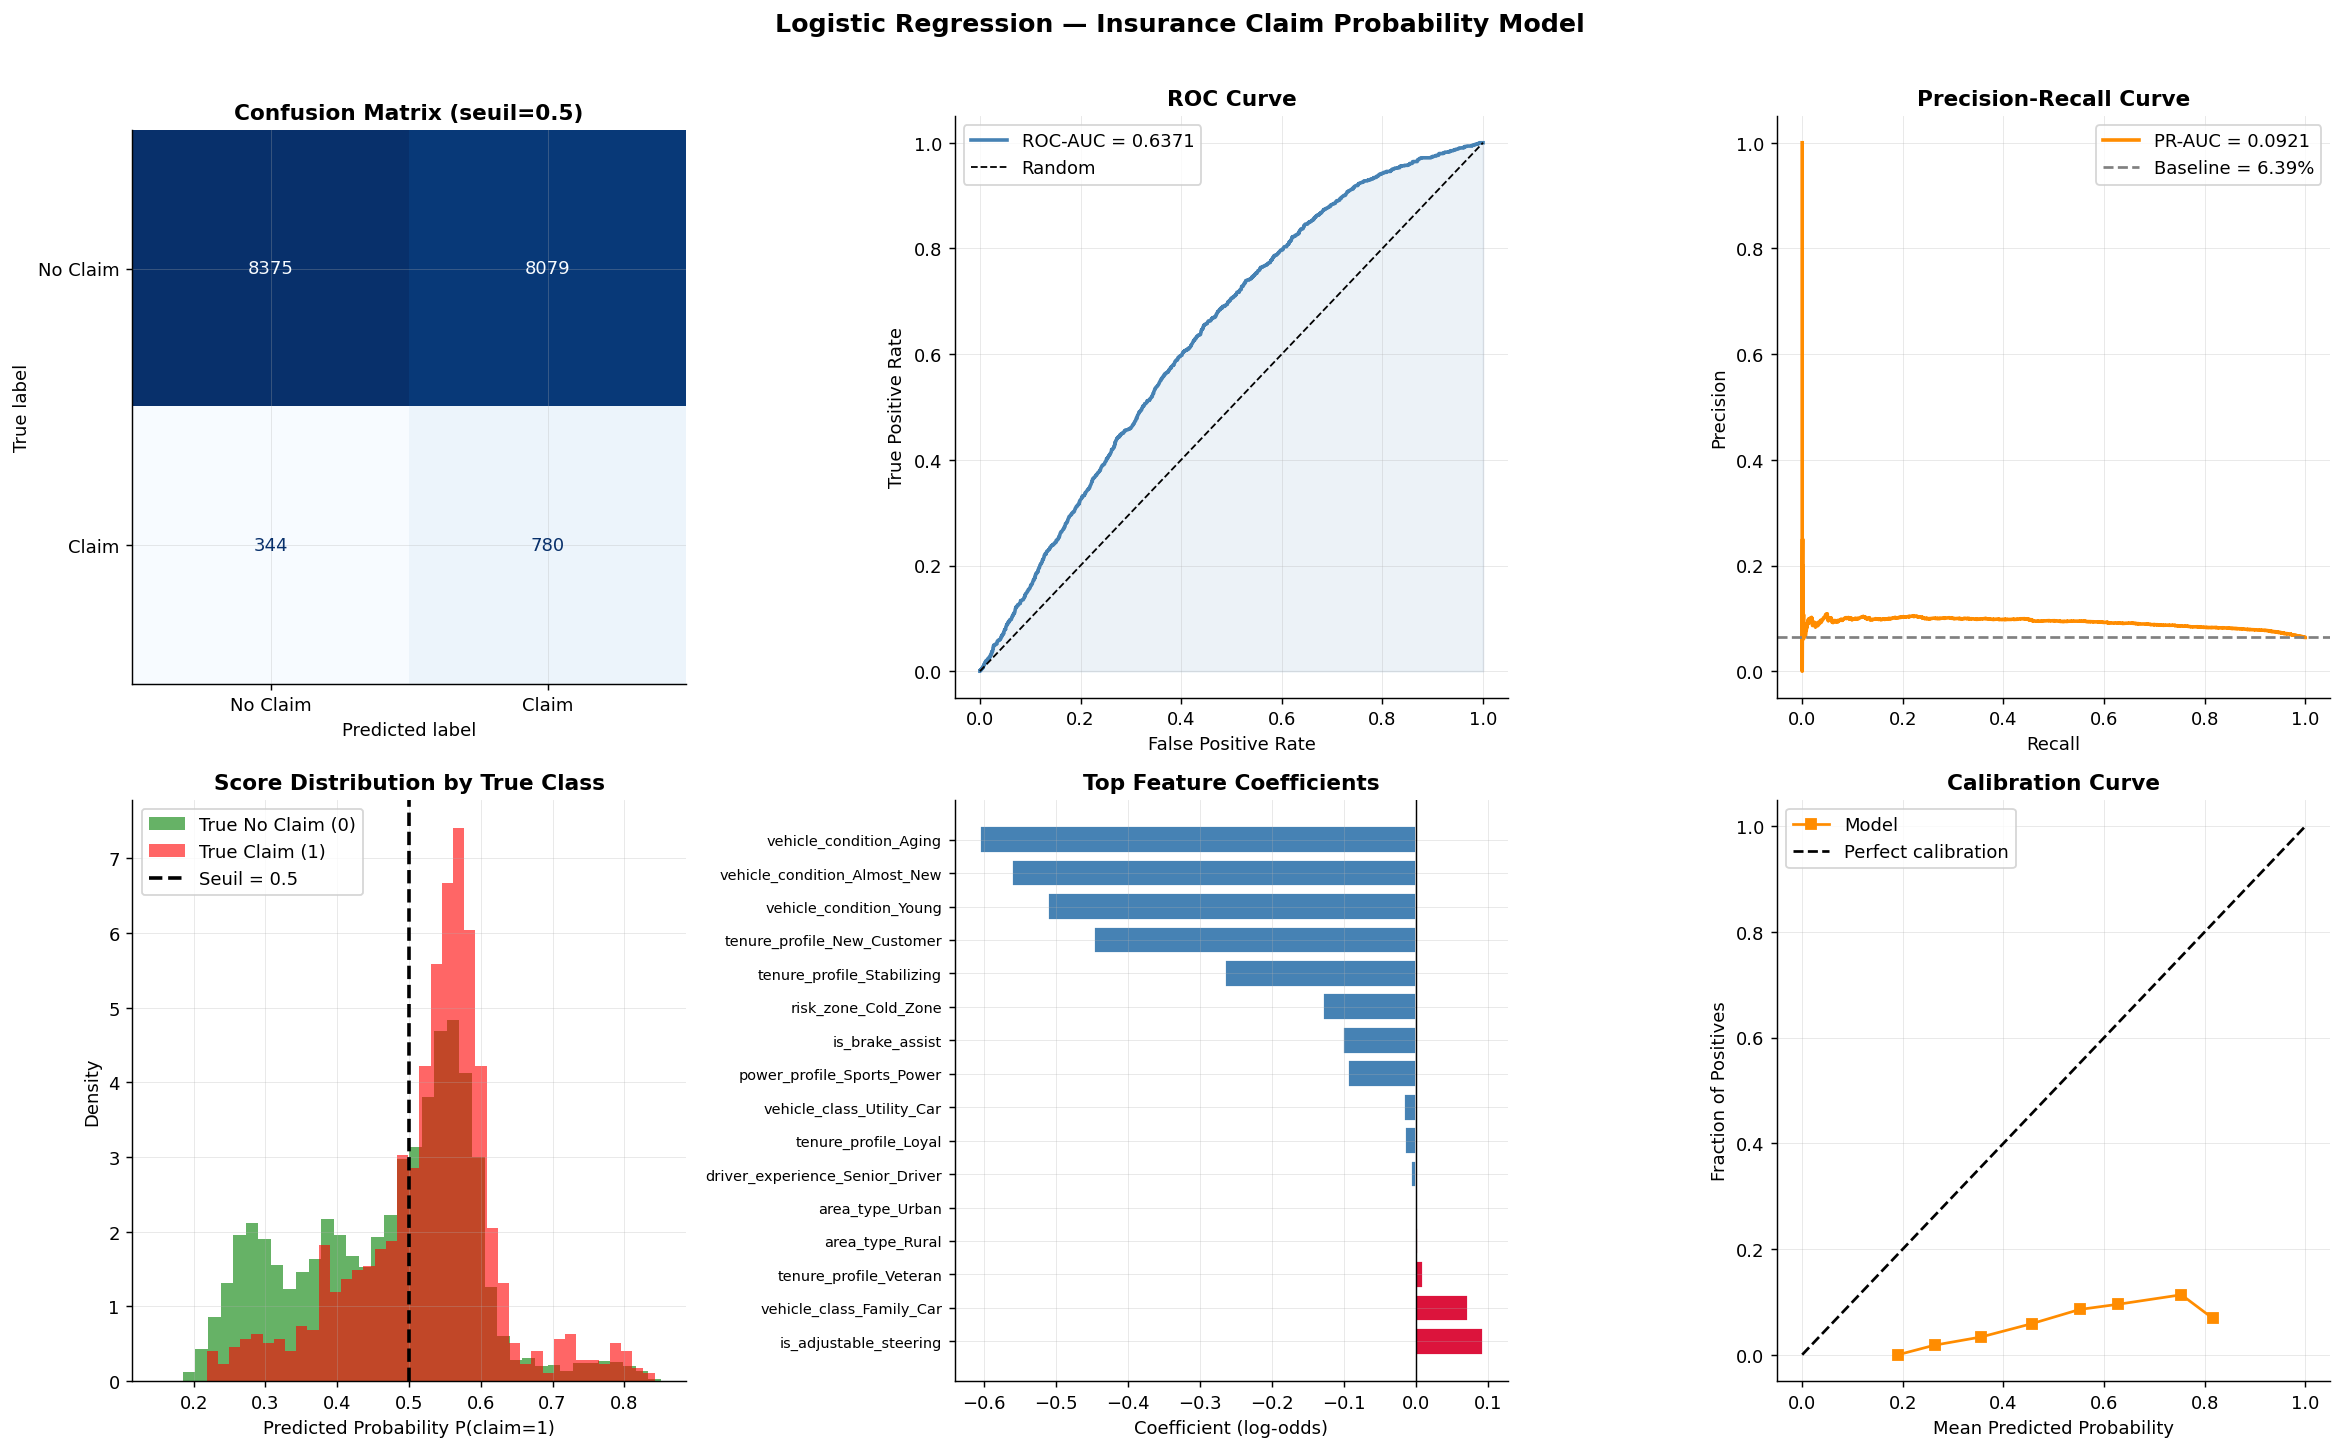


--- Optimal Threshold (Youden's J statistic) ---
   Optimal seuil : 0.4868
   TPR at optimal: 0.7393
   FPR at optimal: 0.5289

   Metrics at optimal threshold:
              precision    recall  f1-score   support

    No Claim       0.96      0.47      0.63     16454
       Claim       0.09      0.74      0.16      1124

    accuracy                           0.49     17578
   macro avg       0.53      0.61      0.39     17578
weighted avg       0.91      0.49      0.60     17578


Predictions exported: logistic_regression_predictions.csv

SUMMARY
  Model       : Logistic Regression (balanced)
  Train/Test  : 70% / 30%
  Features    : 27 (after one-hot with reference modality)
  ROC-AUC     : 0.6371
  PR-AUC      : 0.0921
  Brier Score : 0.2362
  Default seuil: 0.5  |  Optimal seuil: 0.4868


In [ ]:
# =============================================================================
# 9. EVALUATION METRICS
# =============================================================================

print("\n" + "=" * 65)
print("EVALUATION METRICS ")
print("=" * 65)

# --- 9.1 Classification Report ---
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_test, target_names=['No Claim (0)', 'Claim (1)']))

# --- 9.2 Key Scalar Metrics ---
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy  = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall    = recall_score(y_test, y_pred_test)
f1        = f1_score(y_test, y_pred_test)
roc_auc   = roc_auc_score(y_test, y_prob_test)
avg_prec  = average_precision_score(y_test, y_prob_test)
brier     = brier_score_loss(y_test, y_prob_test)

print(f"{'Accuracy':<30}: {accuracy:.4f}")
print(f"{'Precision (Claim=1)':<30}: {precision:.4f}")
print(f"{'Recall / Sensitivity':<30}: {recall:.4f}")
print(f"{'F1-Score':<30}: {f1:.4f}")
print(f"{'ROC-AUC':<30}: {roc_auc:.4f}")
print(f"{'Average Precision (PR-AUC)':<30}: {avg_prec:.4f}")
print(f"{'Brier Score (lower=better)':<30}: {brier:.4f}")

# =============================================================================
# 10. THRESHOLD SENSITIVITY ANALYSIS
# =============================================================================

print("\n--- Threshold Sensitivity ---")
print(f"{'Seuil':<10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Predicted %':>12}")
print("-" * 55)
for seuil in [0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70]:
    y_temp = (y_prob_test >= seuil).astype(int)
    p = precision_score(y_test, y_temp, zero_division=0)
    r = recall_score(y_test, y_temp, zero_division=0)
    f = f1_score(y_test, y_temp, zero_division=0)
    pct = y_temp.mean()
    marker = " ← selected" if seuil == SEUIL else ""
    print(f"{seuil:<10.2f} {p:>10.4f} {r:>10.4f} {f:>10.4f} {pct:>11.2%}{marker}")

# =============================================================================
# 11. COEFFICIENTS (MODEL INTERPRETABILITY)
# =============================================================================

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Odds_Ratio': np.exp(model.coef_[0])
}).sort_values('Coefficient', ascending=False)

print("\n--- Top 10 Most Impactful Features ---")
print(f"\n{'Feature':<40} {'Coef':>8}  {'Odds Ratio':>12}")
print("-" * 65)
for _, row in coef_df.head(10).iterrows():
    print(f"{row['Feature']:<40} {row['Coefficient']:>8.4f}  {row['Odds_Ratio']:>12.4f}")

print(f"\n--- Bottom 10 (Protective Features) ---")
print(f"\n{'Feature':<40} {'Coef':>8}  {'Odds Ratio':>12}")
print("-" * 65)
for _, row in coef_df.tail(10).iterrows():
    print(f"{row['Feature']:<40} {row['Coefficient']:>8.4f}  {row['Odds_Ratio']:>12.4f}")

# =============================================================================
# 12. VISUALIZATIONS
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Logistic Regression — Insurance Claim Probability Model',
             fontsize=14, fontweight='bold', y=1.01)

# --- Plot 1: Confusion Matrix ---
ax = axes[0, 0]
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Claim', 'Claim'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix (seuil={SEUIL})', fontweight='bold')

# --- Plot 2: ROC Curve ---
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC-AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend()

# --- Plot 3: Precision-Recall Curve ---
ax = axes[0, 2]
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
ax.plot(rec, prec, color='darkorange', lw=2, label=f'PR-AUC = {avg_prec:.4f}')
ax.axhline(y_test.mean(), color='gray', linestyle='--', label=f'Baseline = {y_test.mean():.2%}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend()

# --- Plot 4: Probability Distribution by True Class ---
ax = axes[1, 0]
ax.hist(y_prob_test[y_test == 0], bins=40, alpha=0.6, color='green',
        label='True No Claim (0)', density=True)
ax.hist(y_prob_test[y_test == 1], bins=40, alpha=0.6, color='red',
        label='True Claim (1)', density=True)
ax.axvline(SEUIL, color='black', linestyle='--', lw=2, label=f'Seuil = {SEUIL}')
ax.set_xlabel('Predicted Probability P(claim=1)')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by True Class', fontweight='bold')
ax.legend()

# --- Plot 5: Top Feature Coefficients ---
ax = axes[1, 1]
top_feats = pd.concat([coef_df.head(8), coef_df.tail(8)])
colors = ['crimson' if c > 0 else 'steelblue' for c in top_feats['Coefficient']]
ax.barh(top_feats['Feature'], top_feats['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Top Feature Coefficients', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)

# --- Plot 6: Calibration Curve ---
ax = axes[1, 2]
fraction_pos, mean_pred = calibration_curve(y_test, y_prob_test, n_bins=10)
ax.plot(mean_pred, fraction_pos, 's-', color='darkorange', label='Model')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()


# =============================================================================
# 13. OPTIMAL THRESHOLD VIA YOUDEN'S J (bonus)
# =============================================================================

fpr_arr, tpr_arr, thresholds = roc_curve(y_test, y_prob_test)
youden_j = tpr_arr - fpr_arr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

print(f"\n--- Optimal Threshold (Youden's J statistic) ---")
print(f"   Optimal seuil : {optimal_threshold:.4f}")
print(f"   TPR at optimal: {tpr_arr[optimal_idx]:.4f}")
print(f"   FPR at optimal: {fpr_arr[optimal_idx]:.4f}")

y_pred_optimal = (y_prob_test >= optimal_threshold).astype(int)
print(f"\n   Metrics at optimal threshold:")
print(classification_report(y_test, y_pred_optimal, target_names=['No Claim', 'Claim']))

# =============================================================================
# 14. EXPORT PREDICTIONS
# =============================================================================

results_df = pd.DataFrame({
    'policy_id': df.loc[y_test.index, 'policy_id'].values,
    'true_label': y_test.values,
    'prob_default': y_prob_test,
    f'pred_seuil_{SEUIL}': y_pred_test,
    f'pred_optimal_{optimal_threshold:.2f}': y_pred_optimal
})

results_df.to_csv('logistic_regression_predictions.csv', index=False)
print("\nPredictions exported: logistic_regression_predictions.csv")

print("\n" + "=" * 65)
print("SUMMARY")
print("=" * 65)
print(f"  Model       : Logistic Regression (balanced)")
print(f"  Train/Test  : 70% / 30%")
print(f"  Features    : {X.shape[1]} (after one-hot with reference modality)")
print(f"  ROC-AUC     : {roc_auc:.4f}")
print(f"  PR-AUC      : {avg_prec:.4f}")
print(f"  Brier Score : {brier:.4f}")
print(f"  Default seuil: {SEUIL}  |  Optimal seuil: {optimal_threshold:.4f}")
print("=" * 65)

* precision=0.088 : only 8.8% of predicted claims are actually real claims
* recall= 0.69 :model detects about 69.4% of real claims
* accuaracy =0.52 : 52% of all predictions are correct.
* F1_score : Low because precision is extremely low.
* ROC-AUC measures ranking ability
Meaning:
can the model assign higher probabilities to risky customers than safe customers?
so ROC-AUC = 0.6371 : the model is better than random it captures some risk signal but still limited has a predictive power
* Brier Score evaluates: probability calibration (probabilities are not perfectly calibrated
but still usable.

**Threshold Sensitivity Analysis**
As threshold increases:
1.   precision increases slightly
2.   recall decreases sharply
balanced compromise s=0.5%
* Optimal Threshold via Youden’s J

we searched for the threshold maximizing:

J=TPR(sensitivity)−FPR(specificity)



**Odds Ratio**
Logistic Regression coefficients were analyzed using odds ratios.

Features with:
- positive coefficients increase claim probability
- negative coefficients decrease claim probability



In [ ]:
gini = 2 * roc_auc - 1  # that's literally it
print(f"Gini coefficient: {gini:.4f}")

Gini coefficient: 0.2743


The obtained value suggests that the model has moderate predictive power and is capable of distinguishing between high-risk and low-risk customers better than random classification.



# other models : Gradient Boosting , RandomForest , DecisionTree , K-Nearest Neighbors, Naive Bayes


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# --- Pipeline & Preprocessing ---
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- Metrics ---
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss, f1_score, precision_score, recall_score,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from scipy.stats import ks_2samp

In [ ]:
SEUIL = 0.50  # default threshold for all models

In [ ]:
models = {'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=6,           # limit depth to avoid overfitting
            min_samples_leaf=50,   # each leaf must have at least 50 samples
            random_state=42
        ))
    ]),

    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            class_weight='balanced',
            n_estimators=200,      # 200 trees
            max_depth=8,
            min_samples_leaf=30,
            random_state=42,
            n_jobs=-1              # use all CPU cores
        ))
    ]),

    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,    # small steps → more stable
            subsample=0.8,         # use 80% of data per tree → reduces overfitting
            random_state=42
        ))
    ]),

    'K-Nearest Neighbors': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(
            n_neighbors=50,        # look at 50 nearest neighbors
            weights='distance',    # closer neighbors have more influence
            n_jobs=-1
        ))
    ]),

    'Naive Bayes': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GaussianNB(
            var_smoothing=1e-9
        ))
    ]),
}

# =============================================================================
# 5. TRAIN ALL MODELS & COLLECT RESULTS
# =============================================================================

# Ensure 'results' and 'probabilities' are dictionaries if not already
if 'results' not in globals() or not isinstance(results, dict):
    results = {}
if 'probabilities' not in globals() or not isinstance(probabilities, dict):
    probabilities = {}

print("\n" + "=" * 70)
print("TRAINING MODELS...")
print("=" * 70)

for name, pipeline in models.items():
    print(f"\n  Training {name}...", end=" ", flush=True)

    # Train
    pipeline.fit(X_train, y_train)

    # Predict probabilities
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= SEUIL).astype(int)

    # Store probabilities for plots
    probabilities[name] = y_prob

    # Compute all metrics
    roc_auc  = roc_auc_score(y_test, y_prob)
    pr_auc   = average_precision_score(y_test, y_prob)
    brier    = brier_score_loss(y_test, y_prob)
    gini     = 2 * roc_auc - 1
    ks_stat  = ks_2samp(y_prob[y_test == 0], y_prob[y_test == 1])[0]
    f1       = f1_score(y_test, y_pred, zero_division=0)
    precision= precision_score(y_test, y_pred, zero_division=0)
    recall   = recall_score(y_test, y_pred, zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)

    # Cross-validation ROC-AUC (5 folds on training data)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv,
                                scoring='roc_auc', n_jobs=-1)

    results[name] = {
        'ROC-AUC':     roc_auc,
        'PR-AUC':      pr_auc,
        'Gini':        gini,
        'KS Stat':     ks_stat,
        'Brier Score': brier,
        'F1 (Claim)':  f1,
        'Precision':   precision,
        'Recall':      recall,
        'Accuracy':    accuracy,
        'CV AUC Mean': cv_scores.mean(),
        'CV AUC Std':  cv_scores.std(),
    }

    print(f"done | ROC-AUC: {roc_auc:.4f} | Gini: {gini:.4f} | KS: {ks_stat:.4f}")


TRAINING MODELS...

  Training Decision Tree... done | ROC-AUC: 0.6302 | Gini: 0.2605 | KS: 0.2078

  Training Random Forest... done | ROC-AUC: 0.6431 | Gini: 0.2863 | KS: 0.2240

  Training Gradient Boosting... done | ROC-AUC: 0.6505 | Gini: 0.3010 | KS: 0.2303

  Training K-Nearest Neighbors... done | ROC-AUC: 0.5630 | Gini: 0.1259 | KS: 0.1252

  Training Naive Bayes... done | ROC-AUC: 0.6051 | Gini: 0.2103 | KS: 0.1681


In [ ]:
# =============================================================================
# 6. COMPARISON TABLE
# =============================================================================

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("\n" + "=" * 70)
print("MODEL COMPARISON TABLE (sorted by ROC-AUC)")
print("=" * 70)

display_cols = ['ROC-AUC', 'Gini', 'KS Stat', 'PR-AUC', 'Brier Score',
                'F1 (Claim)', 'Precision', 'Recall', 'CV AUC Mean', 'CV AUC Std']

print(f"\n{'Model':<22}", end="")
for col in display_cols:
    print(f"{col:>13}", end="")
print()
print("-" * (22 + 13 * len(display_cols)))

for model_name, row in results_df.iterrows():
    print(f"{model_name:<22}", end="")
    for col in display_cols:
        val = row[col]
        # Highlight best value per metric
        best = results_df[col].max() if col != 'Brier Score' else results_df[col].min()
        marker = "*" if abs(val - best) < 1e-6 else " "
        print(f"{val:>12.4f}{marker}", end="")
    print()

print("\n  * = best value for that metric")

# =============================================================================
# 7. LIFT TABLE (DECILE ANALYSIS) — for best model
# =============================================================================

best_model_name = results_df.index[0]
best_probs = probabilities[best_model_name]

print(f"\n" + "=" * 70)
print(f"LIFT TABLE — {best_model_name} (best model by ROC-AUC)")
print("=" * 70)

lift_df = pd.DataFrame({'prob': best_probs, 'actual': y_test.values})
lift_df['decile'] = pd.qcut(lift_df['prob'], q=10, labels=False, duplicates='drop')
lift_df['decile'] = 10 - lift_df['decile']  # flip: decile 1 = highest risk

overall_rate = y_test.mean()

print(f"\n{'Decile':<10} {'N':>8} {'Claims':>8} {'Claim Rate':>12} {'Lift':>8} {'Cumul. Capture':>16}")
print("-" * 65)

decile_stats = lift_df.groupby('decile').agg(
    N=('actual', 'count'),
    Claims=('actual', 'sum')
).sort_index()
decile_stats['Claim Rate'] = decile_stats['Claims'] / decile_stats['N']
decile_stats['Lift'] = decile_stats['Claim Rate'] / overall_rate
decile_stats['Cumul Claims'] = decile_stats['Claims'].cumsum()
total_claims = decile_stats['Claims'].sum()
decile_stats['Cumul Capture'] = decile_stats['Cumul Claims'] / total_claims

for dec, row in decile_stats.iterrows():
    bar = "█" * int(row['Lift'] * 5)
    print(f"  {int(dec):<8} {int(row['N']):>8,} {int(row['Claims']):>8,} "
          f"{row['Claim Rate']:>11.2%} {row['Lift']:>7.2f}x "
          f"{row['Cumul Capture']:>14.2%}  {bar}")

print(f"\n  Interpretation: Decile 1 has {decile_stats.loc[1,'Lift']:.1f}x the average claim rate.")
print(f"  Top 3 deciles capture {decile_stats.loc[3,'Cumul Capture']:.0%} of all claims.")

# =============================================================================
# 8. THRESHOLD SENSITIVITY FOR BEST MODEL
# =============================================================================

print(f"\n--- Threshold Sensitivity ({best_model_name}) ---")
print(f"{'Seuil':<10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Predicted%':>12}")
print("-" * 55)
for seuil in [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]:
    y_temp = (best_probs >= seuil).astype(int)
    p = precision_score(y_test, y_temp, zero_division=0)
    r = recall_score(y_test, y_temp, zero_division=0)
    f = f1_score(y_test, y_temp, zero_division=0)
    pct = y_temp.mean()
    print(f"{seuil:<10.2f} {p:>10.4f} {r:>10.4f} {f:>10.4f} {pct:>11.2%}")


MODEL COMPARISON TABLE (sorted by ROC-AUC)

Model                       ROC-AUC         Gini      KS Stat       PR-AUC  Brier Score   F1 (Claim)    Precision       Recall  CV AUC Mean   CV AUC Std
--------------------------------------------------------------------------------------------------------------------------------------------------------
Gradient Boosting           0.6505*      0.3010*      0.2303*      0.0992*      0.0590*      0.0000       0.0000       0.0000       0.6379*      0.0092 
Random Forest               0.6431       0.2863       0.2240       0.0973       0.2258       0.1625*      0.0924*      0.6753       0.6321       0.0089 
Logistic Regression         0.6371       0.2743       0.2104       0.0921       0.2362       0.1563       0.0880       0.6940       0.6301       0.0124 
Decision Tree               0.6302       0.2605       0.2078       0.0909       0.2360       0.1533       0.0850       0.7811*      0.6218       0.0152*
Naive Bayes                 0.6051   

**visualisations**

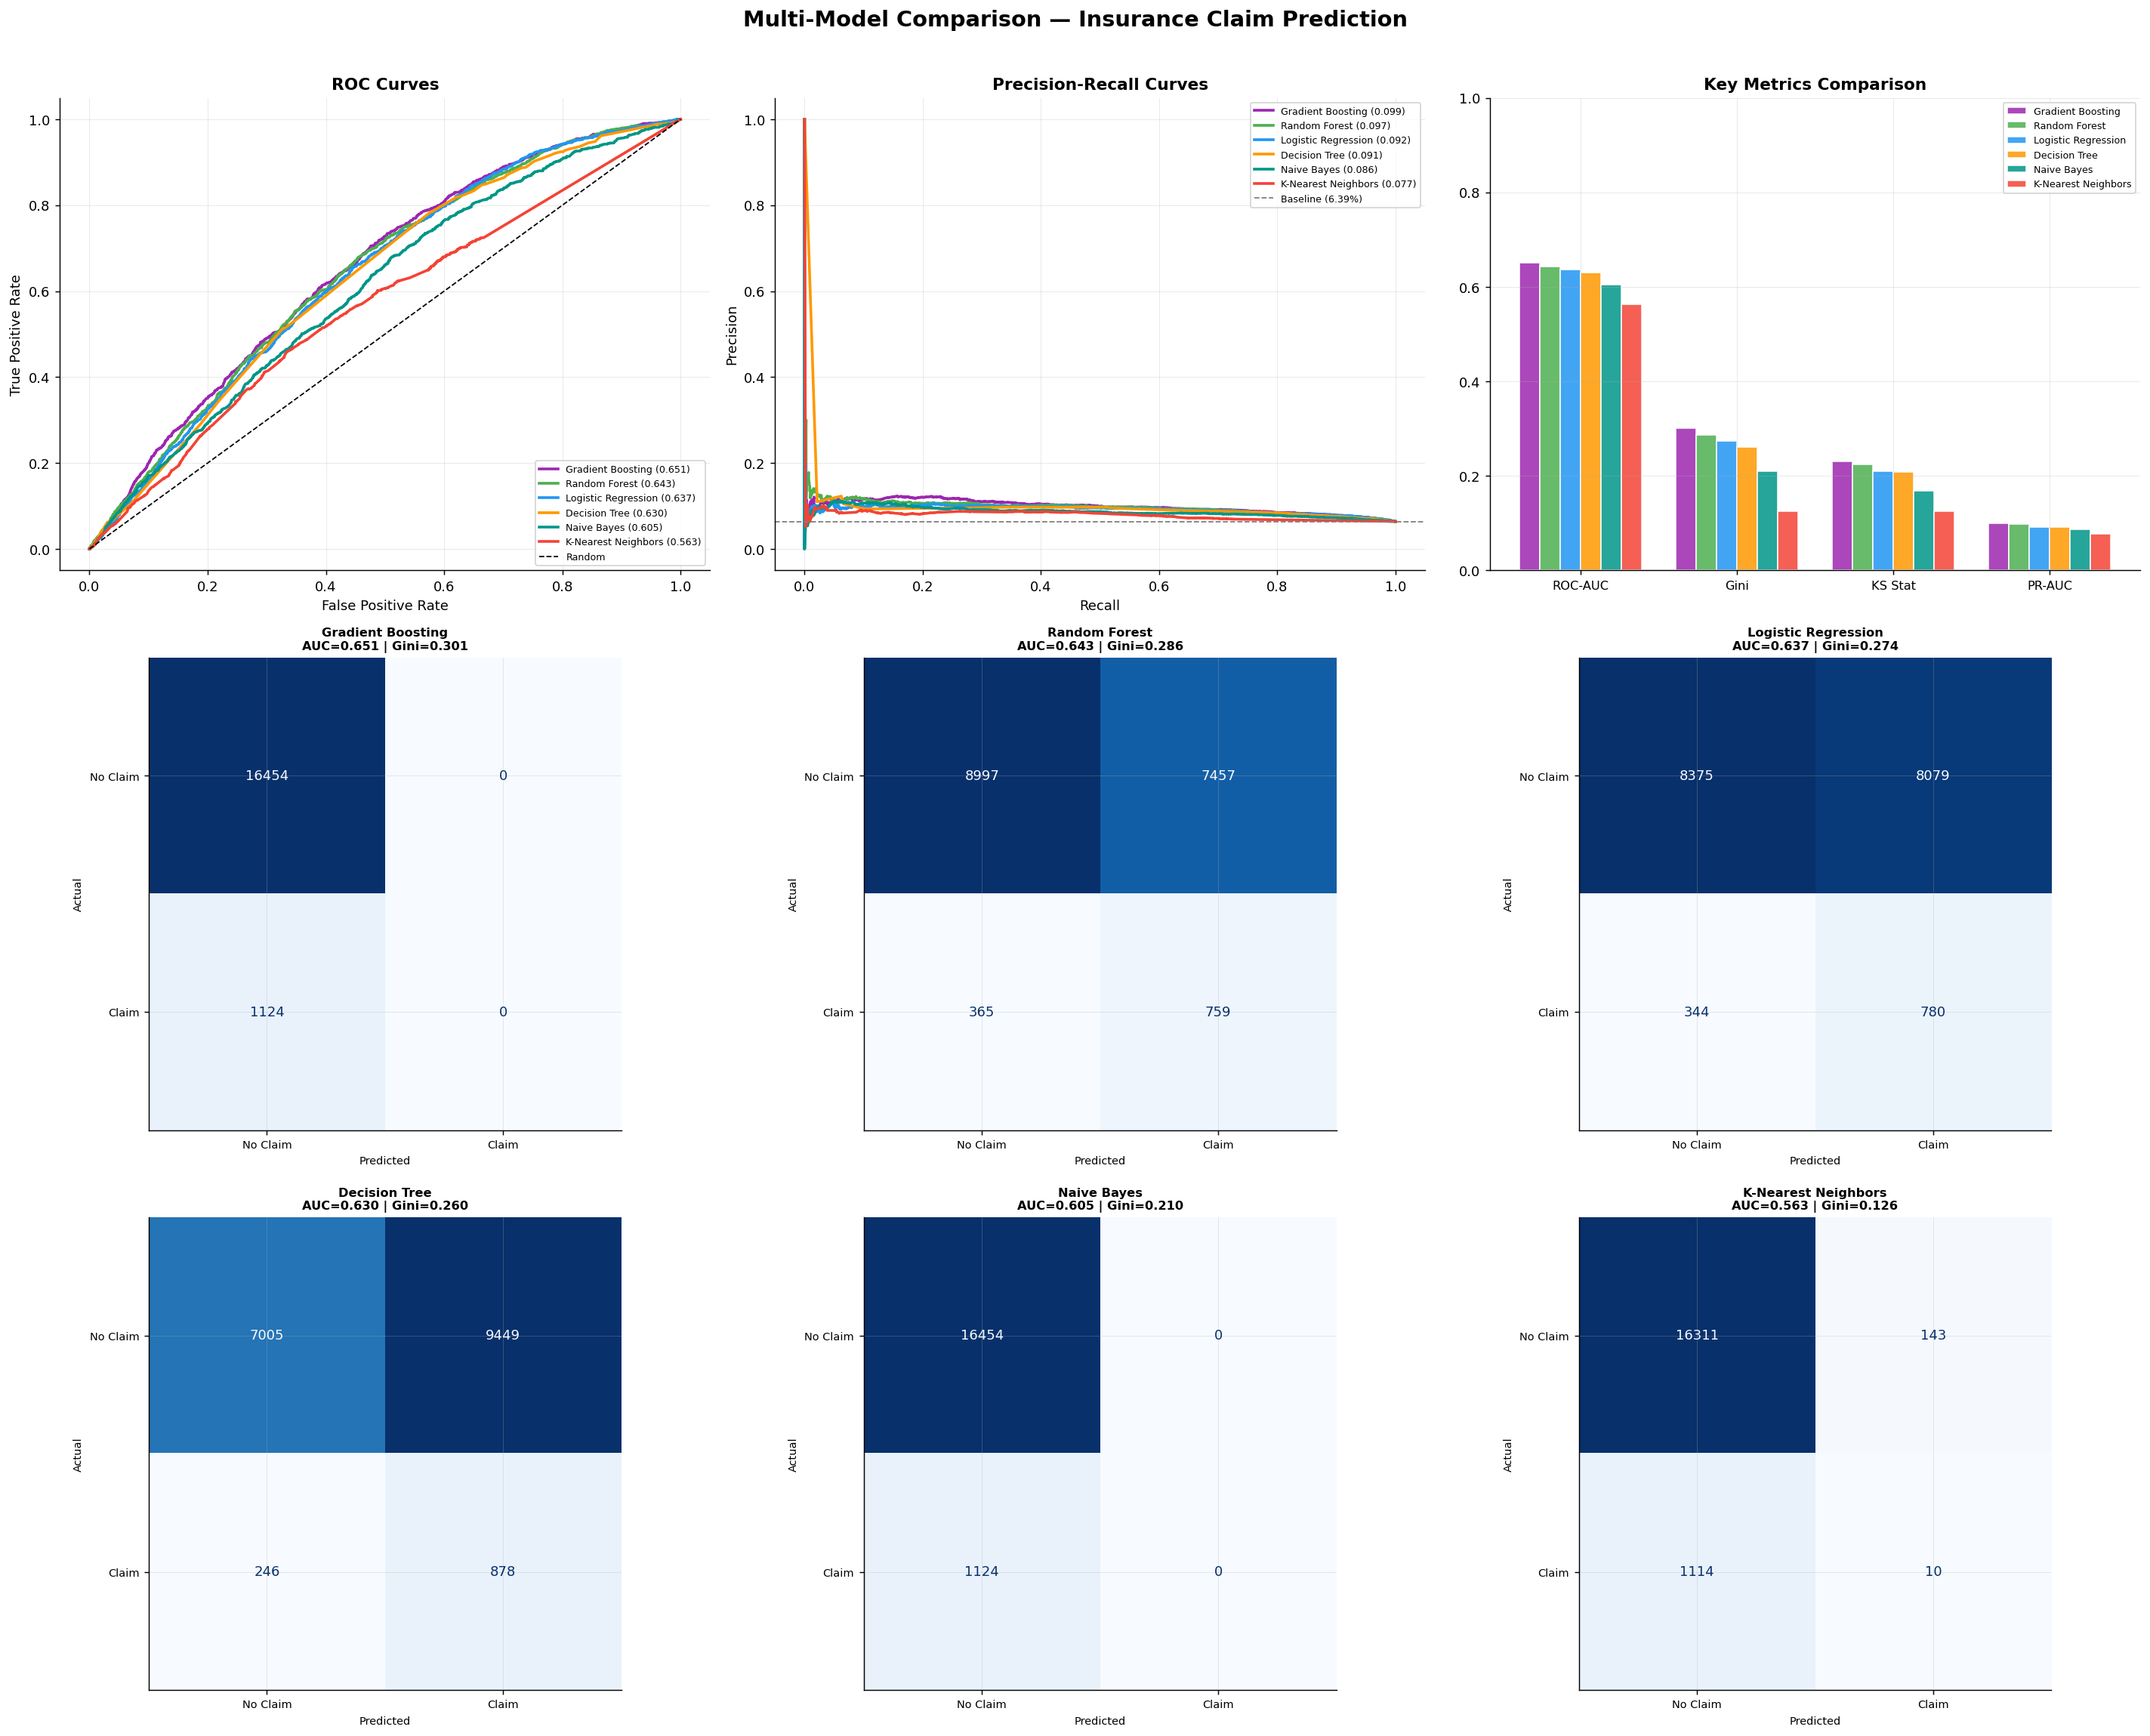


Plot saved: model_comparison.png


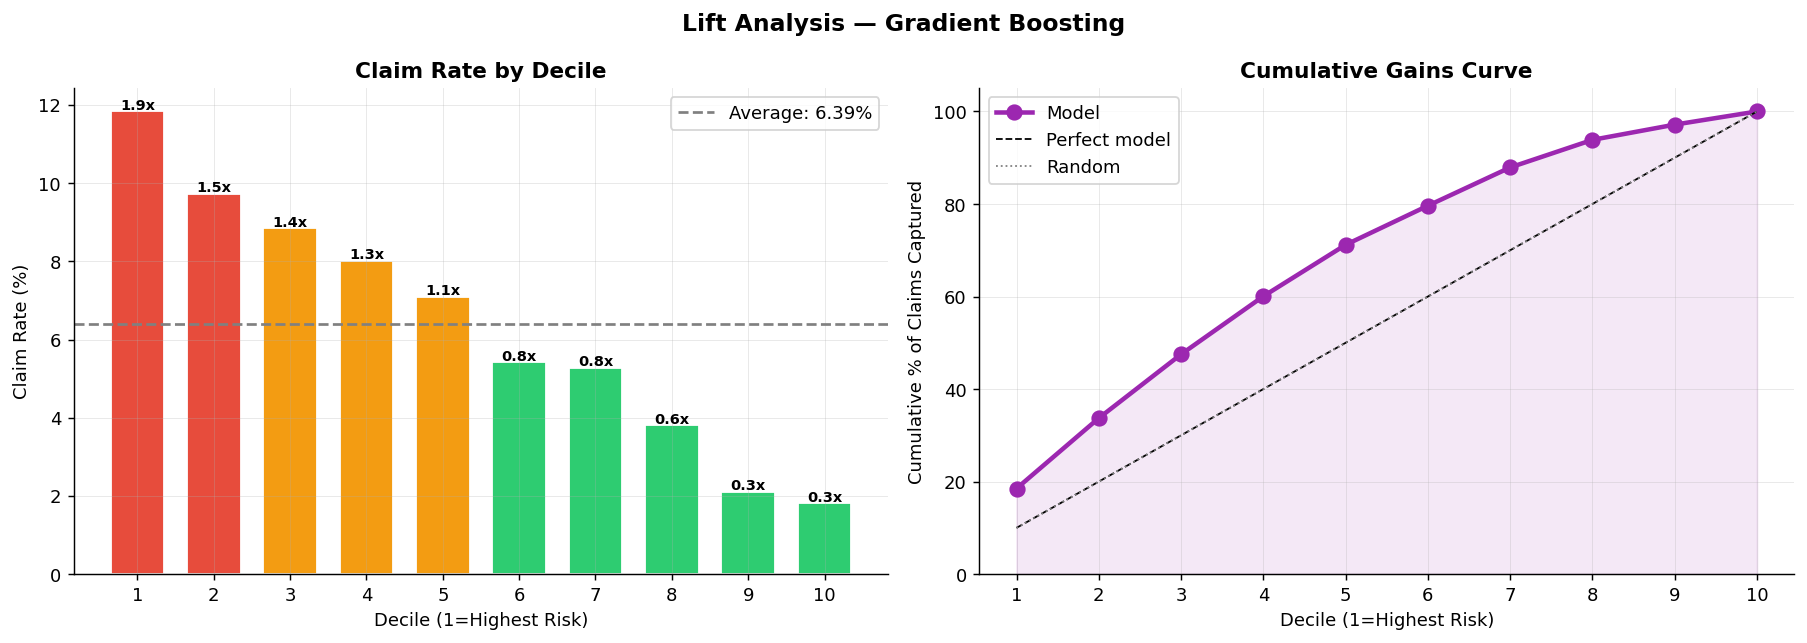

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 420-421: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/zmq/eventloop/zmqstream.py", line 551, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 120, in _handle_event
    event_f()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to

In [ ]:
# =============================================================================
# 9. VISUALIZATIONS
# =============================================================================

colors_map = {
    'Logistic Regression': '#2196F3',
    'Decision Tree':       '#FF9800',
    'Random Forest':       '#4CAF50',
    'Gradient Boosting':   '#9C27B0',
    'K-Nearest Neighbors': '#F44336',
    'Naive Bayes':         '#009688',
}

fig = plt.figure(figsize=(22, 18))
fig.suptitle('Multi-Model Comparison — Insurance Claim Prediction',
             fontsize=16, fontweight='bold', y=0.98)

# --- Plot 1: ROC Curves (all models) ---
ax1 = fig.add_subplot(3, 3, 1)
for _, row in results_df.iterrows():
    name = row.name # Corrected: model name is in the index
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = results[name]['ROC-AUC']
    ax1.plot(fpr, tpr, color=colors_map[name], lw=2, label=f"{name} ({auc:.3f})")
ax1.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves', fontweight='bold')
ax1.legend(fontsize=7, loc='lower right')

# --- Plot 2: Precision-Recall Curves ---
ax2 = fig.add_subplot(3, 3, 2)
for _, row in results_df.iterrows():
    name = row.name # Corrected: model name is in the index
    prec, rec, _ = precision_recall_curve(y_test, probabilities[name])
    pr = results[name]['PR-AUC']
    ax2.plot(rec, prec, color=colors_map[name], lw=2, label=f"{name} ({pr:.3f})")
ax2.axhline(y_test.mean(), color='gray', linestyle='--', lw=1,
            label=f'Baseline ({y_test.mean():.2%})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves', fontweight='bold')
ax2.legend(fontsize=7)

# --- Plot 3: Bar chart — key metrics ---
ax3 = fig.add_subplot(3, 3, 3)
metrics_to_bar = ['ROC-AUC', 'Gini', 'KS Stat', 'PR-AUC']
x = np.arange(len(metrics_to_bar))
width = 0.13
for i, (_, row) in enumerate(results_df.iterrows()):
    name = row.name # Corrected: model name is in the index
    vals = [row[m] for m in metrics_to_bar]
    ax3.bar(x + i * width, vals, width, label=name,
            color=colors_map[name], alpha=0.85, edgecolor='white')
ax3.set_xticks(x + width * (len(results_df) - 1) / 2)
ax3.set_xticklabels(metrics_to_bar, fontsize=9)
ax3.set_title('Key Metrics Comparison', fontweight='bold')
ax3.legend(fontsize=7, loc='upper right')
ax3.set_ylim(0, 1)

# --- Plots 4-9: Confusion matrices for each model ---
positions = [4, 5, 6, 7, 8, 9]
for pos, (_, row) in zip(positions, results_df.iterrows()):
    name = row.name # Corrected: model name is in the index
    ax = fig.add_subplot(3, 3, pos)
    y_pred_cm = (probabilities[name] >= SEUIL).astype(int)
    cm = confusion_matrix(y_test, y_pred_cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Claim', 'Claim'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    auc = results[name]['ROC-AUC']
    gini = results[name]['Gini']
    ax.set_title(f"{name}\nAUC={auc:.3f} | Gini={gini:.3f}", fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=8); ax.set_ylabel('Actual', fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: model_comparison.png")

# --- Lift chart for best model ---
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle(f'Lift Analysis — {best_model_name}', fontsize=13, fontweight='bold')

ax = axes2[0]
bars = ax.bar(range(1, len(decile_stats)+1),
              decile_stats['Claim Rate'] * 100,
              color=[('#e74c3c' if l >= 1.5 else '#f39c12' if l >= 1.0 else '#2ecc71')
                     for l in decile_stats['Lift']],
              edgecolor='white', width=0.7)
ax.axhline(overall_rate * 100, color='gray', linestyle='--', lw=1.5,
           label=f'Average: {overall_rate:.2%}')
ax.set_xlabel('Decile (1=Highest Risk)')
ax.set_ylabel('Claim Rate (%)')
ax.set_title('Claim Rate by Decile', fontweight='bold')
ax.set_xticks(range(1, len(decile_stats)+1))
ax.legend()
for bar, (_, row) in zip(bars, decile_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{row['Lift']:.1f}x", ha='center', fontsize=8, fontweight='bold')

ax = axes2[1]
ax.plot(range(1, len(decile_stats)+1), decile_stats['Cumul Capture'] * 100,
        'o-', color='#9C27B0', lw=2.5, markersize=8, label='Model')
ax.plot([1, 10], [10, 100], 'k--', lw=1, label='Perfect model')
ax.plot([1, 10], [decile_stats.loc[1,'N']/len(y_test)*100, 100],
        'gray', linestyle=':', lw=1, label='Random')
ax.fill_between(range(1, len(decile_stats)+1),
                decile_stats['Cumul Capture'] * 100, alpha=0.1, color='#9C27B0')
ax.set_xlabel('Decile (1=Highest Risk)')
ax.set_ylabel('Cumulative % of Claims Captured')
ax.set_title('Cumulative Gains Curve', fontweight='bold')
ax.set_xticks(range(1, len(decile_stats)+1))
ax.legend()
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('lift_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: lift_analysis.png")

# =============================================================================
# 10. FINAL RANKING SUMMARY
# =============================================================================

print("\n" + "=" * 70)
print("FINAL MODEL RANKING")
print("=" * 70)

rank_metrics = ['ROC-AUC', 'Gini', 'KS Stat', 'PR-AUC', 'F1 (Claim)']
rankings = pd.DataFrame(index=results_df.index)
for m in rank_metrics:
    asc = (m == 'Brier Score')
    rankings[m] = results_df[m].rank(ascending=asc).astype(int)
rankings['Average Rank'] = rankings.mean(axis=1)
rankings = rankings.sort_values('Average Rank')

print(f"\n{'Model':<22}", end="")
for m in rank_metrics:
    print(f"{m:>12}", end="")
print(f"{'Avg Rank':>12}")
print("-" * (22 + 12 * (len(rank_metrics) + 1)))

medals = ['\ud83e\udd47', '\ud83e\udd48', '\ud83e\udd49', '4 ', '5 ', '6 ']
for i, (name, row) in enumerate(rankings.iterrows()):
    model_name_str = name # Corrected: 'name' already holds the model name
    print(f"{medals[i]} {model_name_str:<20}", end="")
    for m in rank_metrics:
        print(f"{int(row[m]):>12}", end="")
    print(f"{row['Average Rank']:>12.1f}")

winner = rankings.index[0]
winner_model_name = winner # Corrected: 'winner' already holds the best model name
print(f"\n  Best overall model: {winner_model_name}")
print(f"  ROC-AUC     : {results[winner_model_name]['ROC-AUC']:.4f}")
print(f"  Gini        : {results[winner_model_name]['Gini']:.4f}")
print(f"  KS Stat     : {results[winner_model_name]['KS Stat']:.4f}")
print(f"  PR-AUC      : {results[winner_model_name]['PR-AUC']:.4f}")


In [1]:
import pandas as pd
from tabulate import tabulate

# Create the data
data = {
    'Rank': ['1', '2', '3', '4', '5', '6'],
    'Model': [
        'Gradient Boosting',
        'Random Forest',
        'Logistic Regression',
        'Decision Tree',
        'Naive Bayes',
        'K-Nearest Neighbors'
    ],
    'ROC-AUC': [0.6505, 0.6431, 0.6371, 0.6302, 0.6051, 0.5630],
    'Gini': [0.3010, 0.2863, 0.2743, 0.2605, 0.2103, 0.1259],
    'Verdict': [
        'Best for scoring/ranking risk',
        'Best balance of all metrics',
        'Most interpretable',
        'Highest recall, least stable',
        'Fast but weak',
        'Not suitable for this data'
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display using tabulate for better formatting
print("\n" + tabulate(df, headers='keys', tablefmt='grid', showindex=False,
                      floatfmt=".4f", stralign="left"))

# Save to CSV
df.to_csv('model_comparison_table.csv', index=False)
print("\n✅ Table saved to 'model_comparison_table.csv'")

# For analysis purposes, you can also calculate additional metrics
print("\n" + "="*60)
print("Summary Statistics:")
print("="*60)
print(f"Best ROC-AUC: {df['ROC-AUC'].max():.4f} ({df.loc[df['ROC-AUC'].idxmax(), 'Model']})")
print(f"Best Gini: {df['Gini'].max():.4f} ({df.loc[df['Gini'].idxmax(), 'Model']})")
print(f"Average ROC-AUC: {df['ROC-AUC'].mean():.4f}")
print(f"Average Gini: {df['Gini'].mean():.4f}")


+--------+---------------------+-----------+--------+-------------------------------+
|   Rank | Model               |   ROC-AUC |   Gini | Verdict                       |
+========+=====================+===========+========+===============================+
|      1 | Gradient Boosting   |    0.6505 | 0.3010 | Best for scoring/ranking risk |
+--------+---------------------+-----------+--------+-------------------------------+
|      2 | Random Forest       |    0.6431 | 0.2863 | Best balance of all metrics   |
+--------+---------------------+-----------+--------+-------------------------------+
|      3 | Logistic Regression |    0.6371 | 0.2743 | Most interpretable            |
+--------+---------------------+-----------+--------+-------------------------------+
|      4 | Decision Tree       |    0.6302 | 0.2605 | Highest recall, least stable  |
+--------+---------------------+-----------+--------+-------------------------------+
|      5 | Naive Bayes         |    0.6051 | 0.2103 |

# conclusion
Several machine learning models were compared using metrics adapted to imbalanced datasets such as ROC-AUC, PR-AUC, Recall, and F1-score.

_ results showed that some methods such as Gradient Boosting and Random Forest achieved the best predictive performance, while Logistic Regression provided the highest interpretability and business explainability.
Although the predictive scores remain moderate due to the strong class imbalance and the complexity of claim occurrence, the models were able to identify meaningful risk patterns related to:
- customer profiles,
- vehicle characteristics